# heatmap - Part 3/4\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


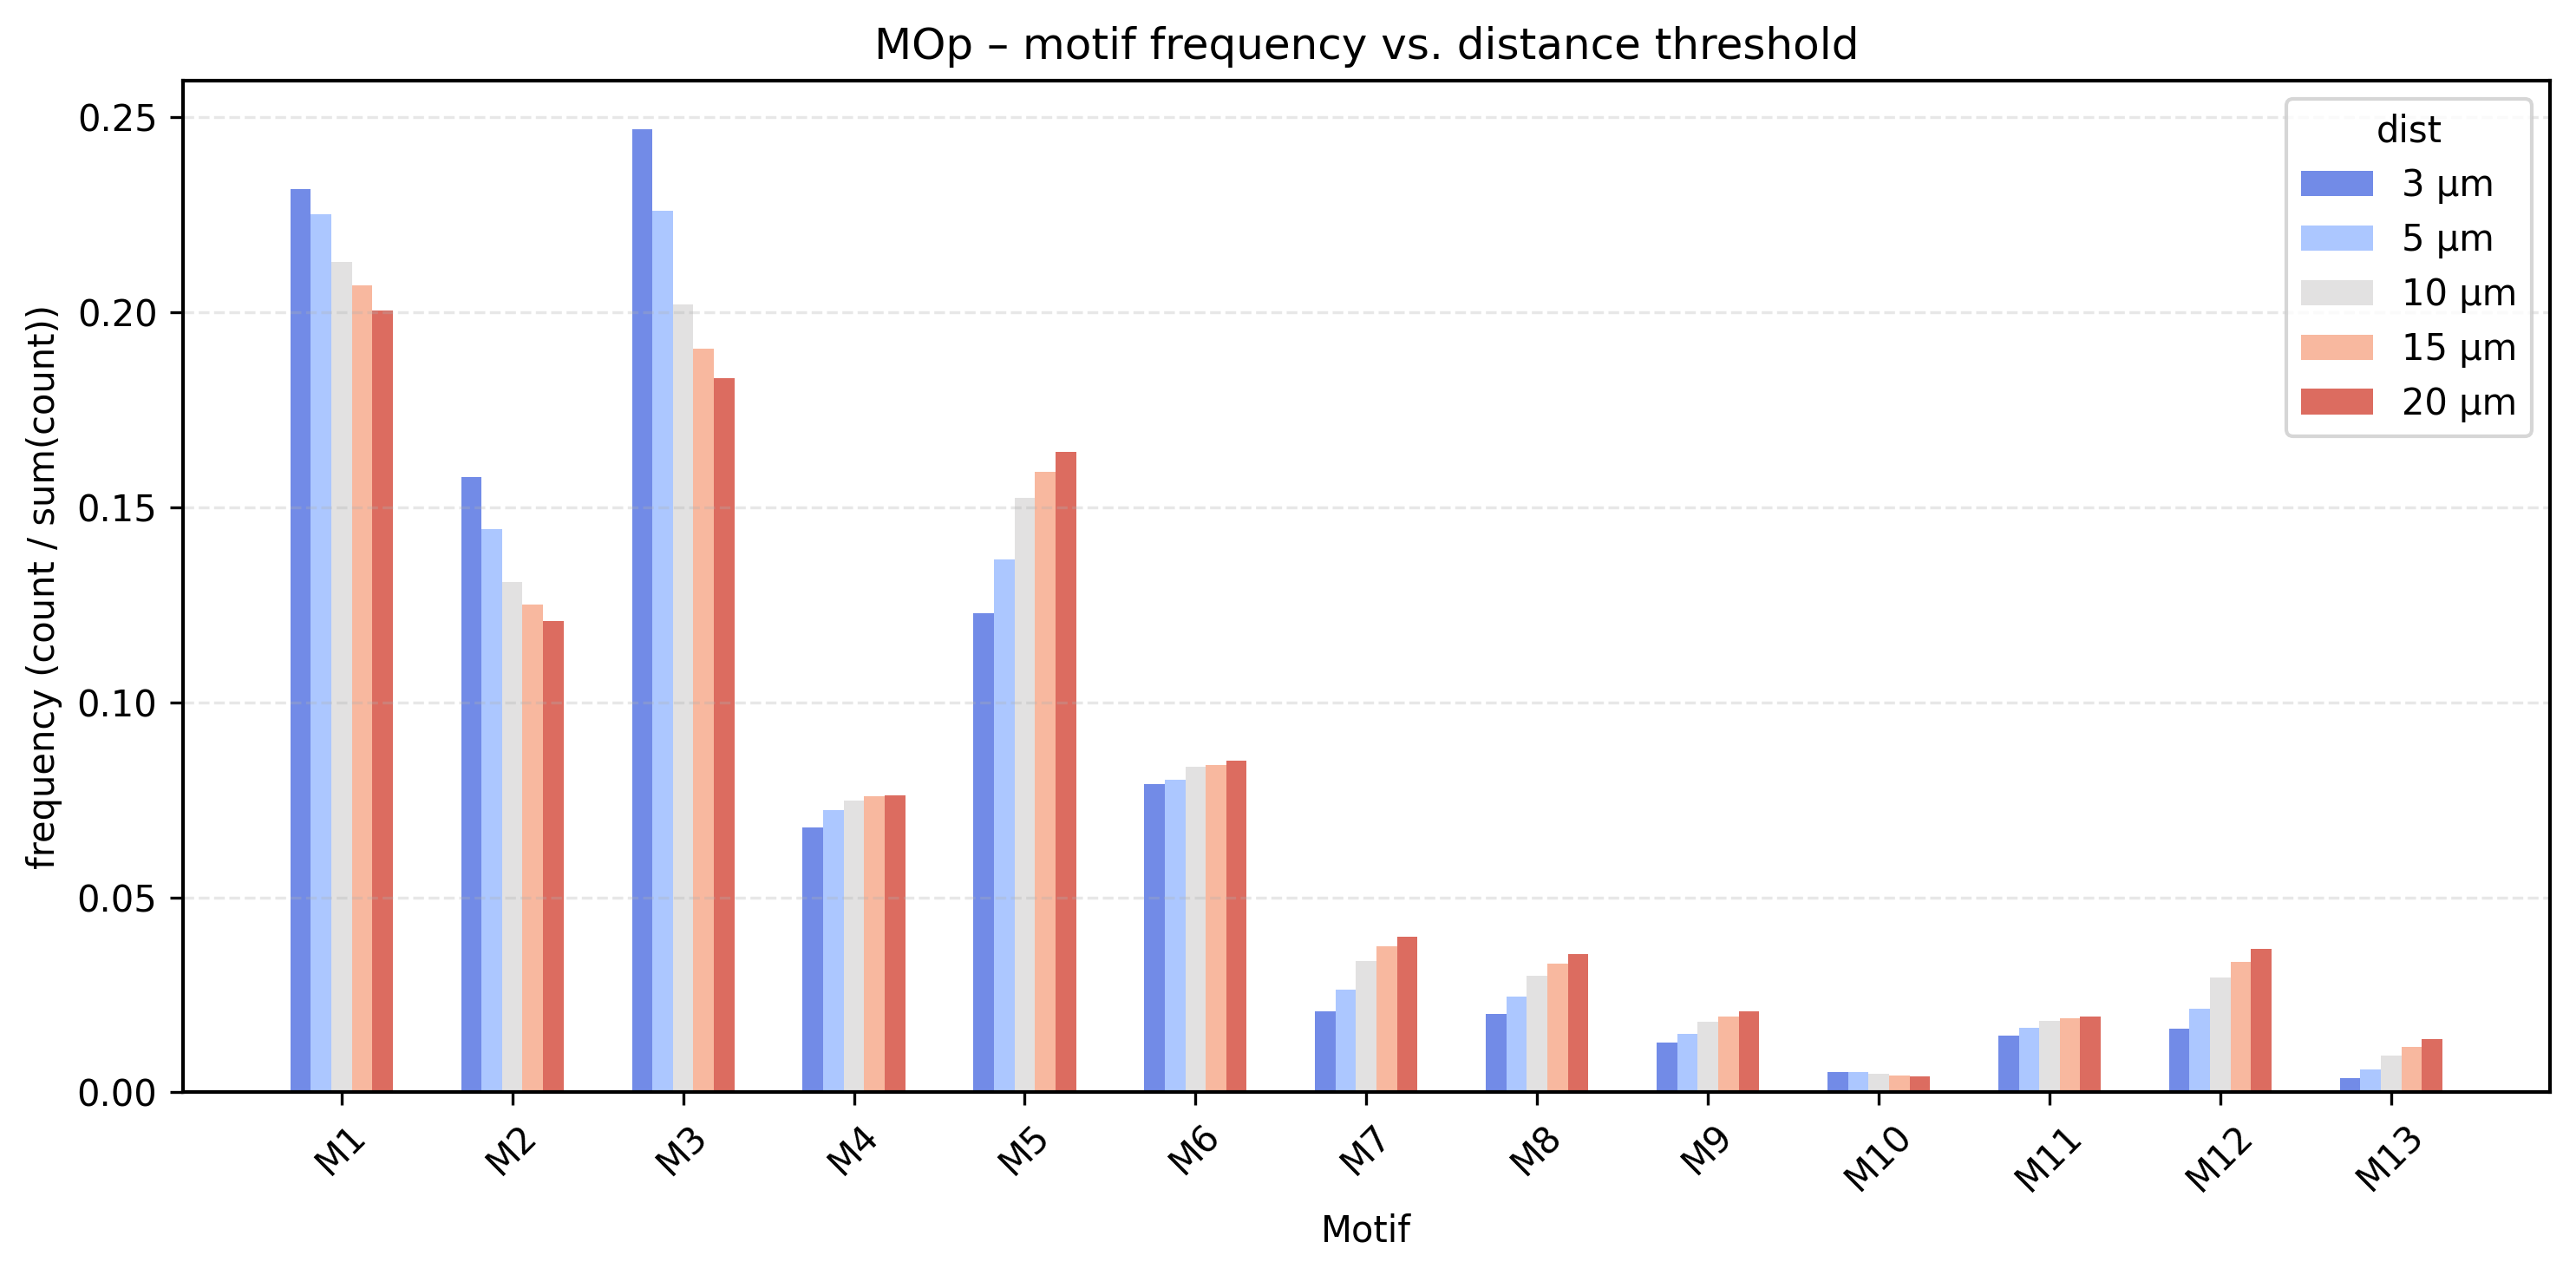

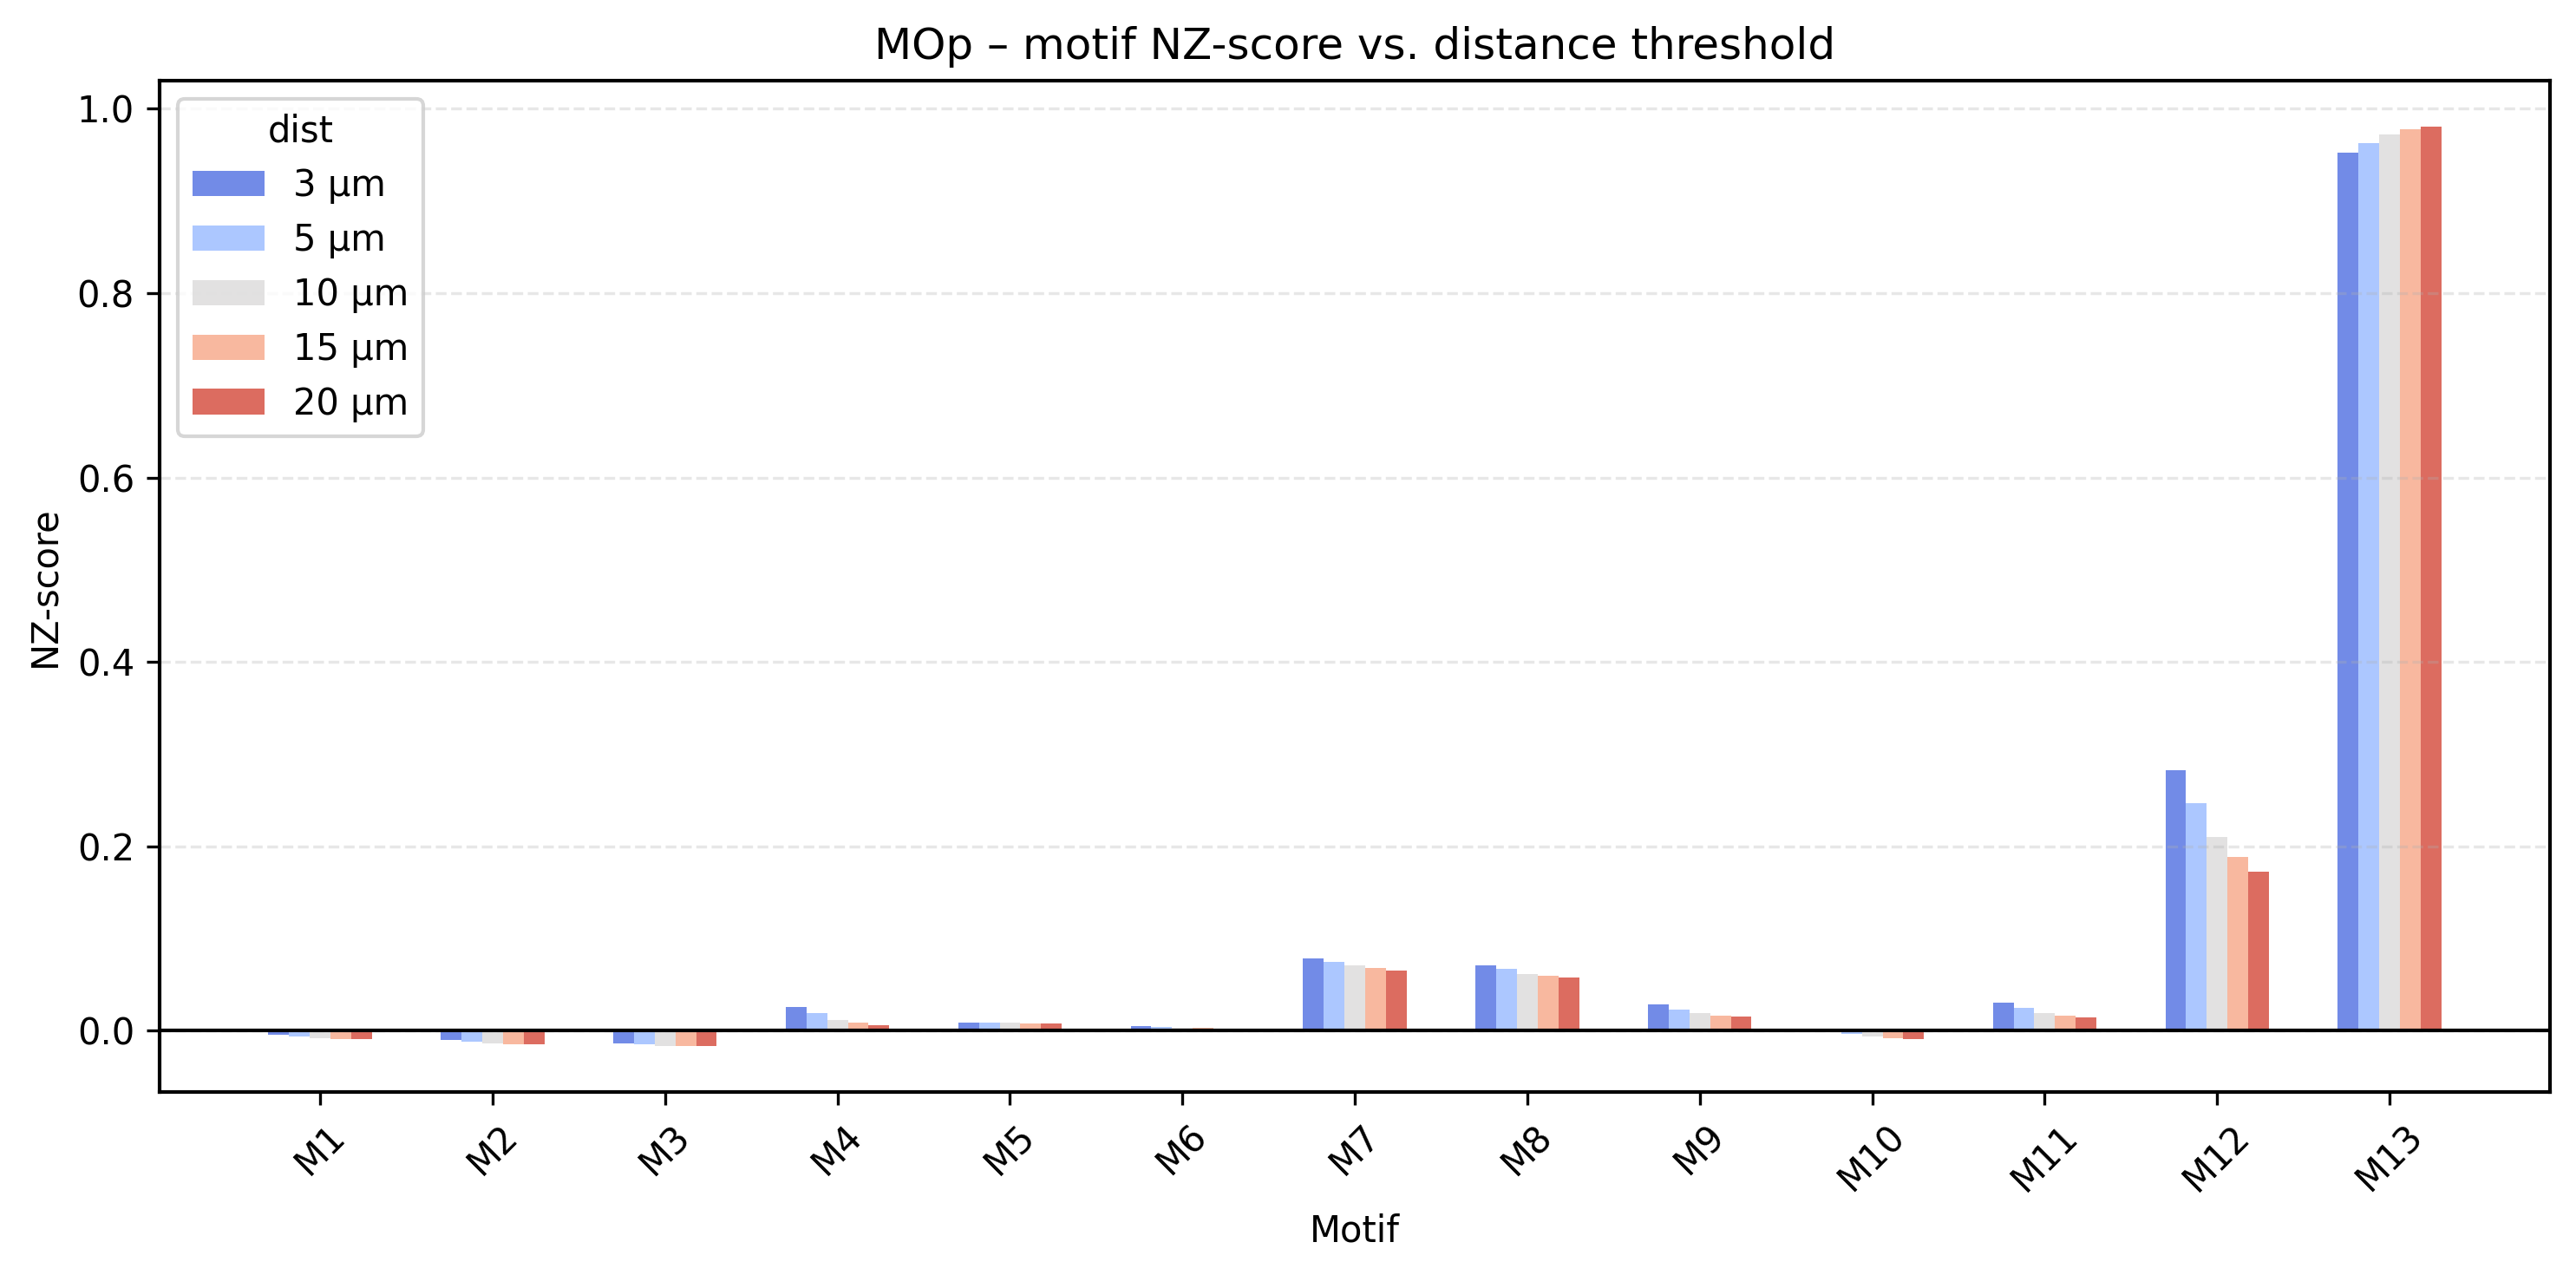

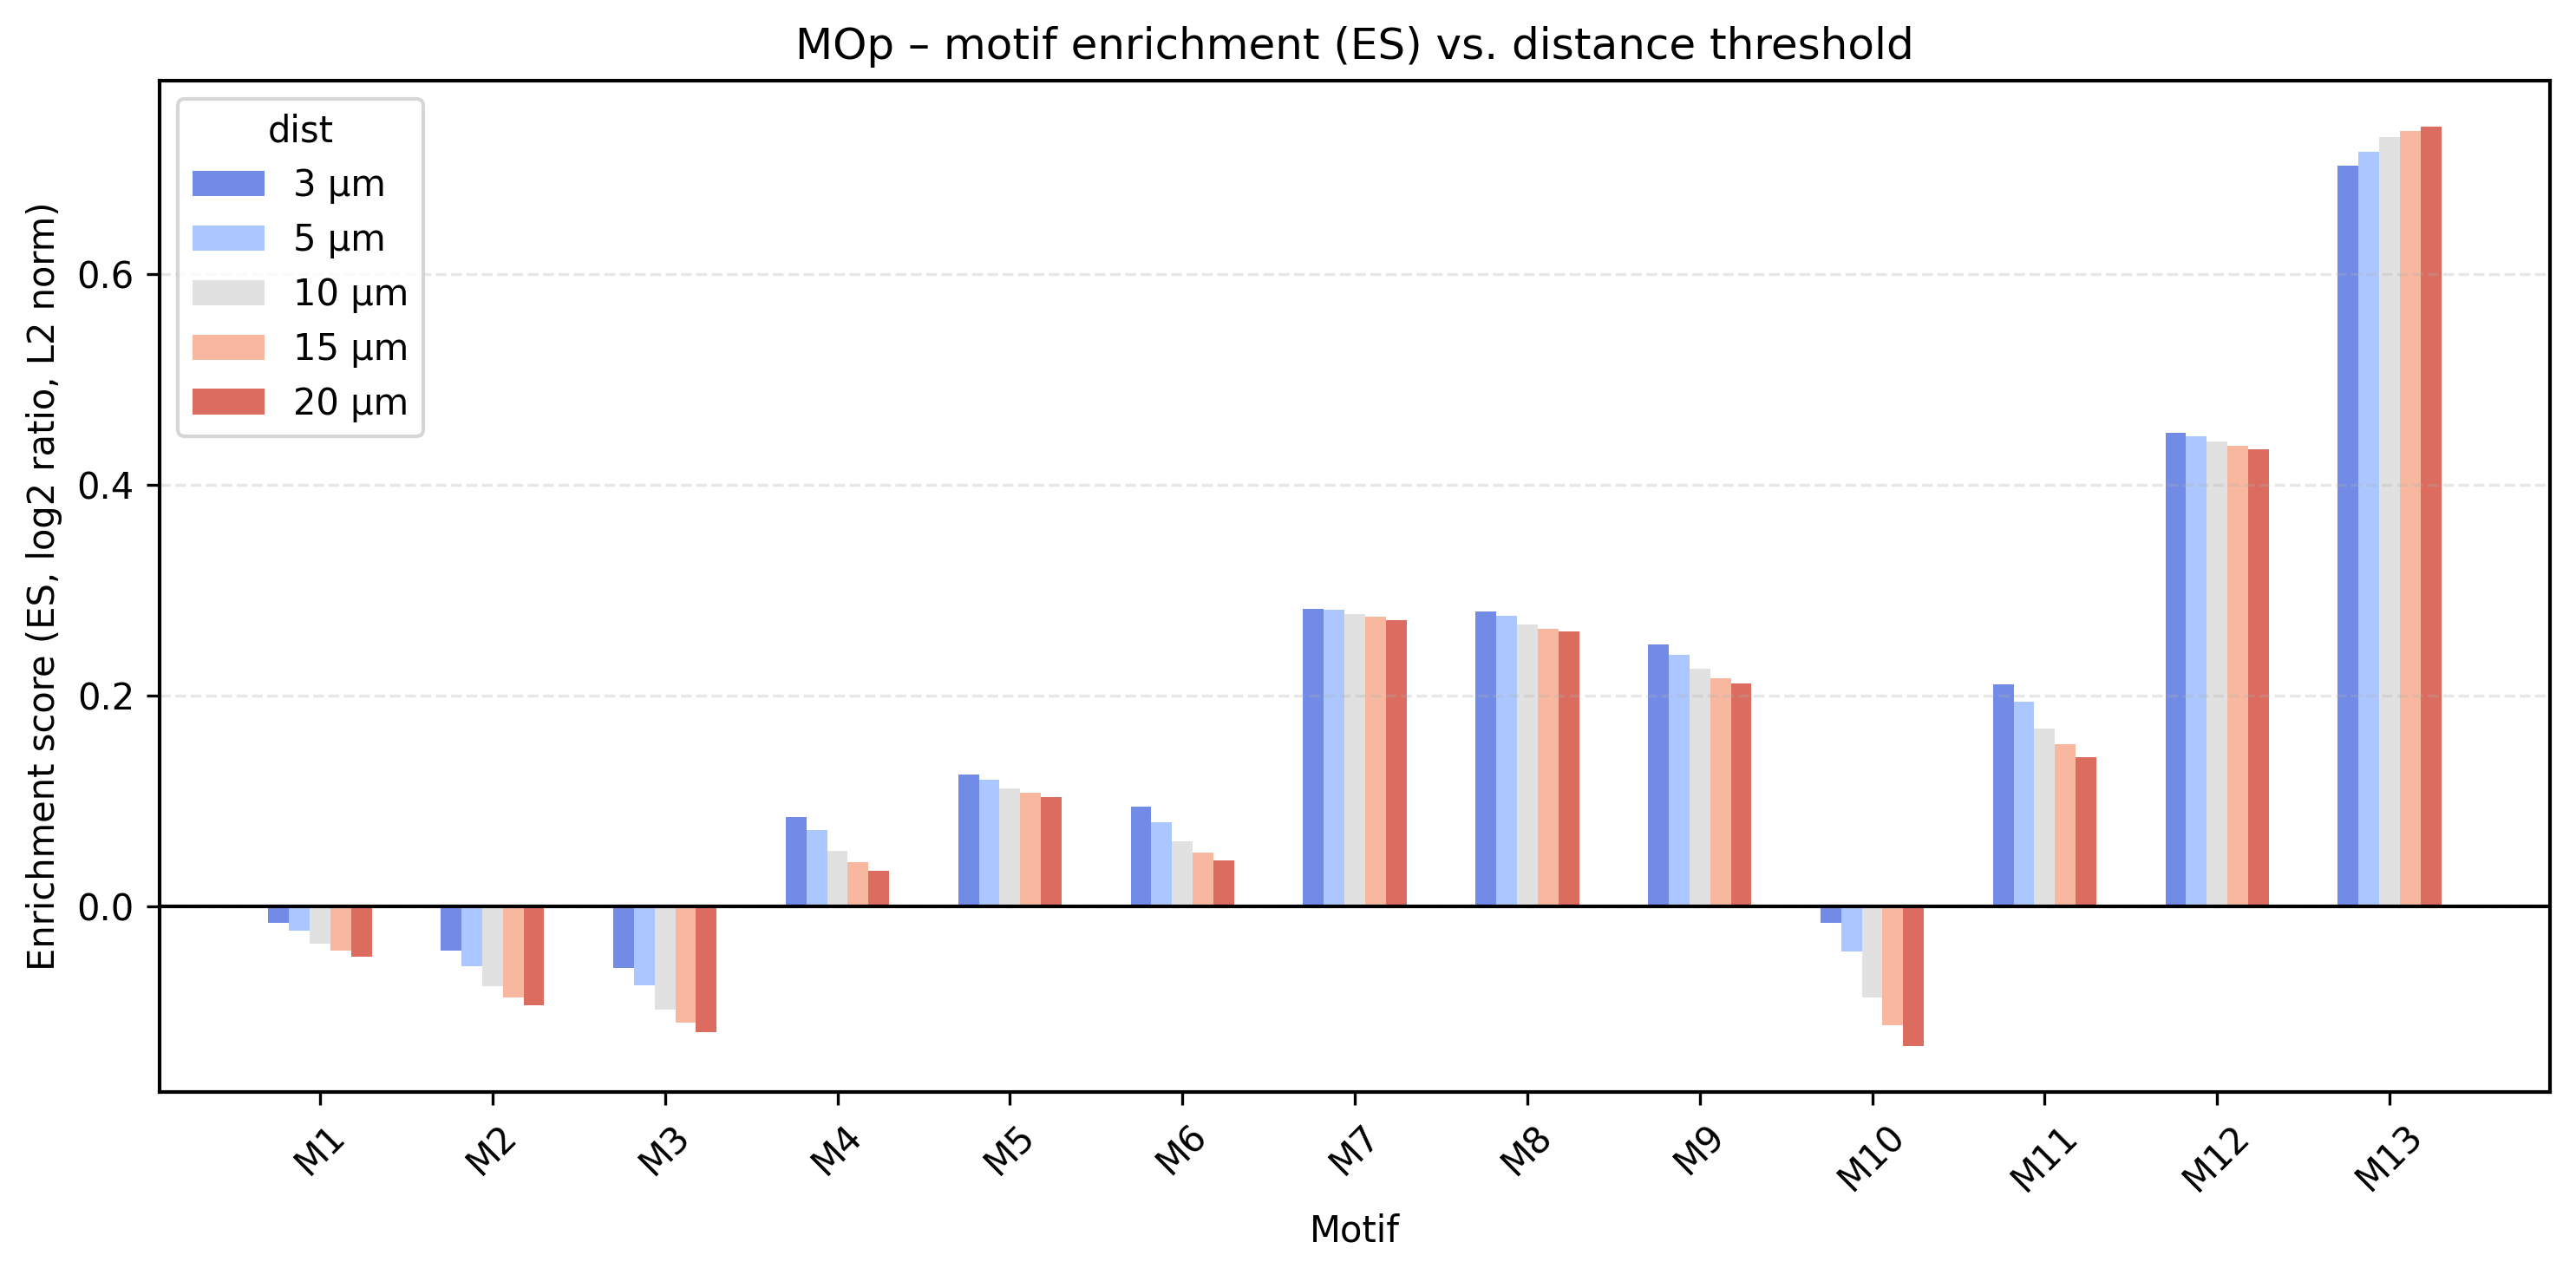

In [24]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. 基本参数 =====
pkl_path   = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
region     = "MOp"                 # 换成你想看的脑区
param_list = [ 3, 5, 10, 15, 20] # 不同距离阈值
thr        = "0.1"                   # motif_results 的 key

# ===== 1. 读数据 =====
with open(pkl_path, "rb") as f:
    results = pickle.load(f)["results"]   # dict[param][region]["motif_results"][thr]

freq_dict = {}
nz_dict   = {}
es_dict   = {}

for p in param_list:
    mr = results[p][region]["motif_results"][thr]

    # ---- 频率：real_motif / sum ----
    real = np.asarray(mr["real_motif"], float)
    freq_dict[p] = real / real.sum()

    # ---- NZ ----
    nz = np.asarray(mr["NZ"], float)
    nz_dict[p] = nz

    # ---- ES：用你指定的公式重算 ----
    # es_raw = log2(real) - log2(mu_eq), 然后 L2 归一化
    mu_eq  = np.asarray(mr["er_mu_eq"], float)
    es_raw = np.log2(real) - np.log2(mu_eq)
    es_norm = es_raw / np.linalg.norm(es_raw)
    es_dict[p] = es_norm

# 公共横坐标
x  = np.arange(13)
bw = 0.12

# ===== 2. 画 freq（motif frequency / sum）=====
params_freq = sorted(freq_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_freq):
    plt.bar(x + i*bw, freq_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_freq)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.ylabel("frequency (count / sum(count))")
plt.xlabel("Motif")
plt.title(f"{region} – motif frequency vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_frequency_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 3. 画 NZ =====
params_nz = sorted(nz_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_nz):
    plt.bar(x + i*bw, nz_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_nz)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("NZ-score")
plt.xlabel("Motif")
plt.title(f"{region} – motif NZ-score vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_NZ_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 4. 画 ES（用新公式计算的 ES_norm）=====
params_es = sorted(es_dict.keys())
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(params_freq)))

plt.figure(figsize=(10, 5))
for i, p in enumerate(params_es):
    plt.bar(x + i*bw, es_dict[p], width=bw,
            alpha=0.85, color=colors[i], label=f"{p} µm")
plt.xticks(x + bw*(len(params_es)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("Enrichment score (ES, log2 ratio, L2 norm)")
plt.xlabel("Motif")
plt.title(f"{region} – motif enrichment (ES) vs. distance threshold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="dist")
plt.tight_layout()
plt.savefig(f"6.{region}_motif_ES_vs_param.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

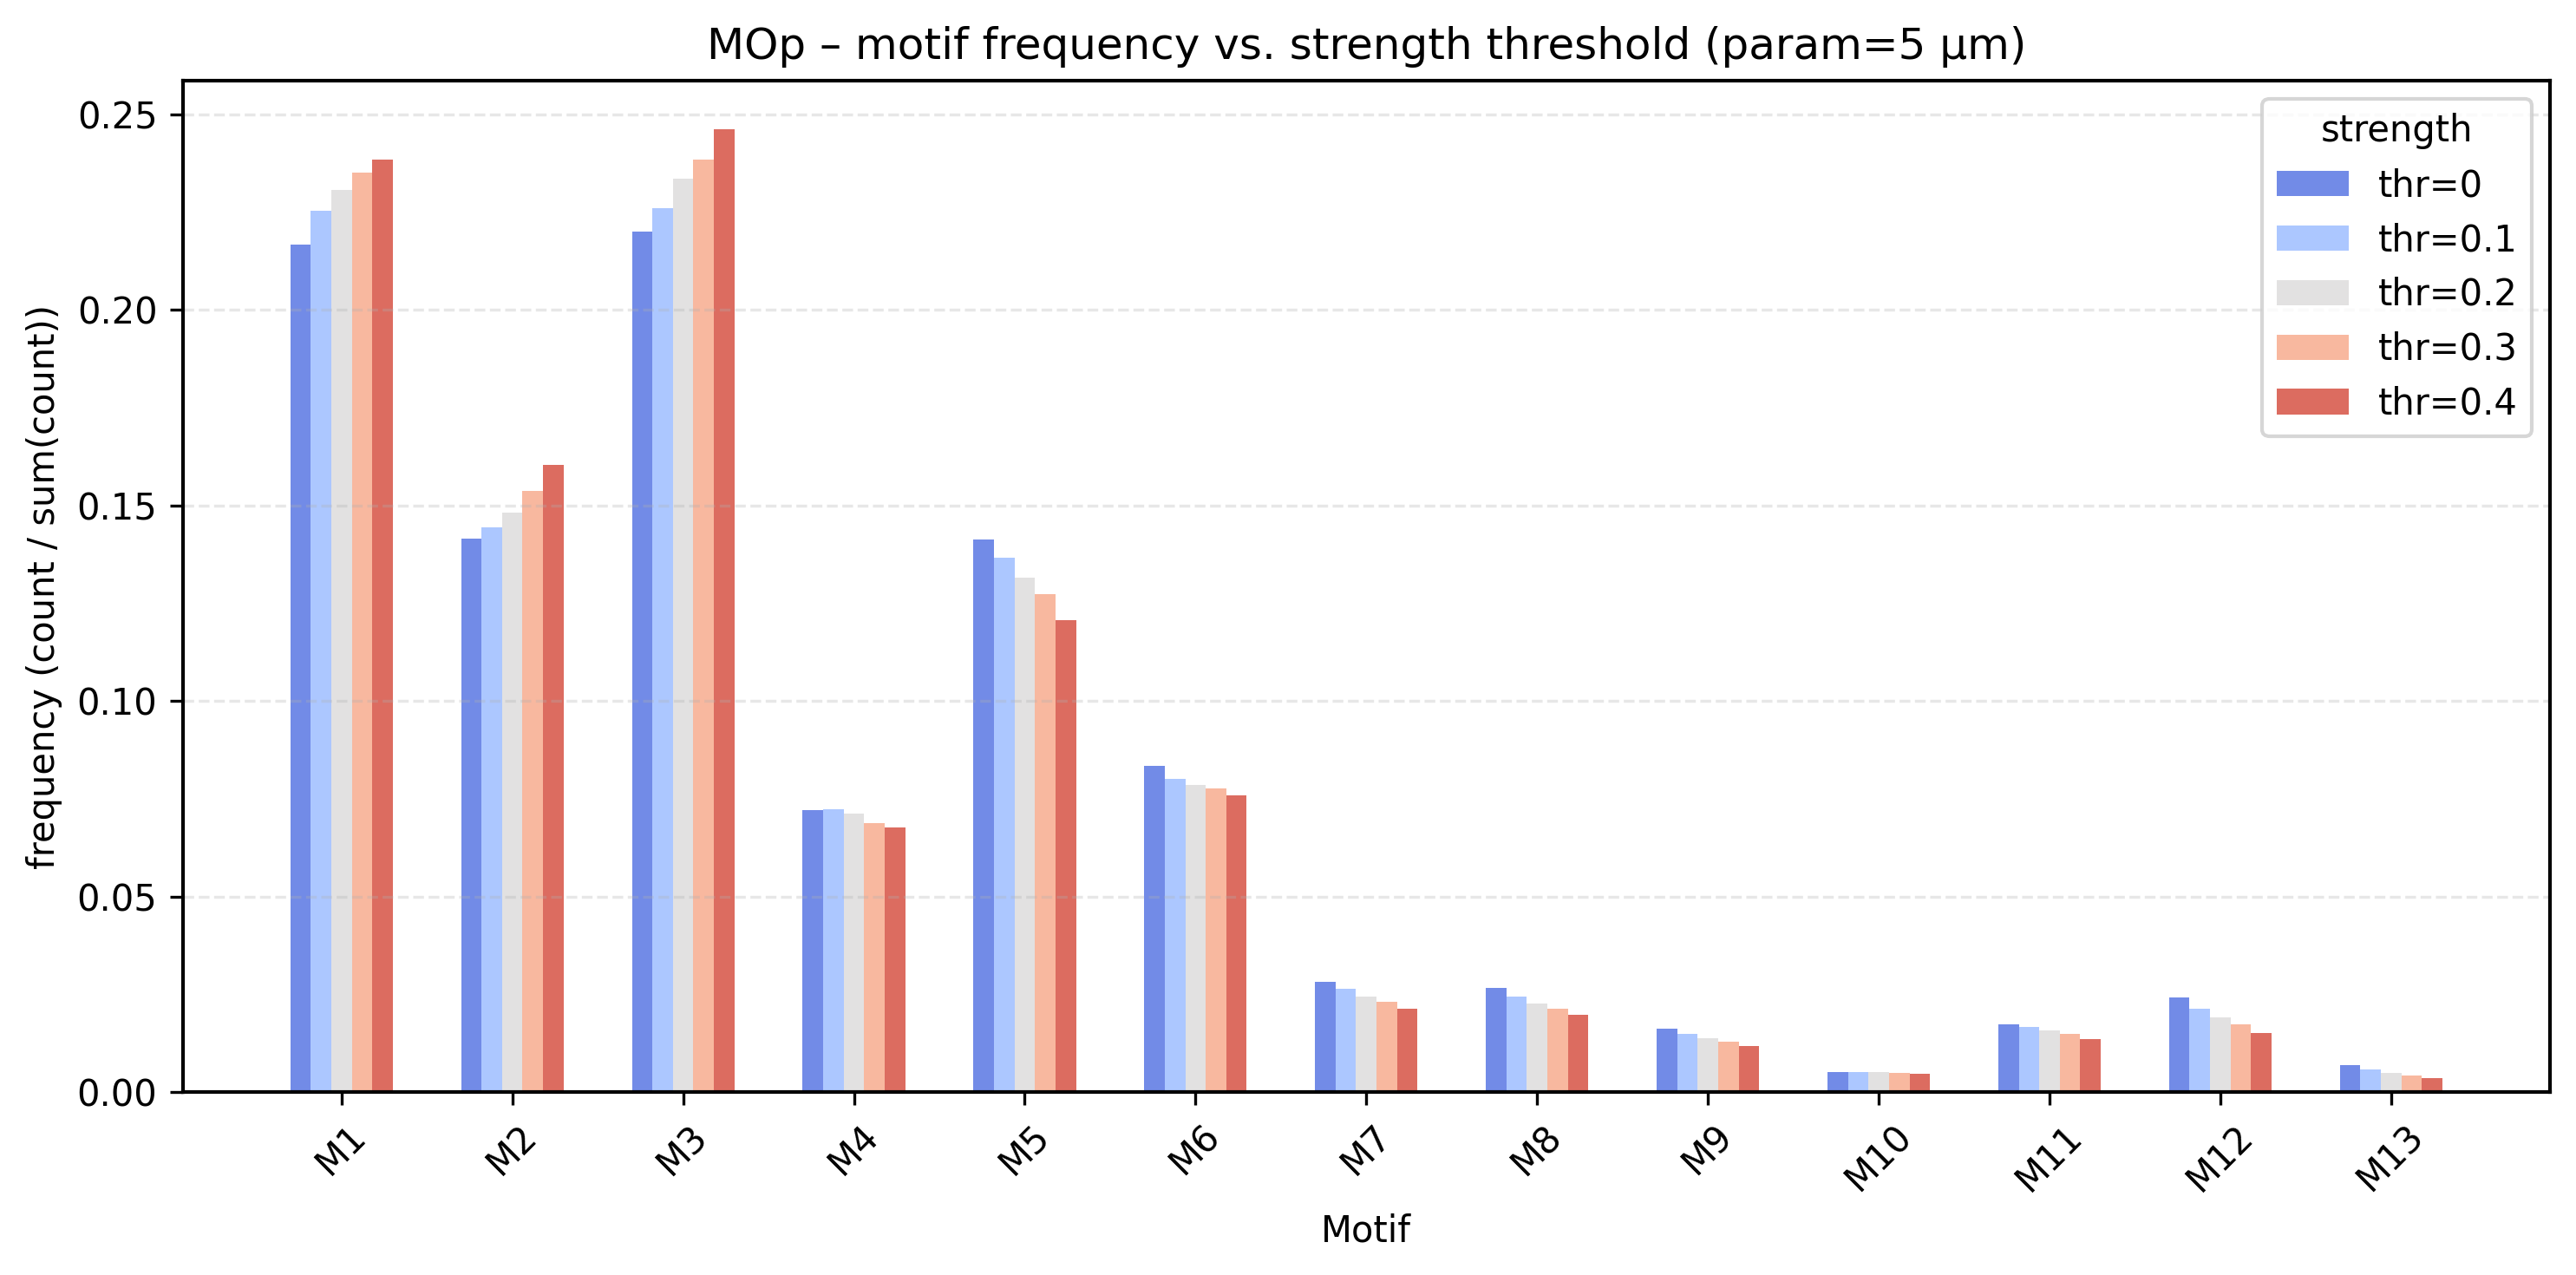

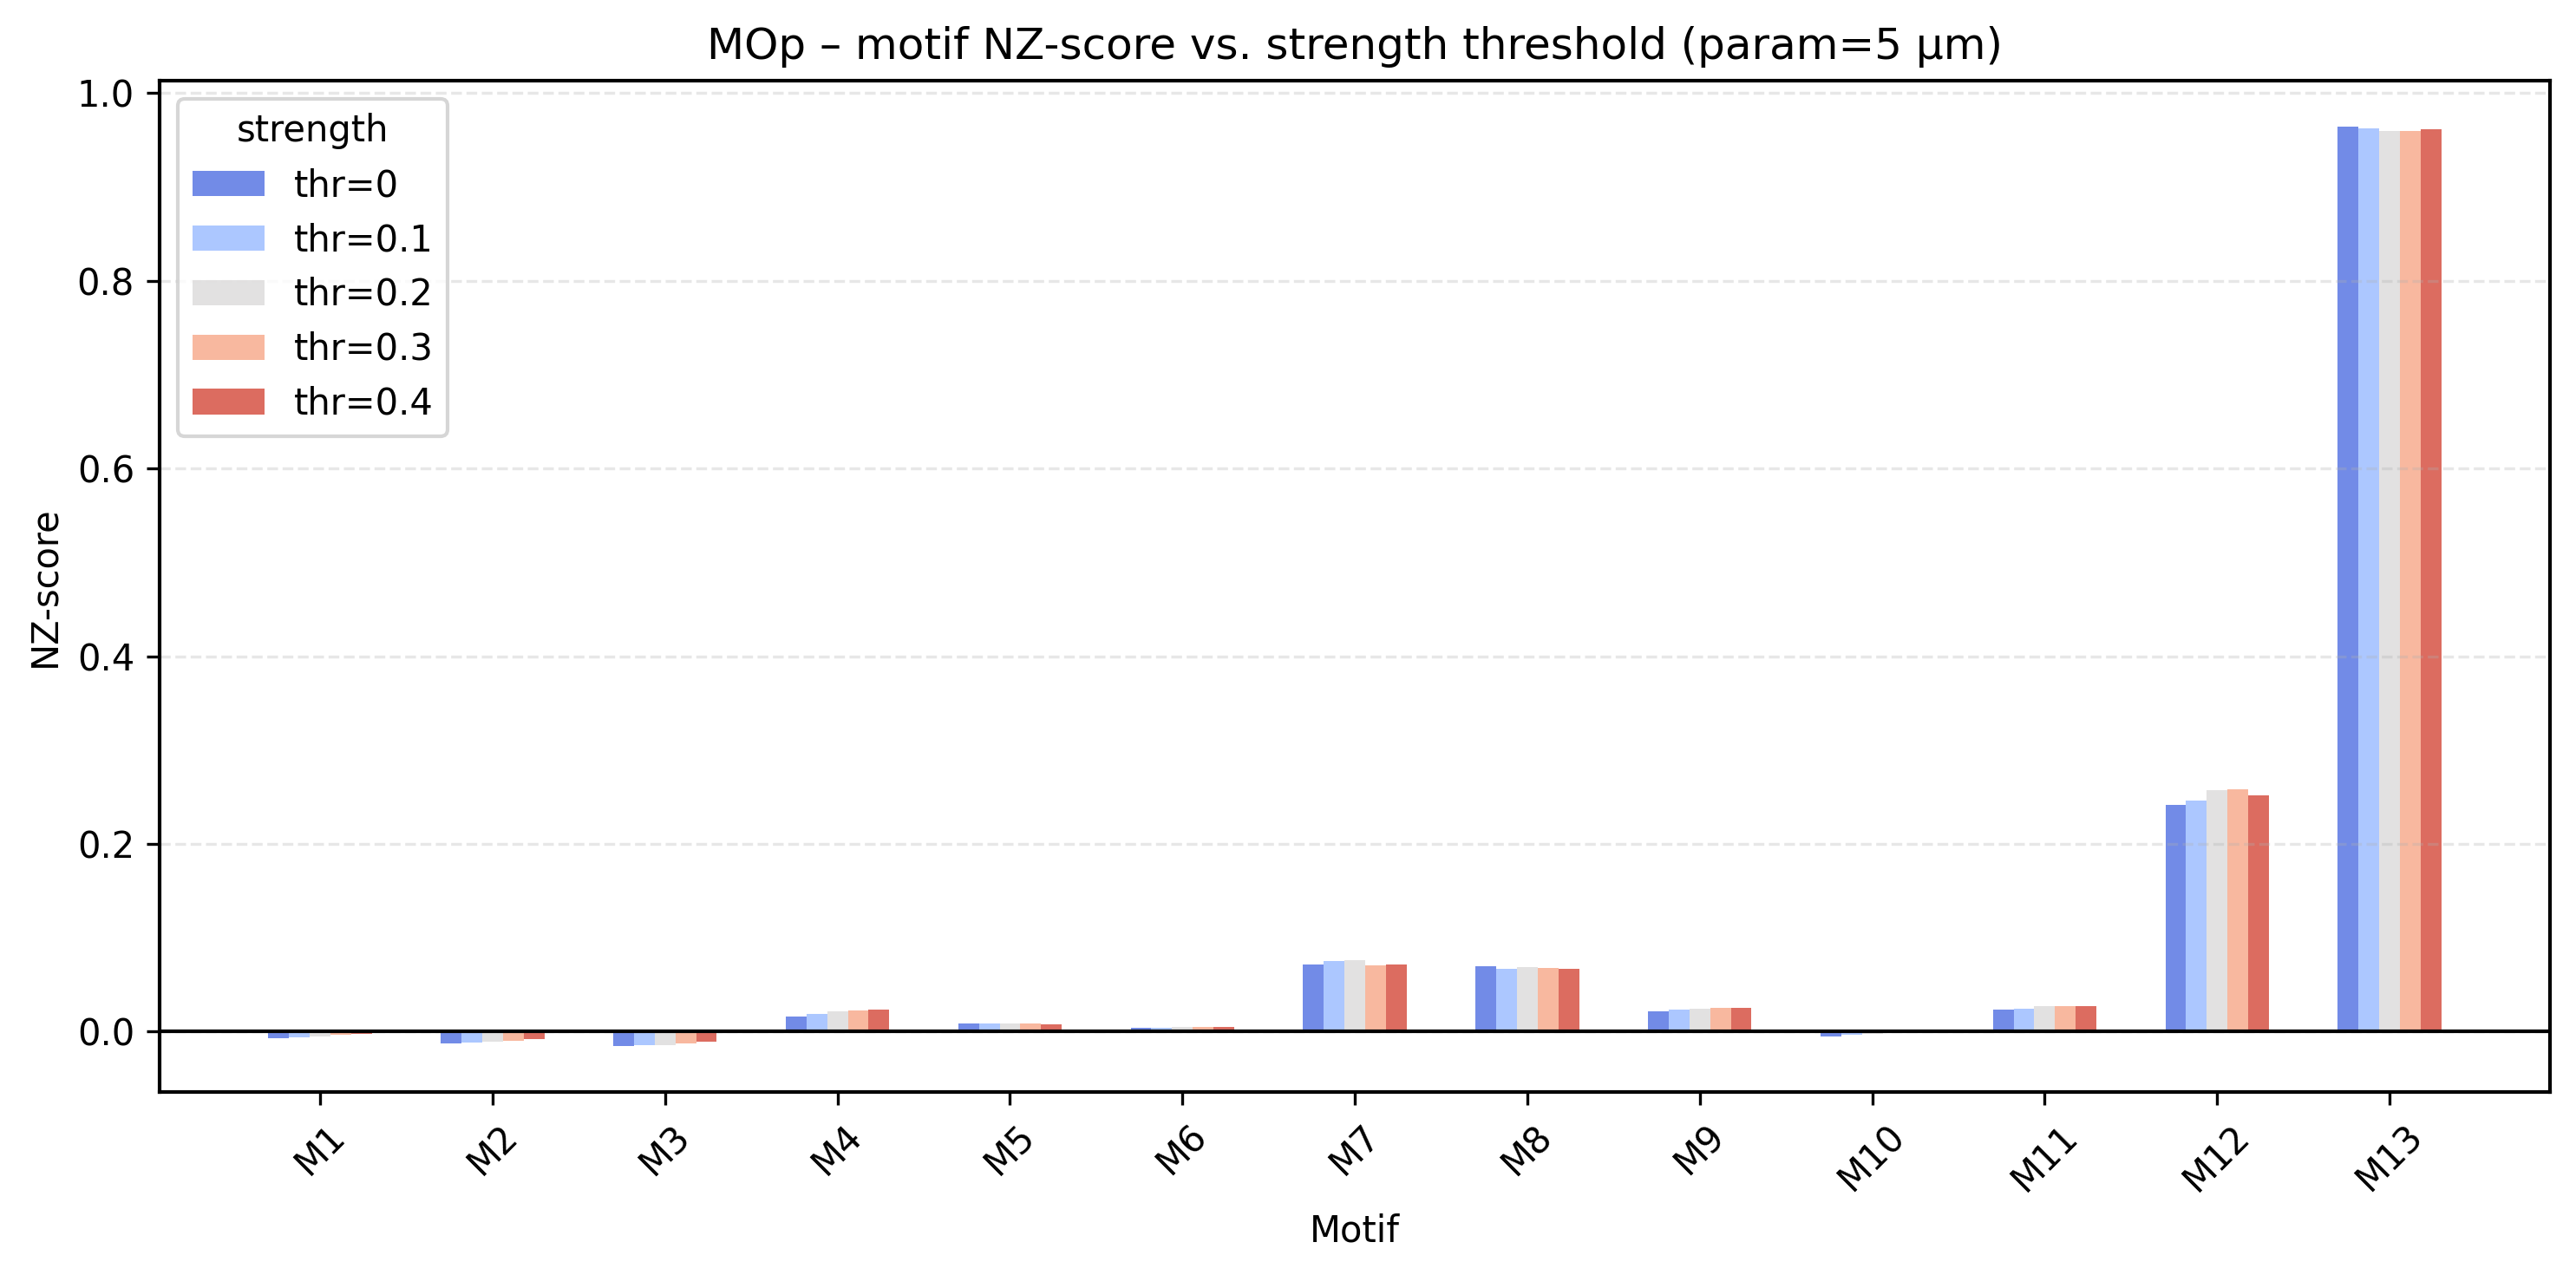

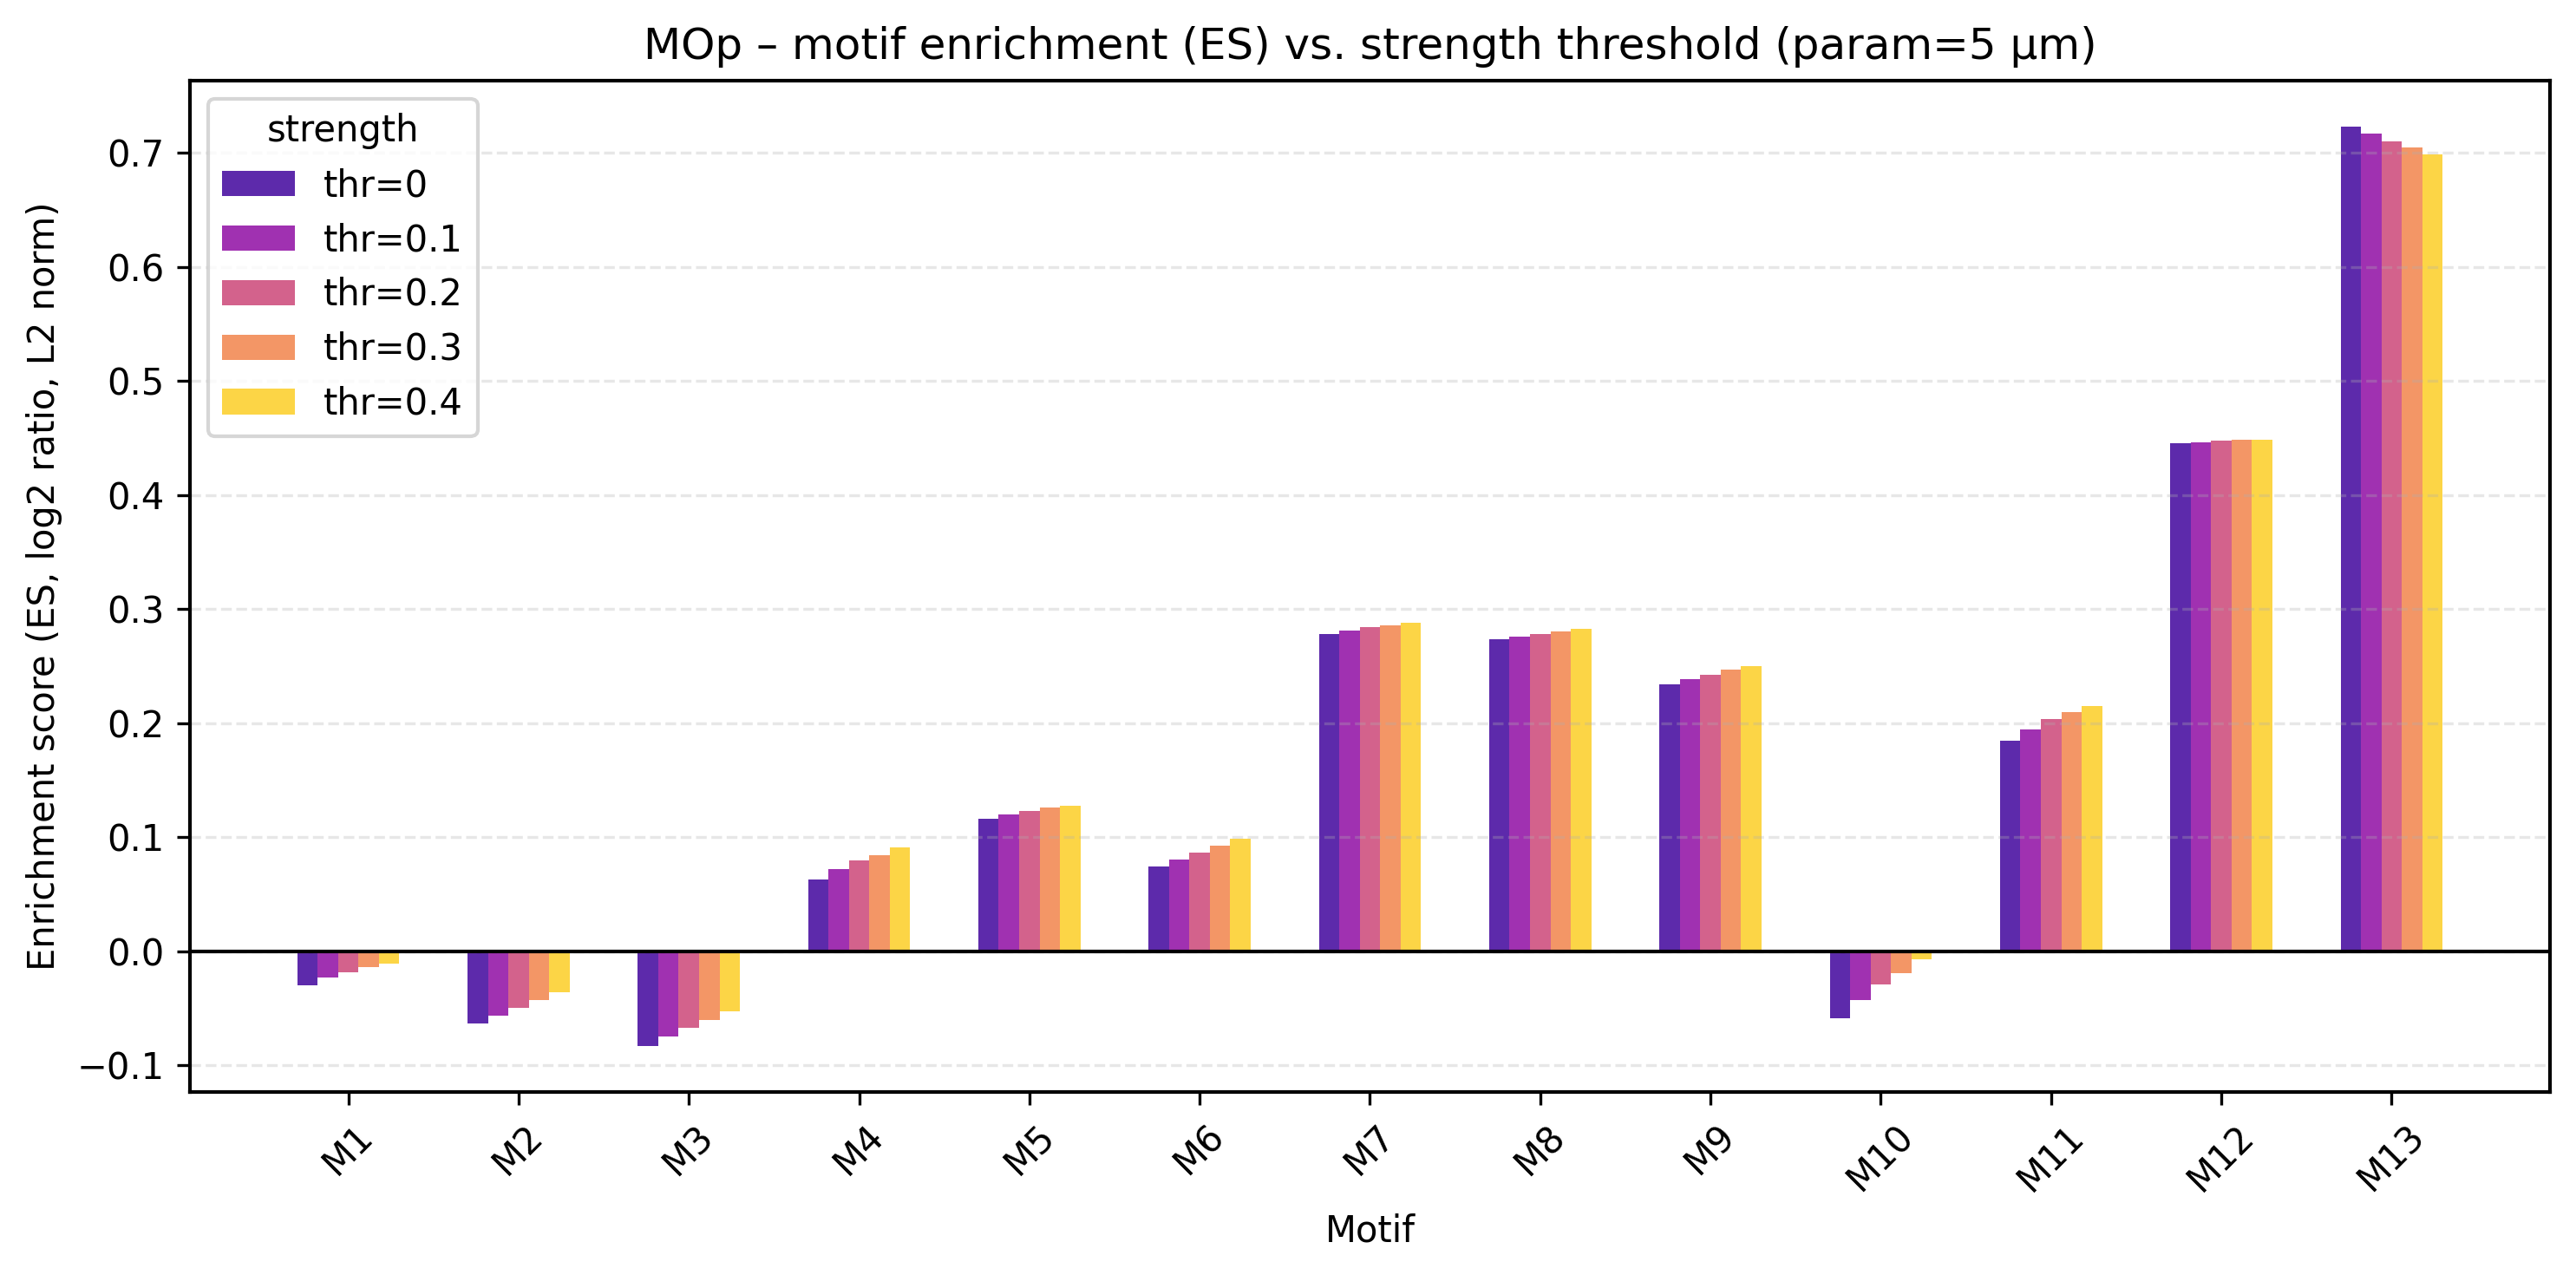

In [25]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. 基本参数 =====
pkl_path   = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
region     = "MOp"                 # 换成你想看的脑区
param      = 5                     # 固定距离阈值 5 µm
thr_list   = ["0", "0.1", "0.2", "0.3", "0.4"]   # 五个不同连接强度阈值

# ===== 1. 读数据 =====
with open(pkl_path, "rb") as f:
    results = pickle.load(f)["results"]   # dict[param][region]["motif_results"][thr]

freq_dict = {}
nz_dict   = {}
es_dict   = {}

for thr in thr_list:
    mr = results[param][region]["motif_results"][thr]

    # ---- 频率：real_motif / sum ----
    real = np.asarray(mr["real_motif"], float)
    freq_dict[thr] = real / real.sum()

    # ---- NZ ----
    nz = np.asarray(mr["NZ"], float)
    nz_dict[thr] = nz

    # ---- ES：用你指定的公式重算 ----
    mu_eq  = np.asarray(mr["er_mu_eq"], float)
    es_raw = np.log2(real) - np.log2(mu_eq)
    es_norm = es_raw / np.linalg.norm(es_raw)
    es_dict[thr] = es_norm

# 公共横坐标
x  = np.arange(13)
bw = 0.12

# ===== 2. 画 freq（motif frequency / sum）=====
thr_freq = [t for t in thr_list if t in freq_dict]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(thr_freq)))

plt.figure(figsize=(10, 5))
for i, thr in enumerate(thr_freq):
    plt.bar(x + i*bw, freq_dict[thr], width=bw,
            alpha=0.85, color=colors[i], label=f"thr={thr}")
plt.xticks(x + bw*(len(thr_freq)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.ylabel("frequency (count / sum(count))")
plt.xlabel("Motif")
plt.title(f"{region} – motif frequency vs. strength threshold (param={param} µm)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="strength")
plt.tight_layout()
plt.savefig(f"8.{region}_motif_frequency_vs_strength.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 3. 画 NZ =====
thr_nz = [t for t in thr_list if t in nz_dict]
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(thr_nz)))

plt.figure(figsize=(10, 5))
for i, thr in enumerate(thr_nz):
    plt.bar(x + i*bw, nz_dict[thr], width=bw,
            alpha=0.85, color=colors[i], label=f"thr={thr}")
plt.xticks(x + bw*(len(thr_nz)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("NZ-score")
plt.xlabel("Motif")
plt.title(f"{region} – motif NZ-score vs. strength threshold (param={param} µm)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="strength")
plt.tight_layout()
plt.savefig(f"8.{region}_motif_NZ_vs_strength.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

# ===== 4. 画 ES（用新公式计算的 ES_norm）=====
thr_es = [t for t in thr_list if t in es_dict]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(thr_es)))

plt.figure(figsize=(10, 5))
for i, thr in enumerate(thr_es):
    plt.bar(x + i*bw, es_dict[thr], width=bw,
            alpha=0.85, color=colors[i], label=f"thr={thr}")
plt.xticks(x + bw*(len(thr_es)-1)/2,
           [f"M{i}" for i in range(1, 14)], rotation=45)
plt.axhline(0, color="k", lw=1)
plt.ylabel("Enrichment score (ES, log2 ratio, L2 norm)")
plt.xlabel("Motif")
plt.title(f"{region} – motif enrichment (ES) vs. strength threshold (param={param} µm)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="strength")
plt.tight_layout()
plt.savefig(f"8.{region}_motif_ES_vs_strength.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

In [12]:
real = results[1][region]["motif_results"]["0"]["real_motif"]
mu = results[1][region]["motif_results"]["0"]["er_mu_eq"]
print(np.log2(real)-np.log2(mu))

[ 0.13961044 -0.23537321 -0.52035632  3.19126185  3.94026091  3.7078191
  8.16305991  8.10962066  7.77813373  1.59771594  7.09759357 12.94395744
 19.44077687]


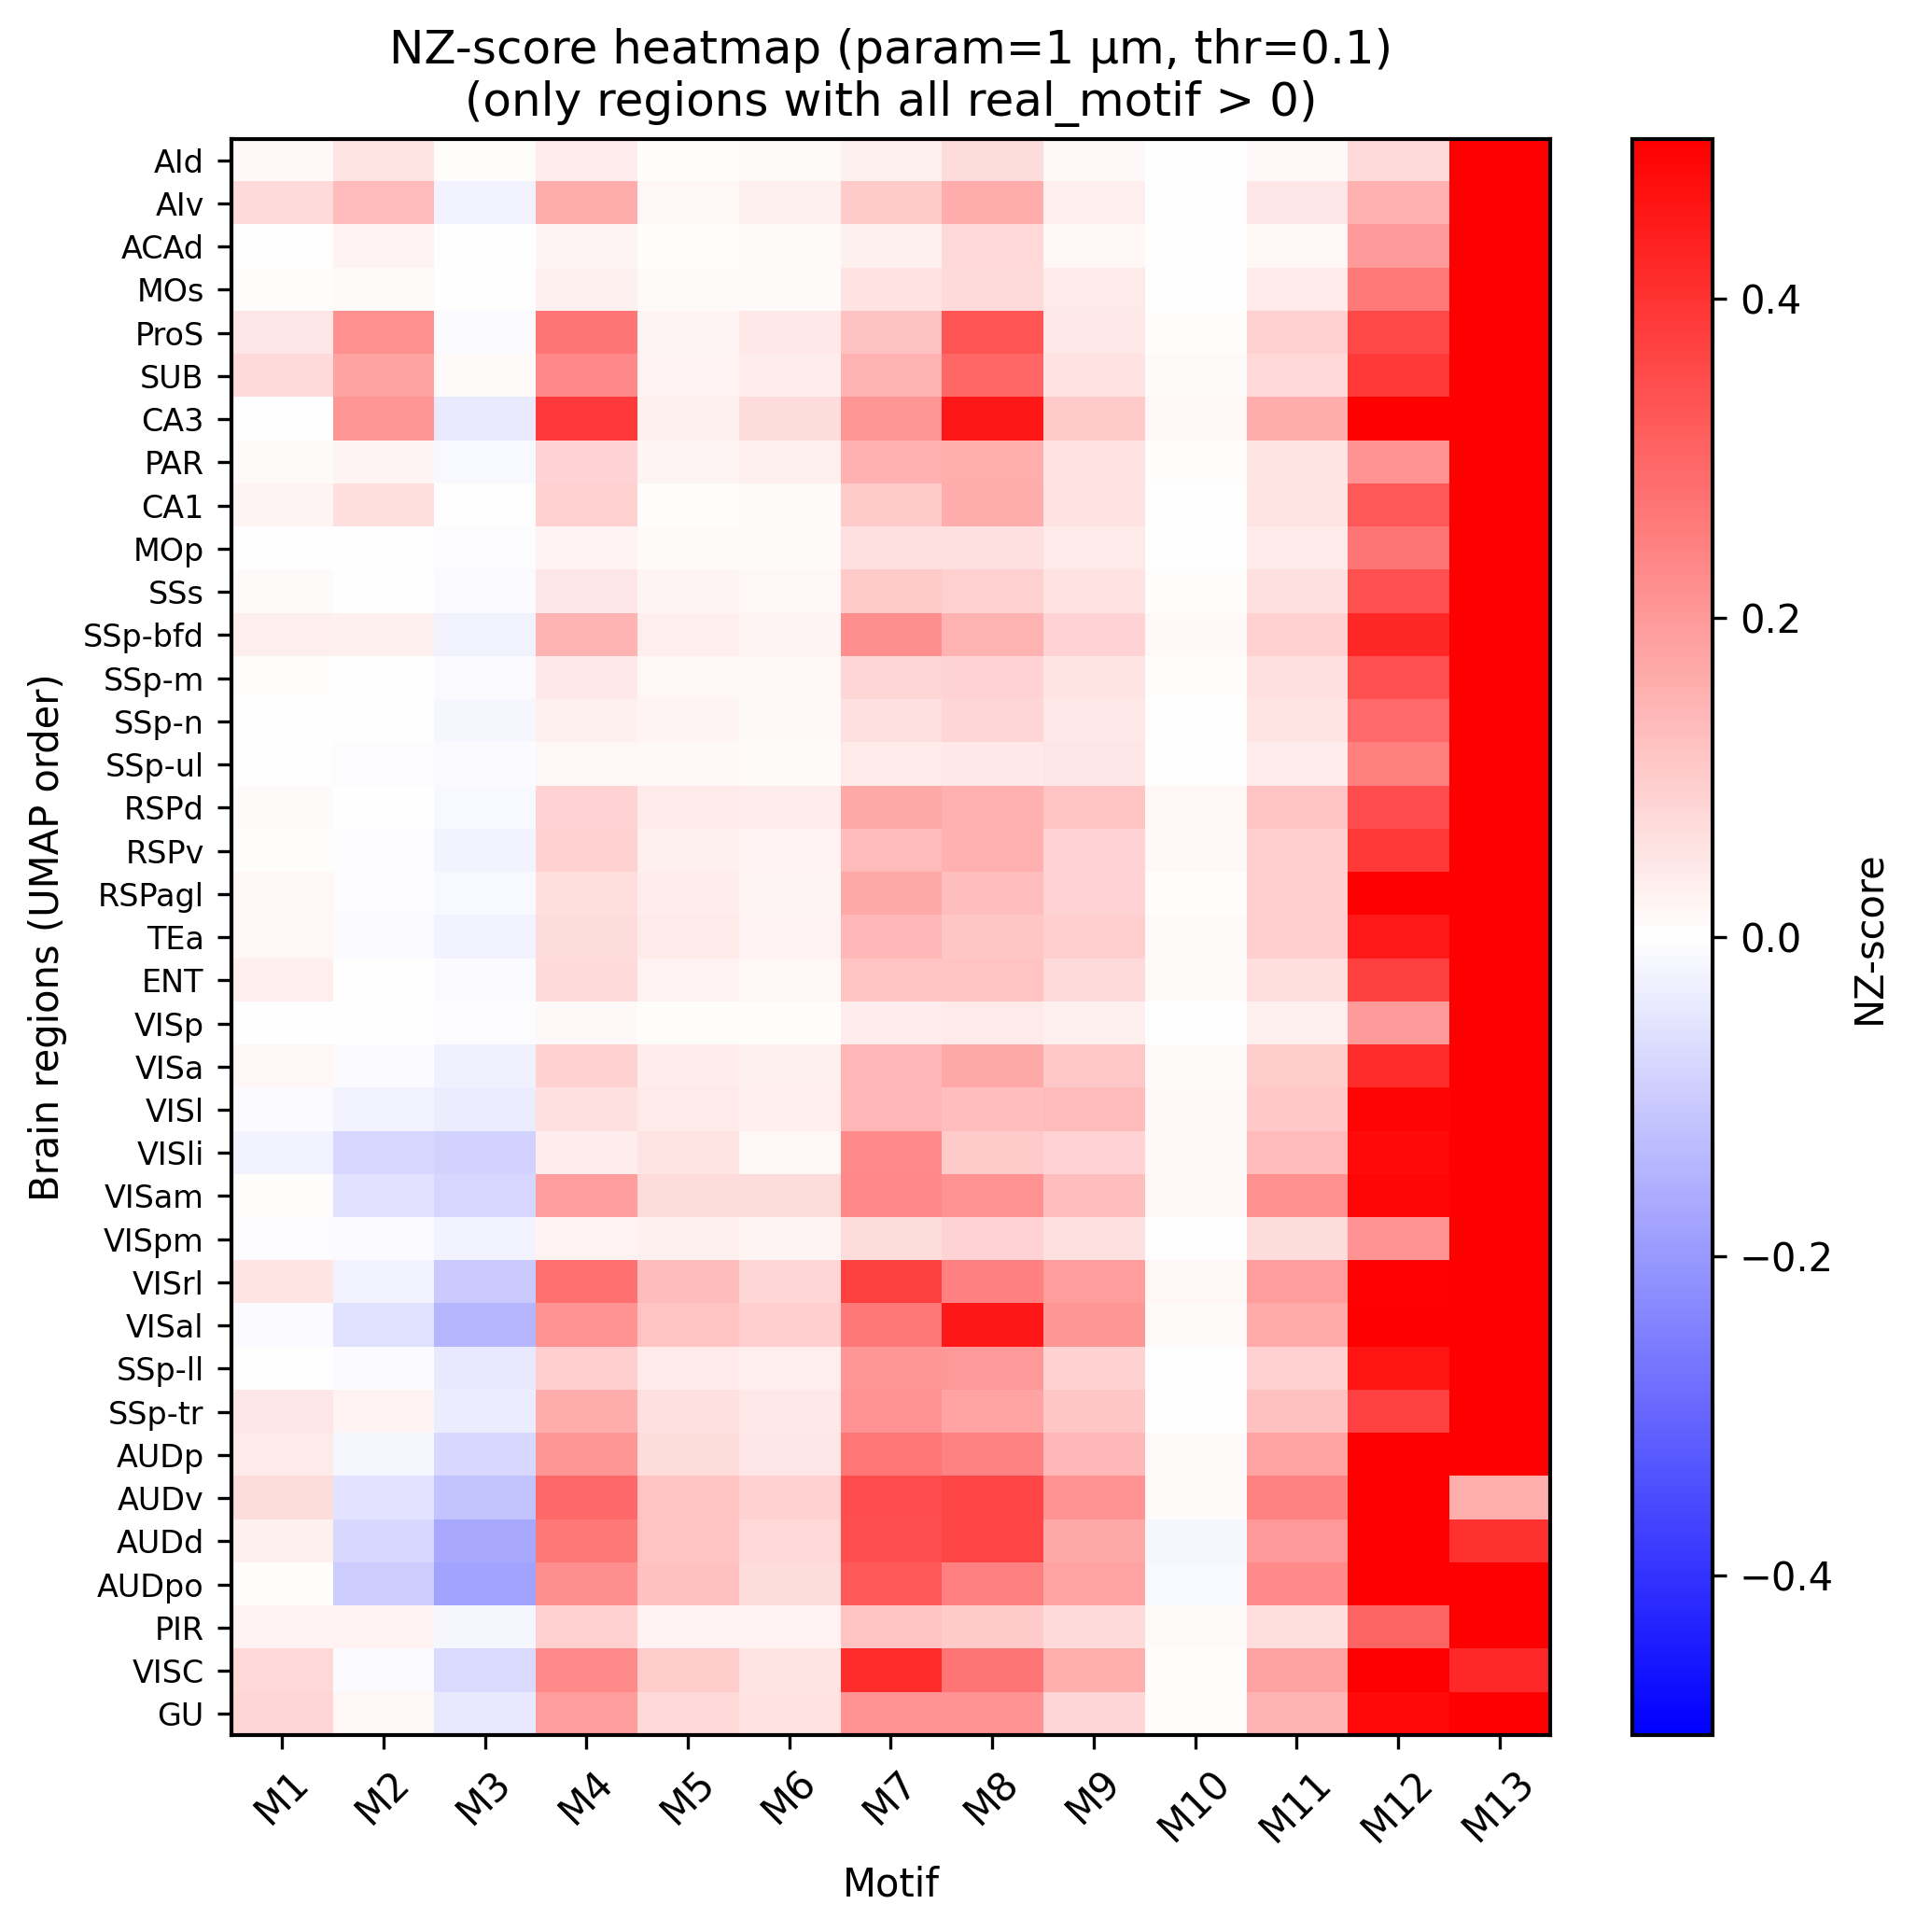

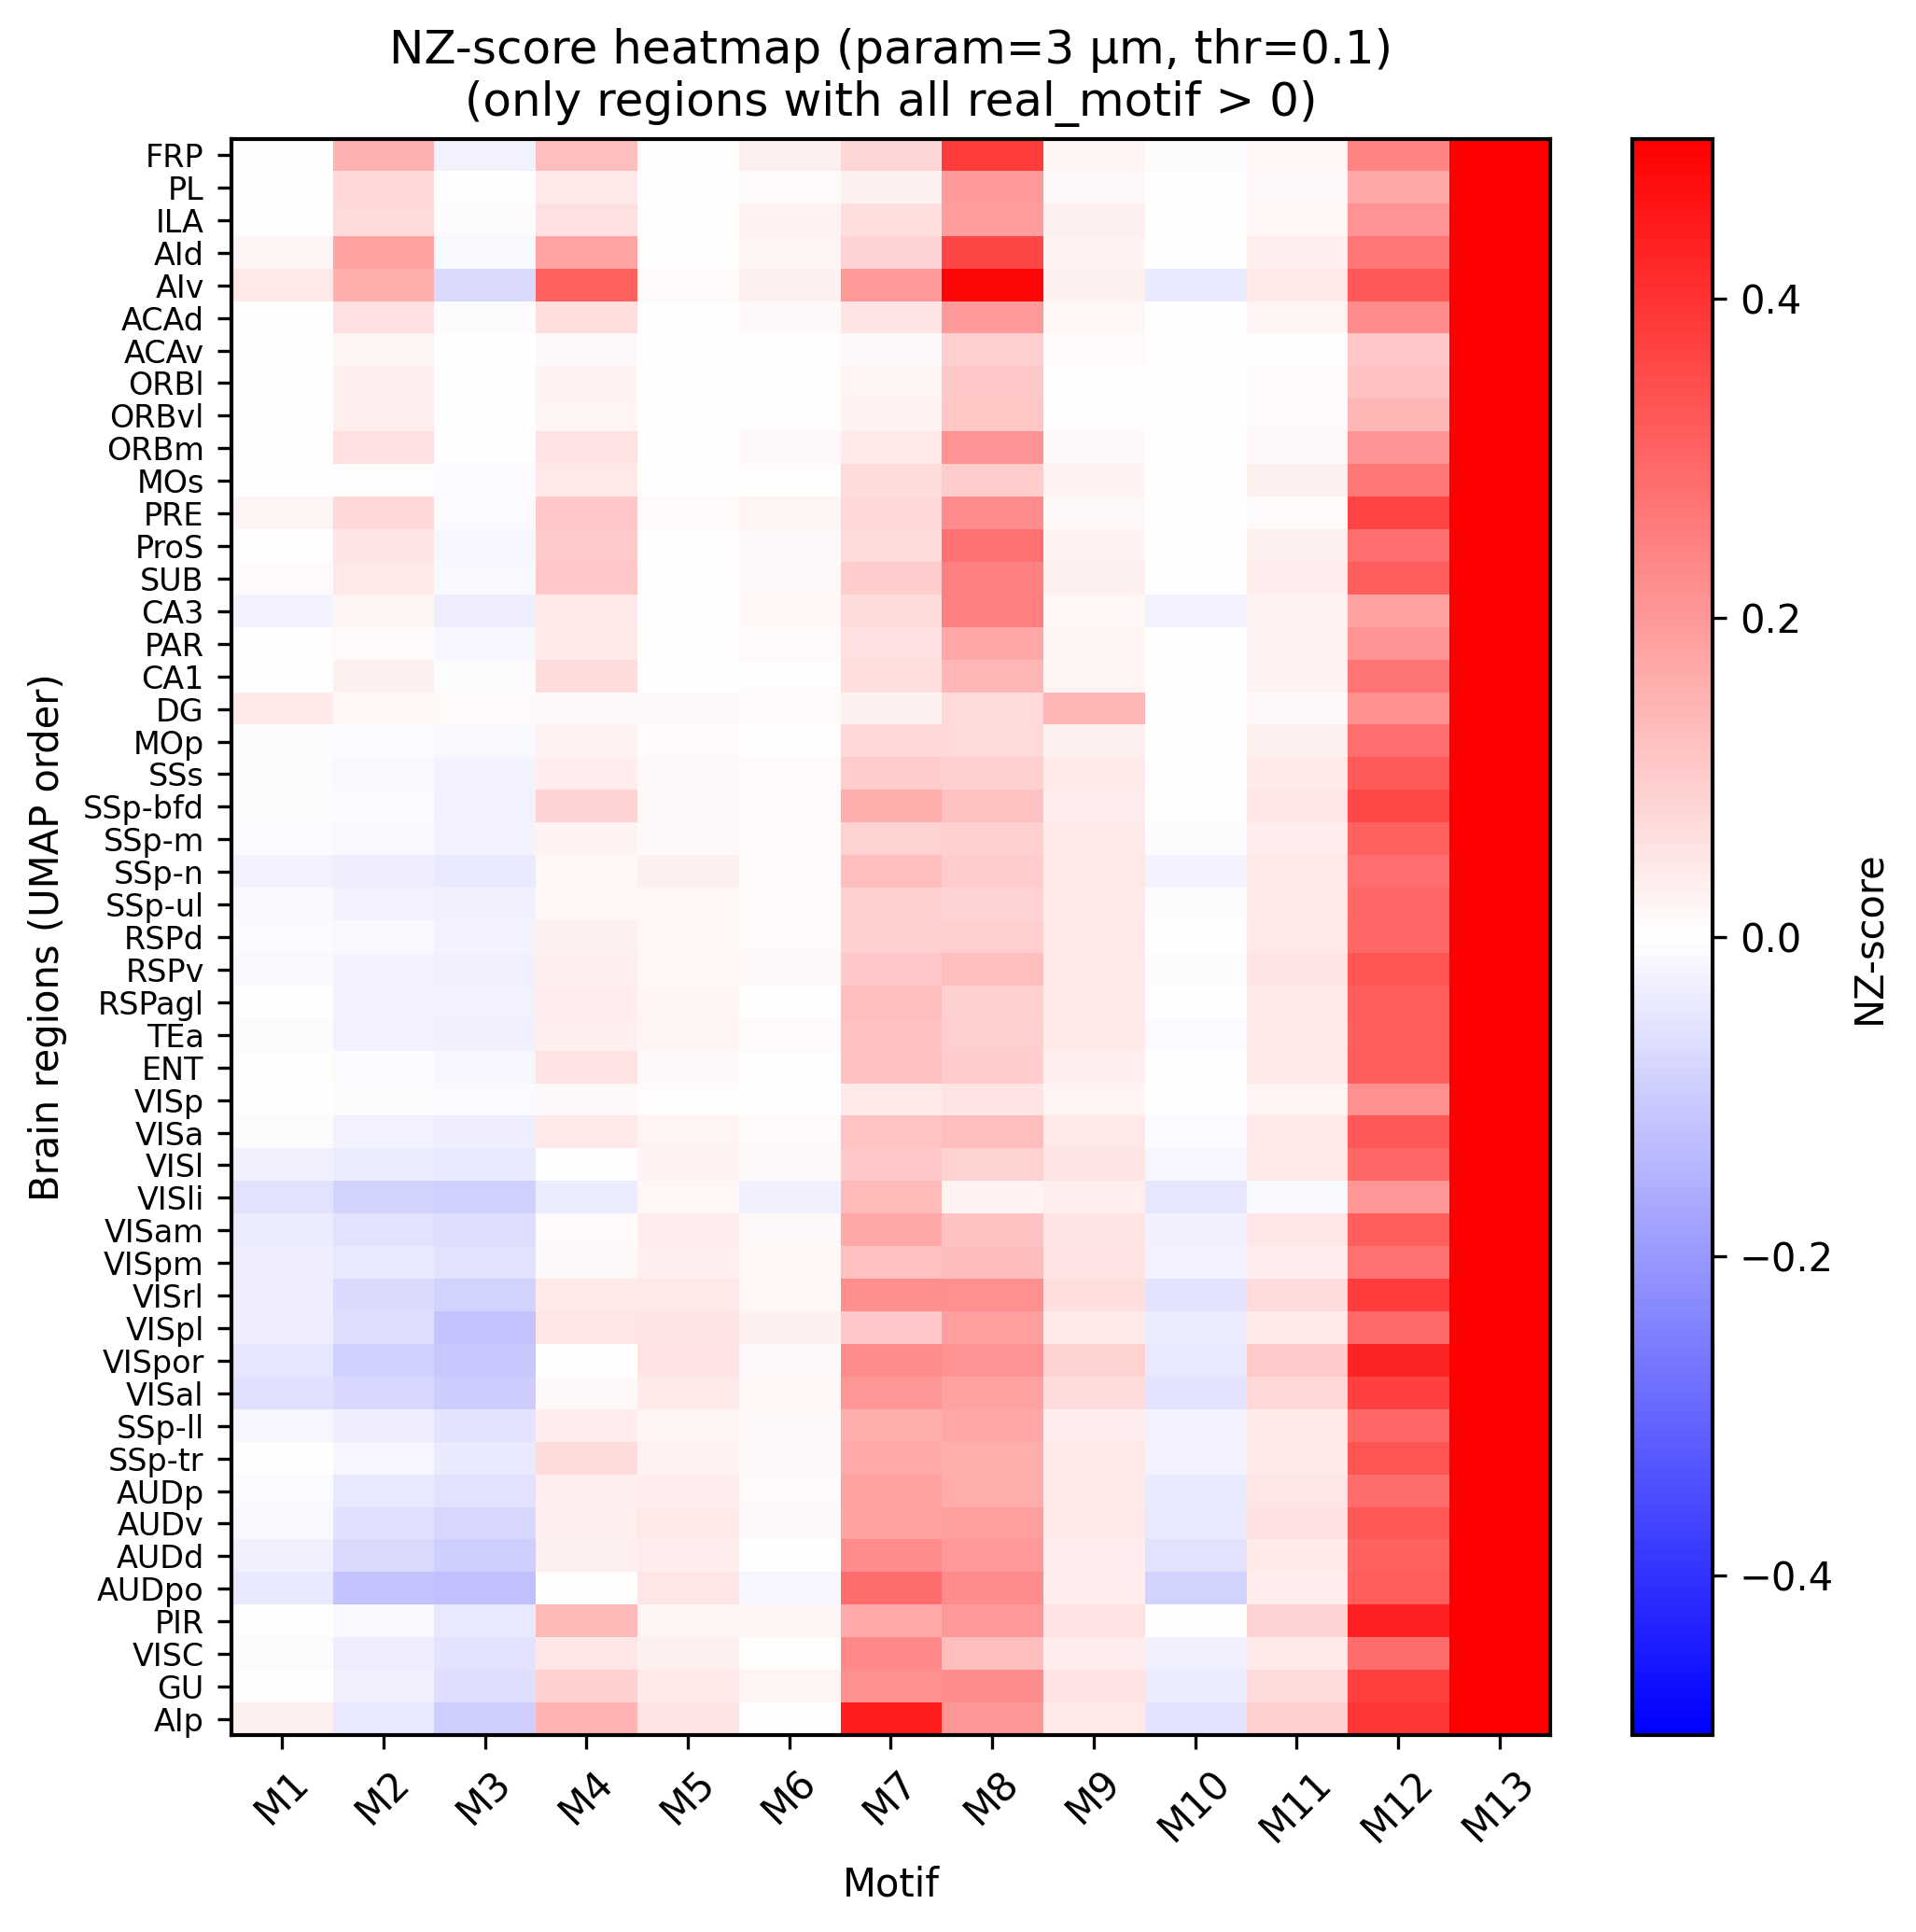

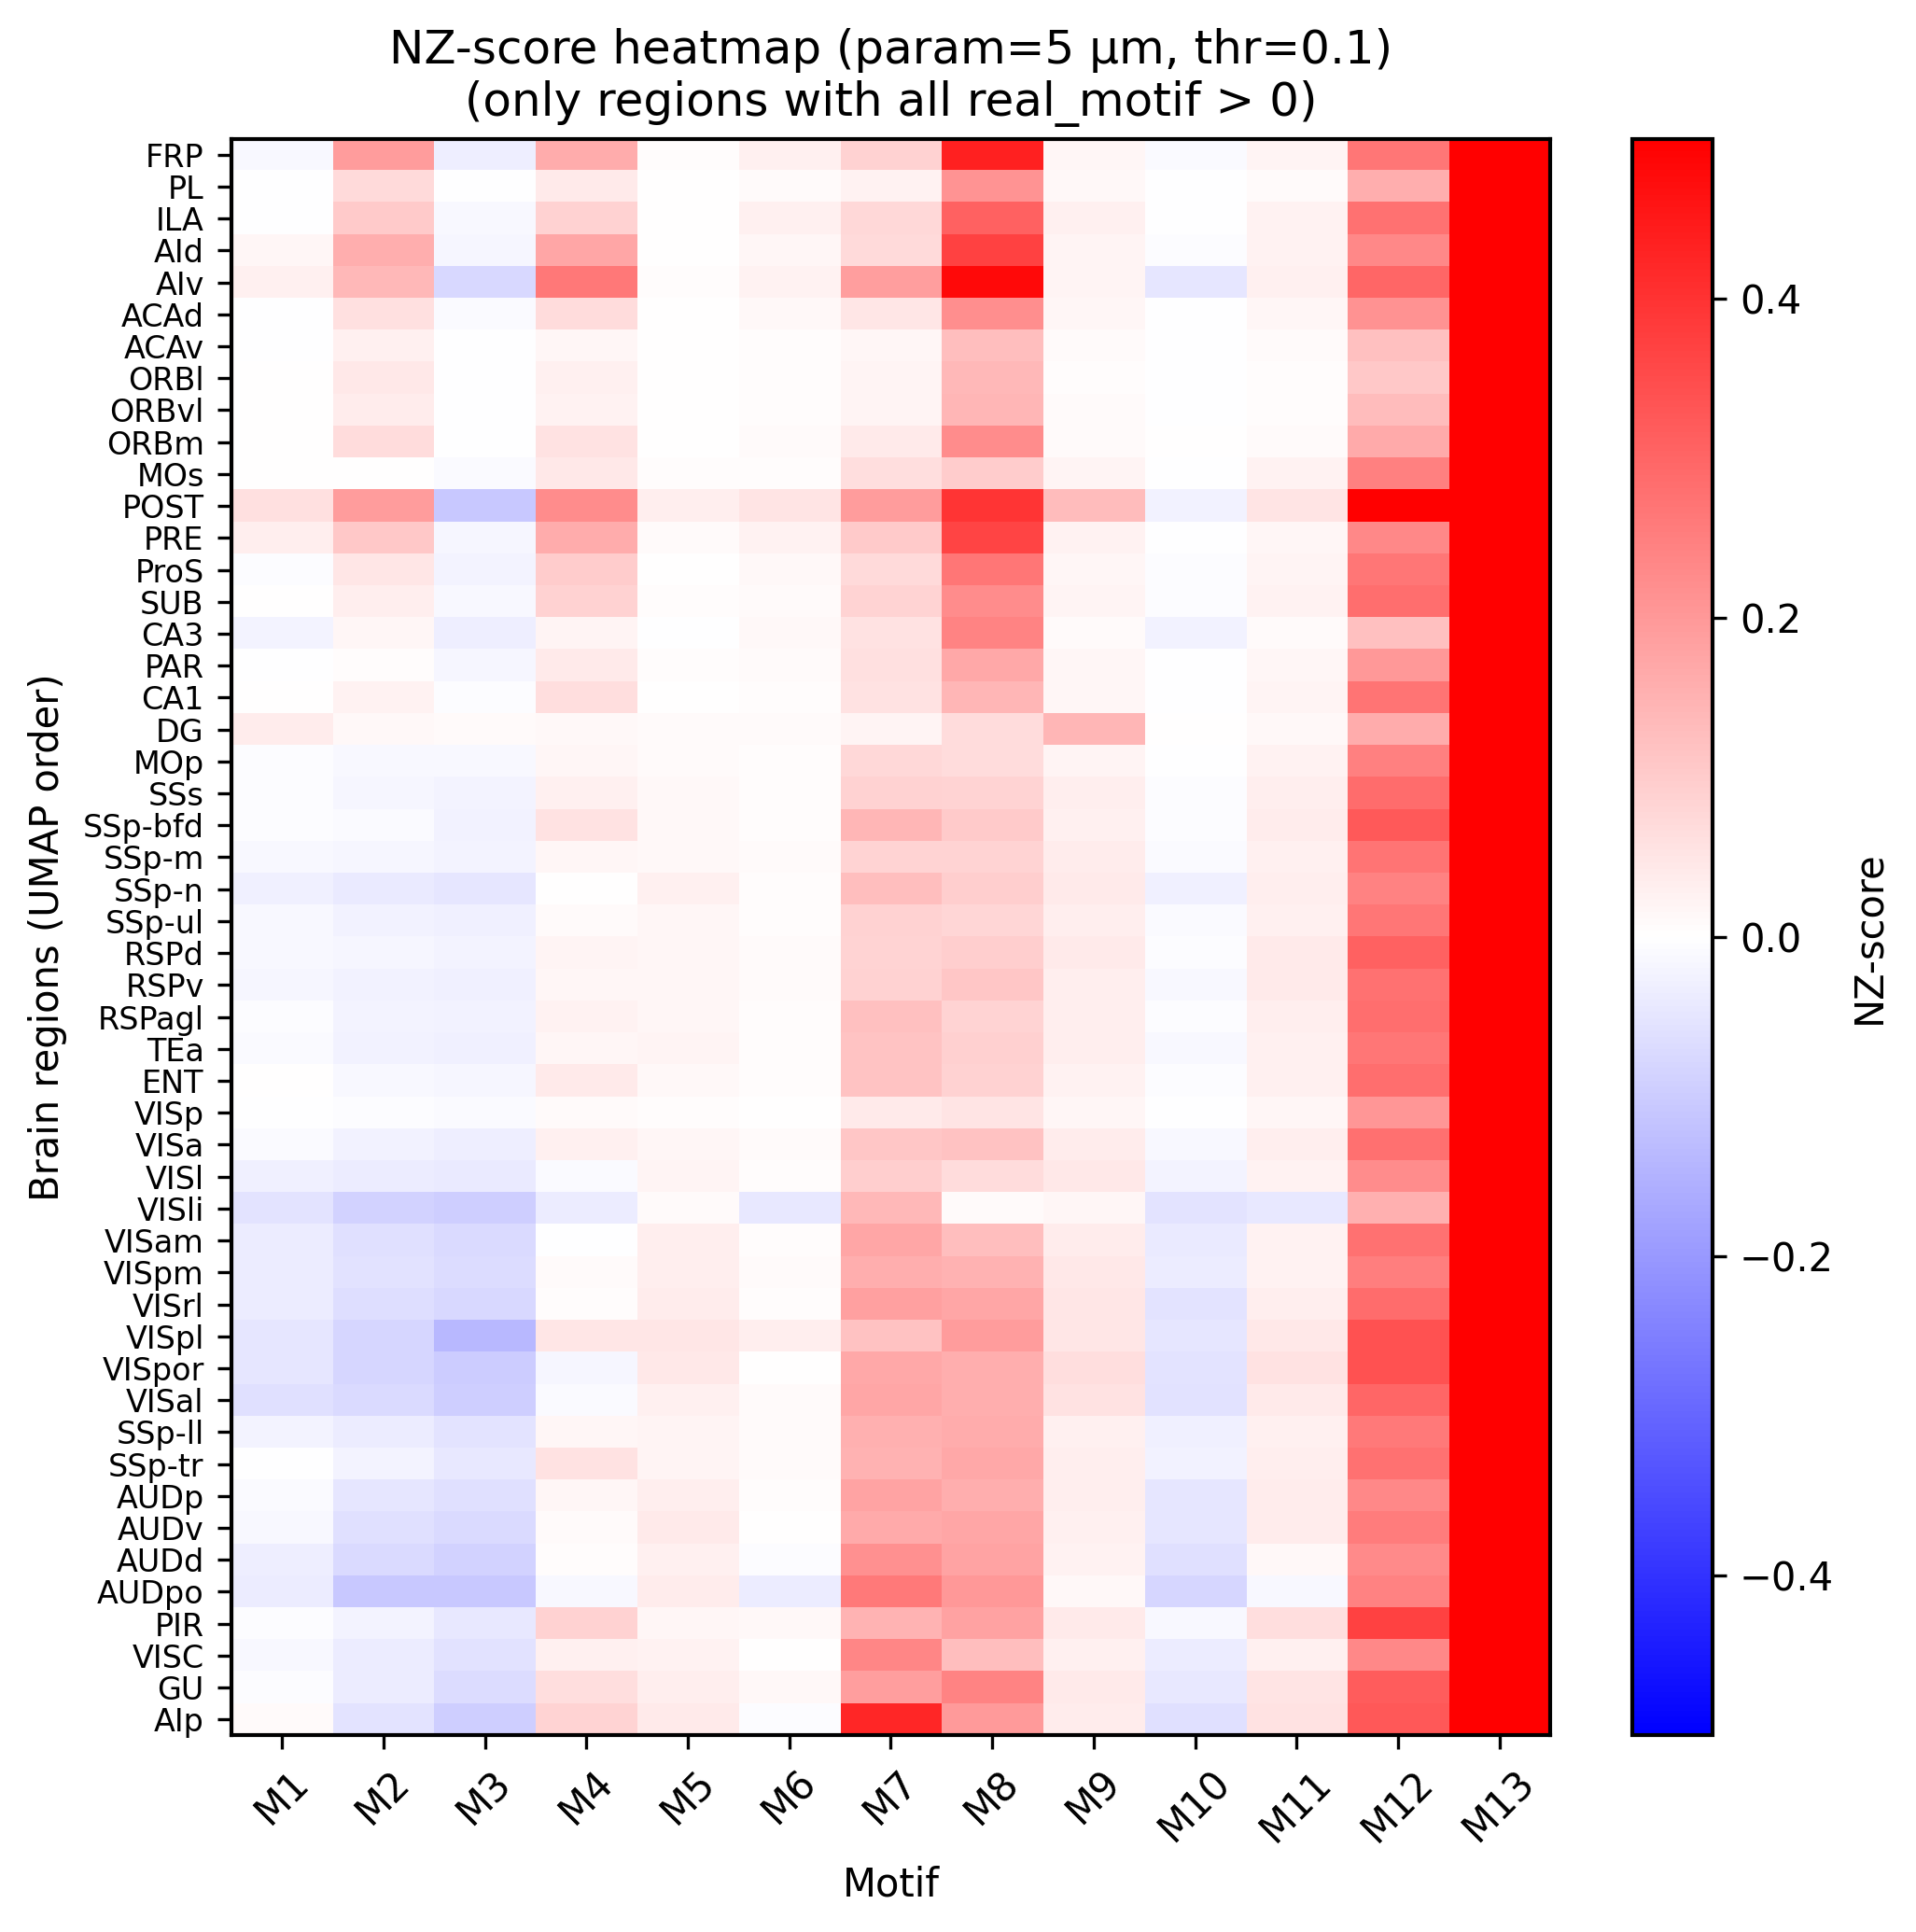

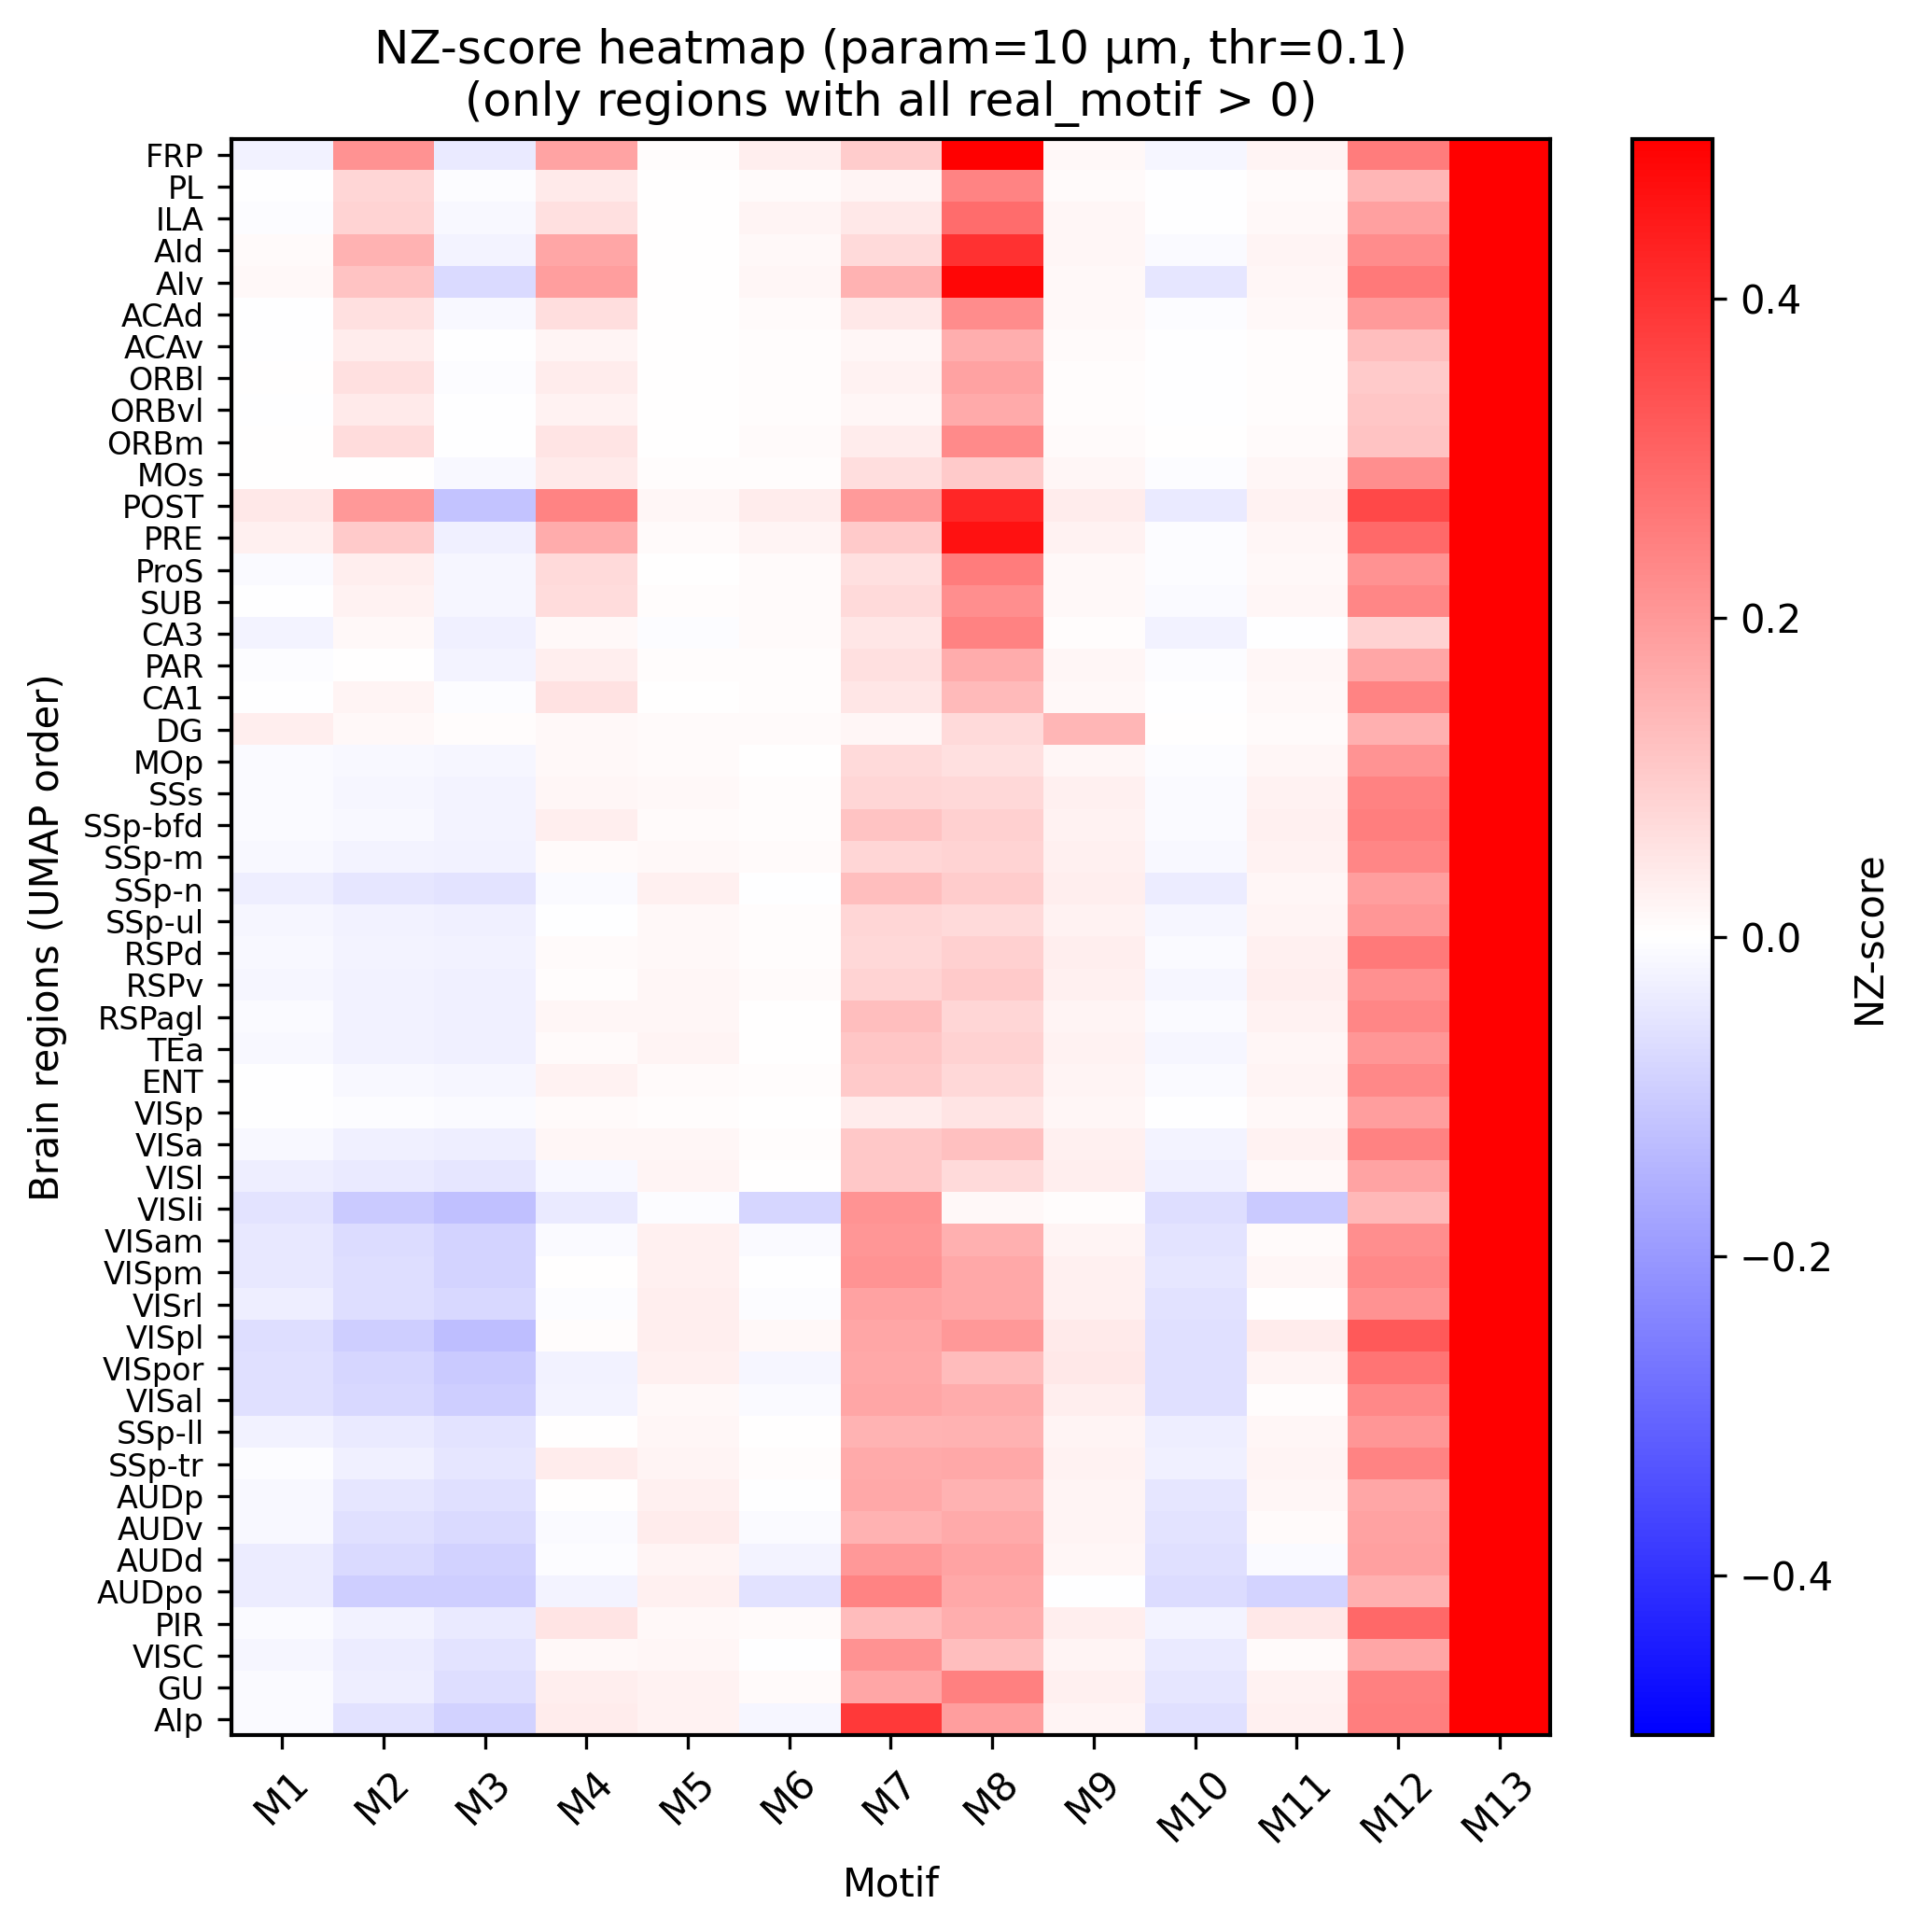

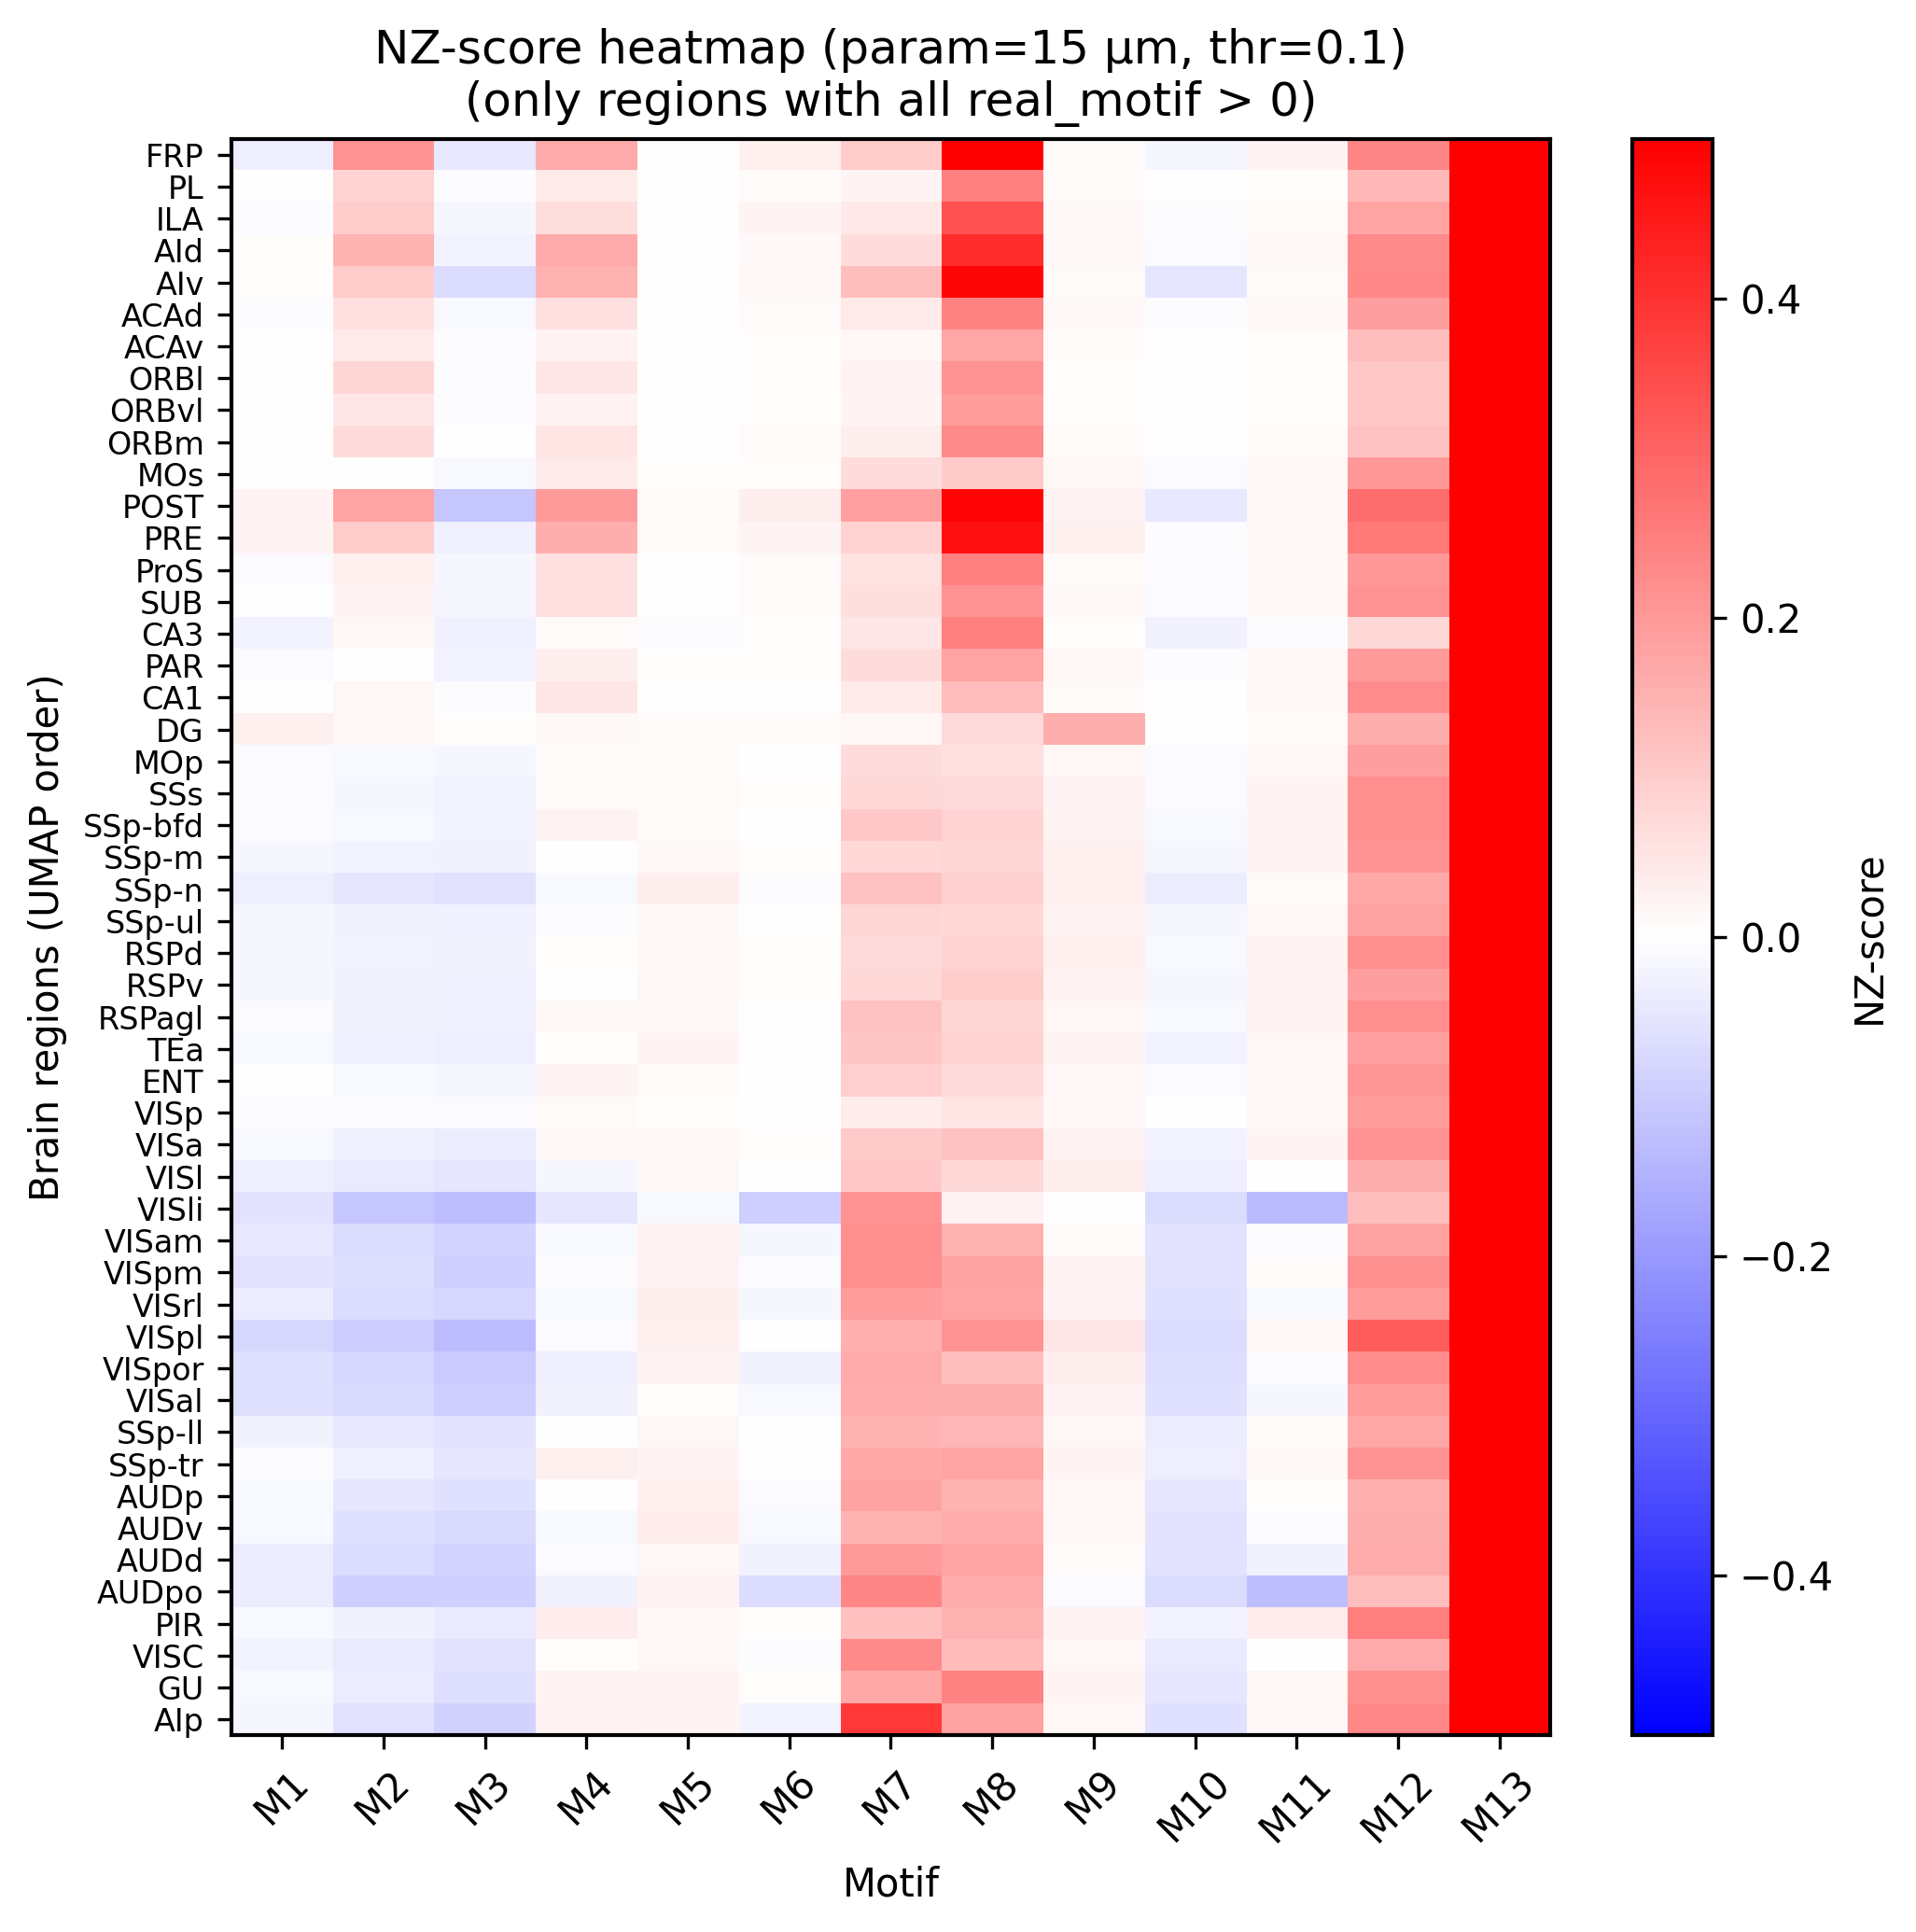

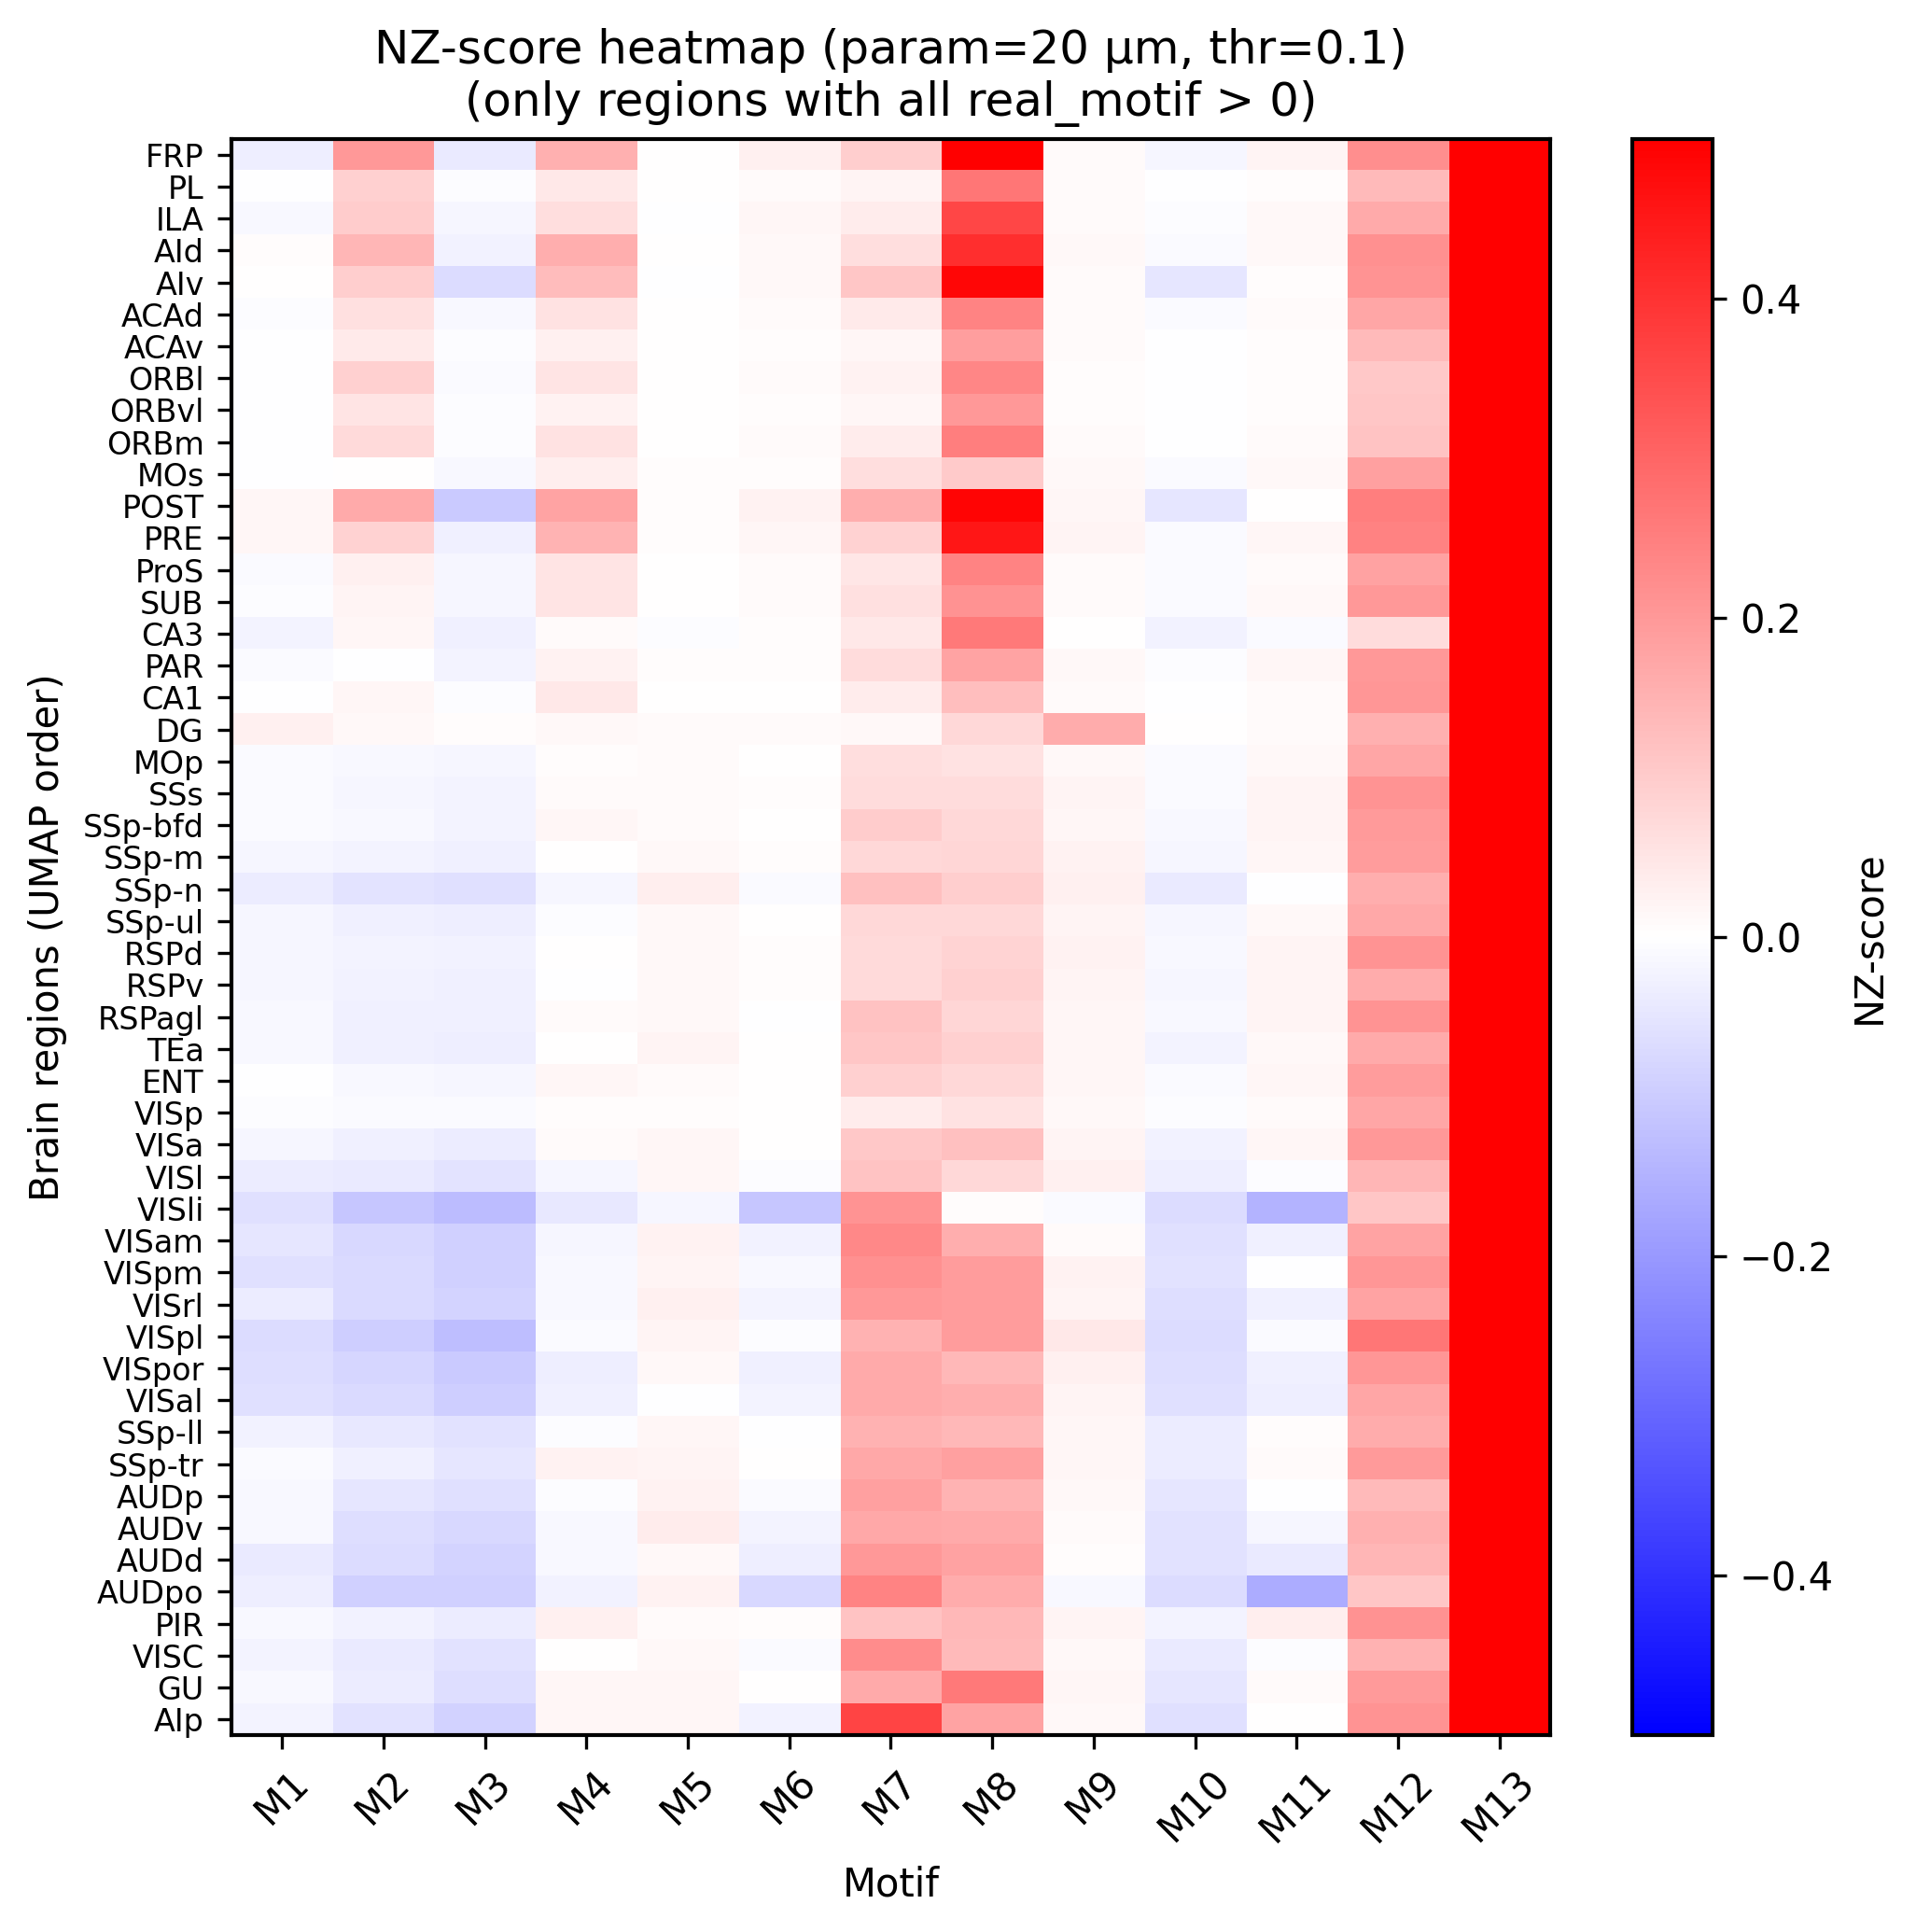

In [5]:
# ==================== 4. 每个距离阈值单独画 NZ-score 热图（按 UMAP 顺序 + 过滤 real>0） ====================

import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    results_all = pickle.load(f)["results"]   # dict[param] -> {region -> info}

param_list = [1, 3, 5, 10, 15, 20]
thr_use    = "0.1"   # 和上面聚类用的一致

for p in param_list:
    NZ_rows = []
    region_rows = []

    for r in names:   # names 是你前面按 UMAP+层次聚类排好序的脑区列表
        info = results_all[p][r]
        mr   = info["motif_results"][thr_use]

        real = np.asarray(mr["real_motif"], float)
        mu_mc = np.asarray(mr["er_mu_mc"], float)
        # 如果这个脑区在该阈值下有任何 motif 计数 <= 0，就跳过整行
        if np.any(real < 0.9) or np.any(mu_mc[:12] <= 0.):
            # print(f"[INFO] param={p} µm, region={r} 因 real_motif 包含非正值，跳过")
            continue
        
        
        nz = np.asarray(mr["NZ"], float)   # 13 维 NZ-score
        NZ_rows.append(nz)
        region_rows.append(r)

    if not NZ_rows:
        print(f"[INFO] param={p} µm 下没有满足 real_motif>0 的脑区，跳过绘图")
        continue

    NZ_mat = np.vstack(NZ_rows)

    plt.figure(figsize=(7, 7))
    im = plt.imshow(NZ_mat, aspect="auto", cmap="bwr", vmin=-0.5, vmax=0.5)

    plt.colorbar(im, label="NZ-score")
    plt.yticks(range(len(region_rows)), region_rows, fontsize=8)
    plt.xticks(range(13), [f"M{i+1}" for i in range(13)], rotation=45)

    plt.title(f"NZ-score heatmap (param={p} µm, thr={thr_use})\n"
              f"(only regions with all real_motif > 0)")
    plt.xlabel("Motif")
    plt.ylabel("Brain regions (UMAP order)")

    plt.tight_layout()
    plt.savefig(f"7.wb_motif_NZ_param_{p}um.svg",
                 bbox_inches="tight", transparent=True)
    plt.show()

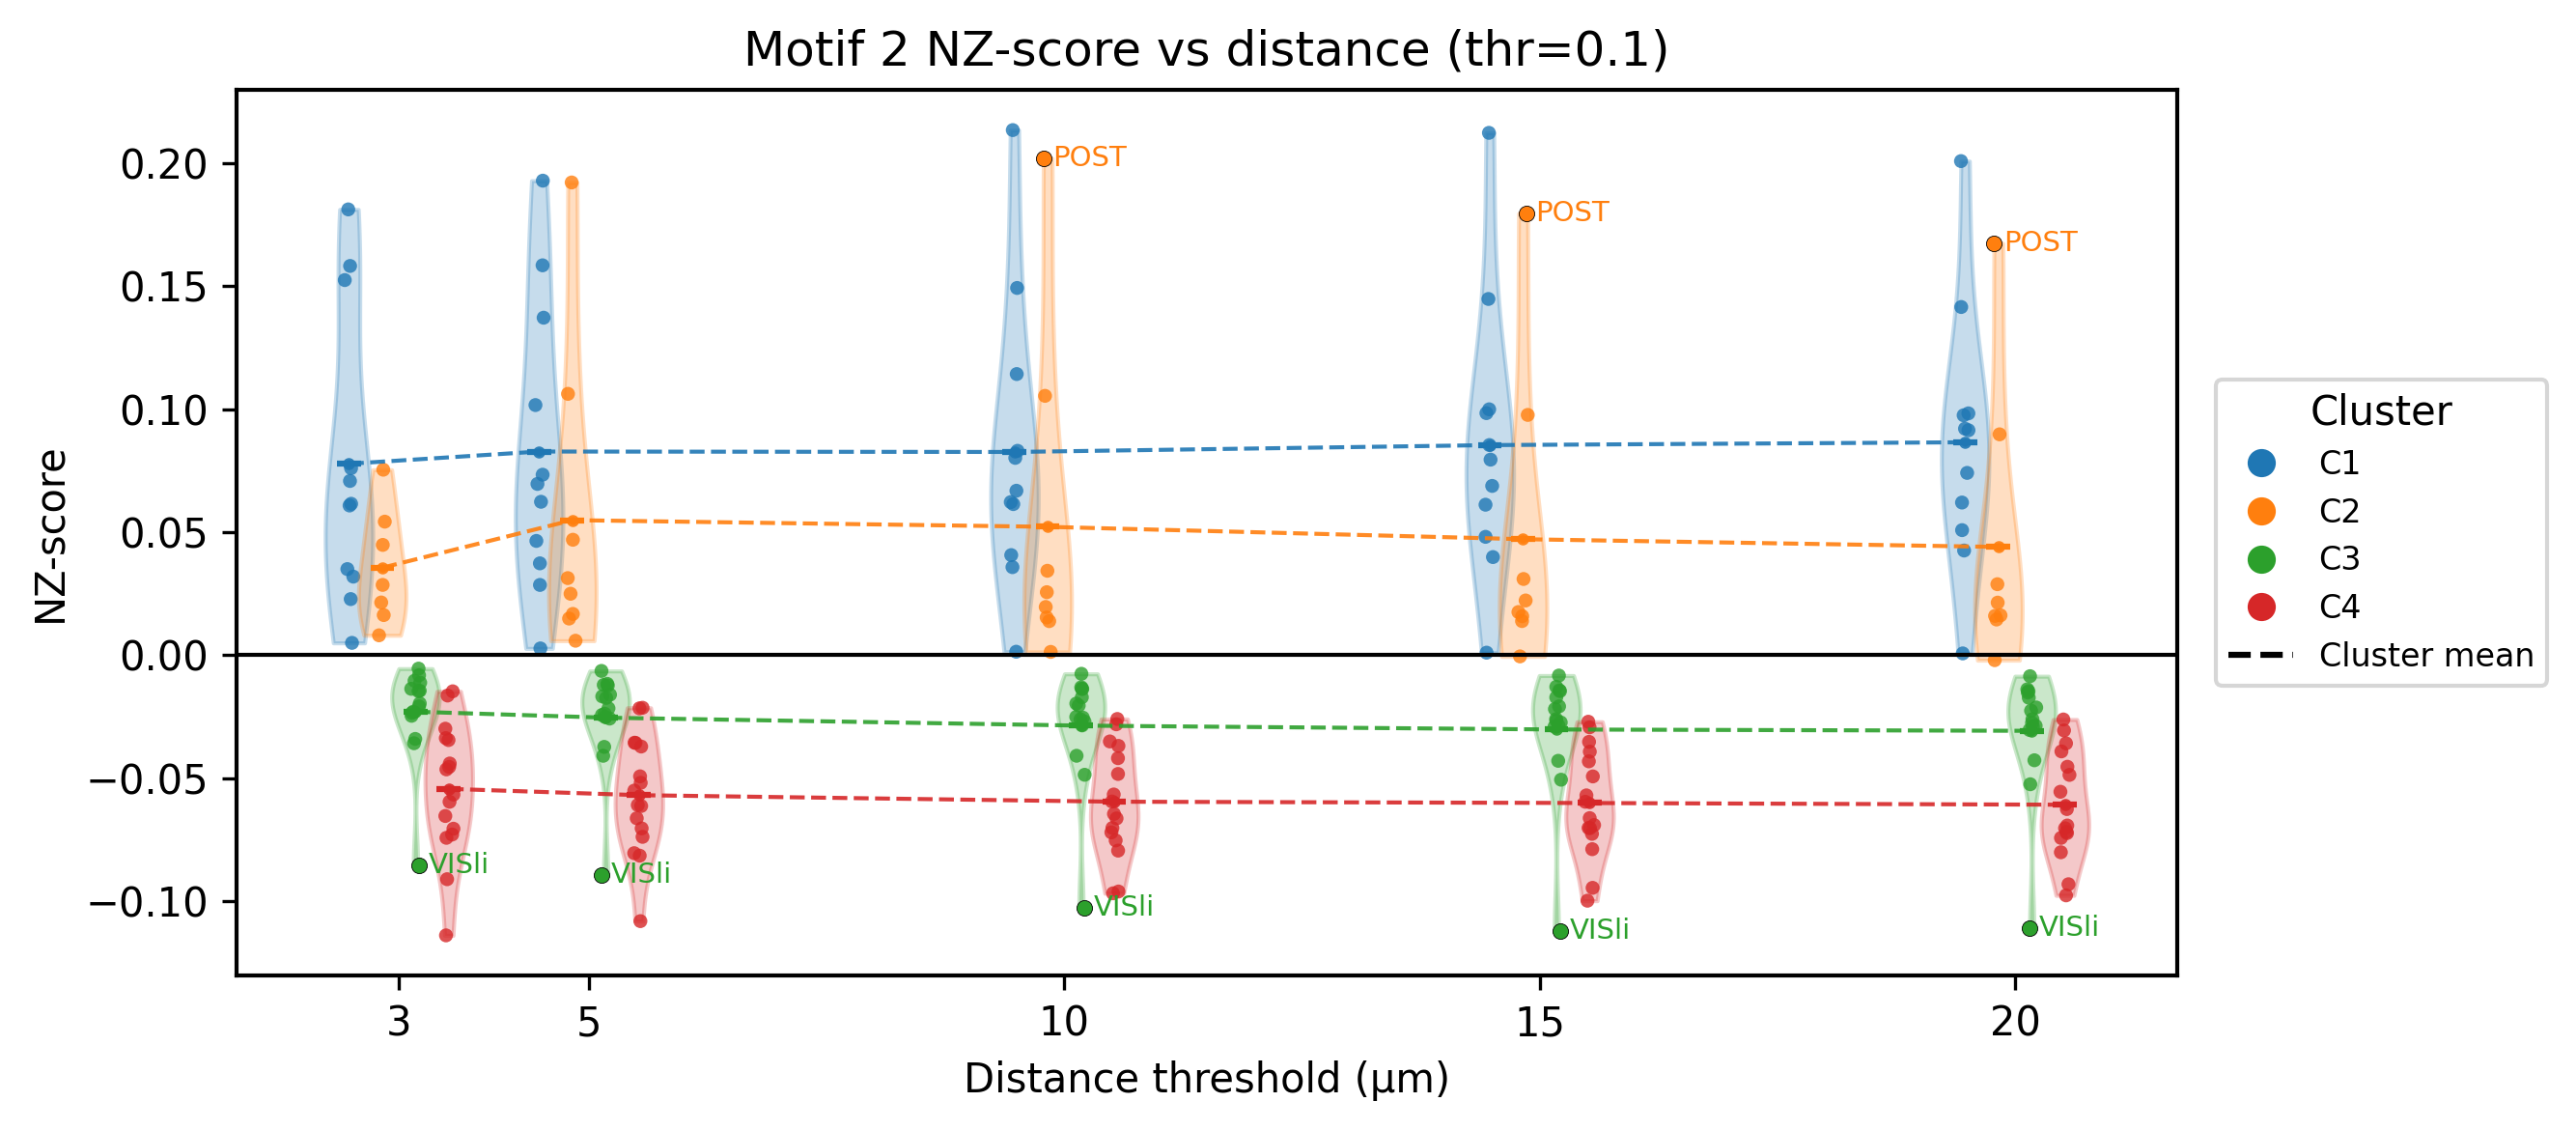

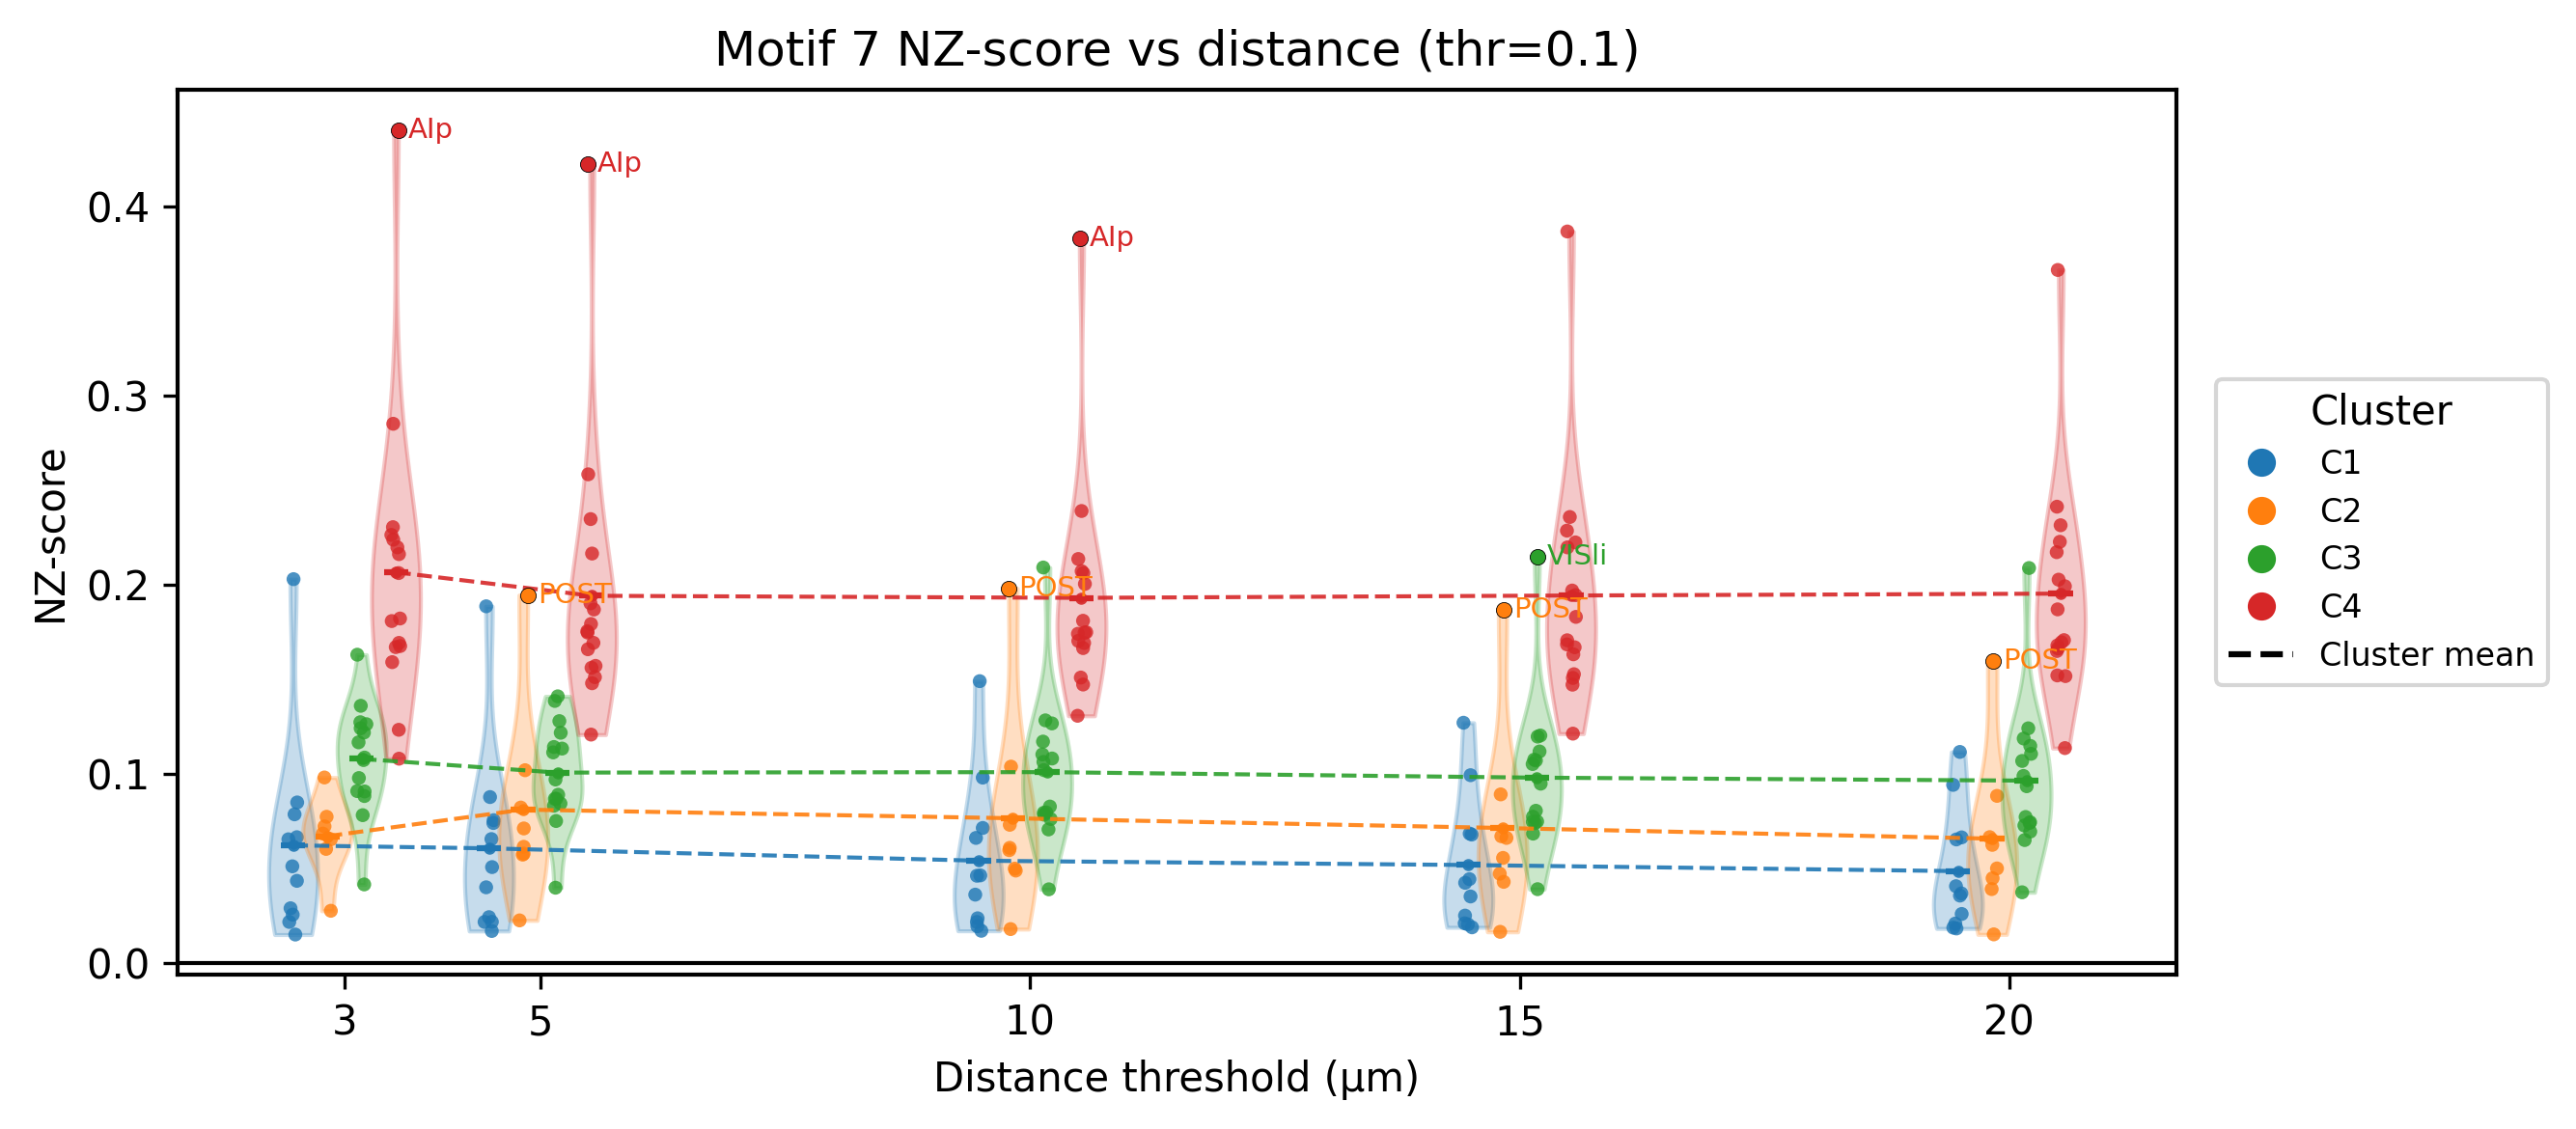

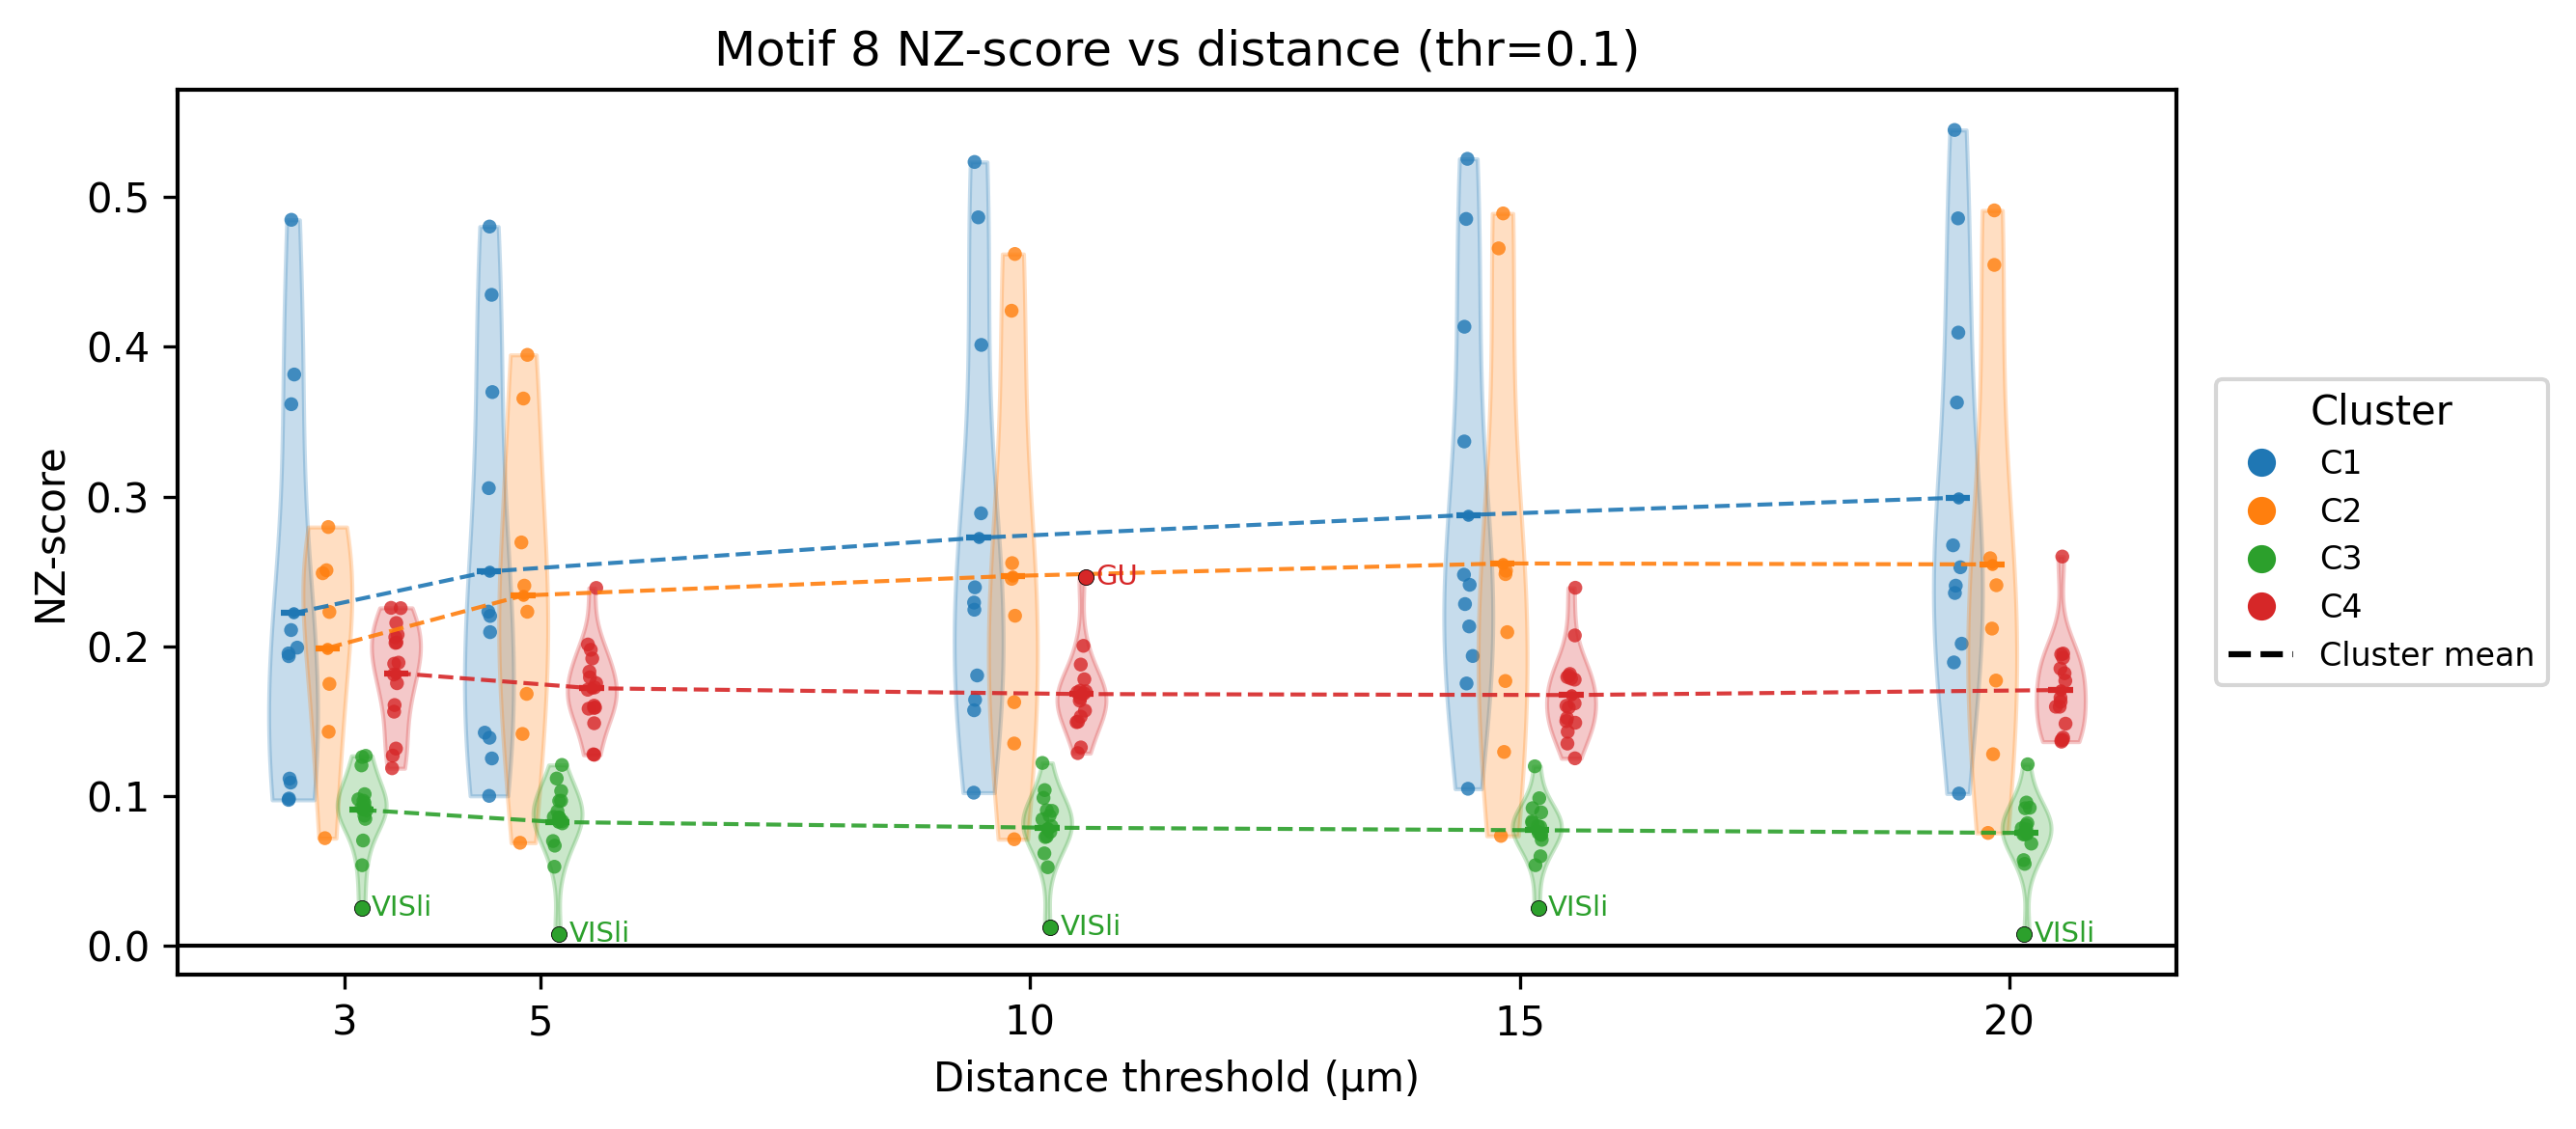

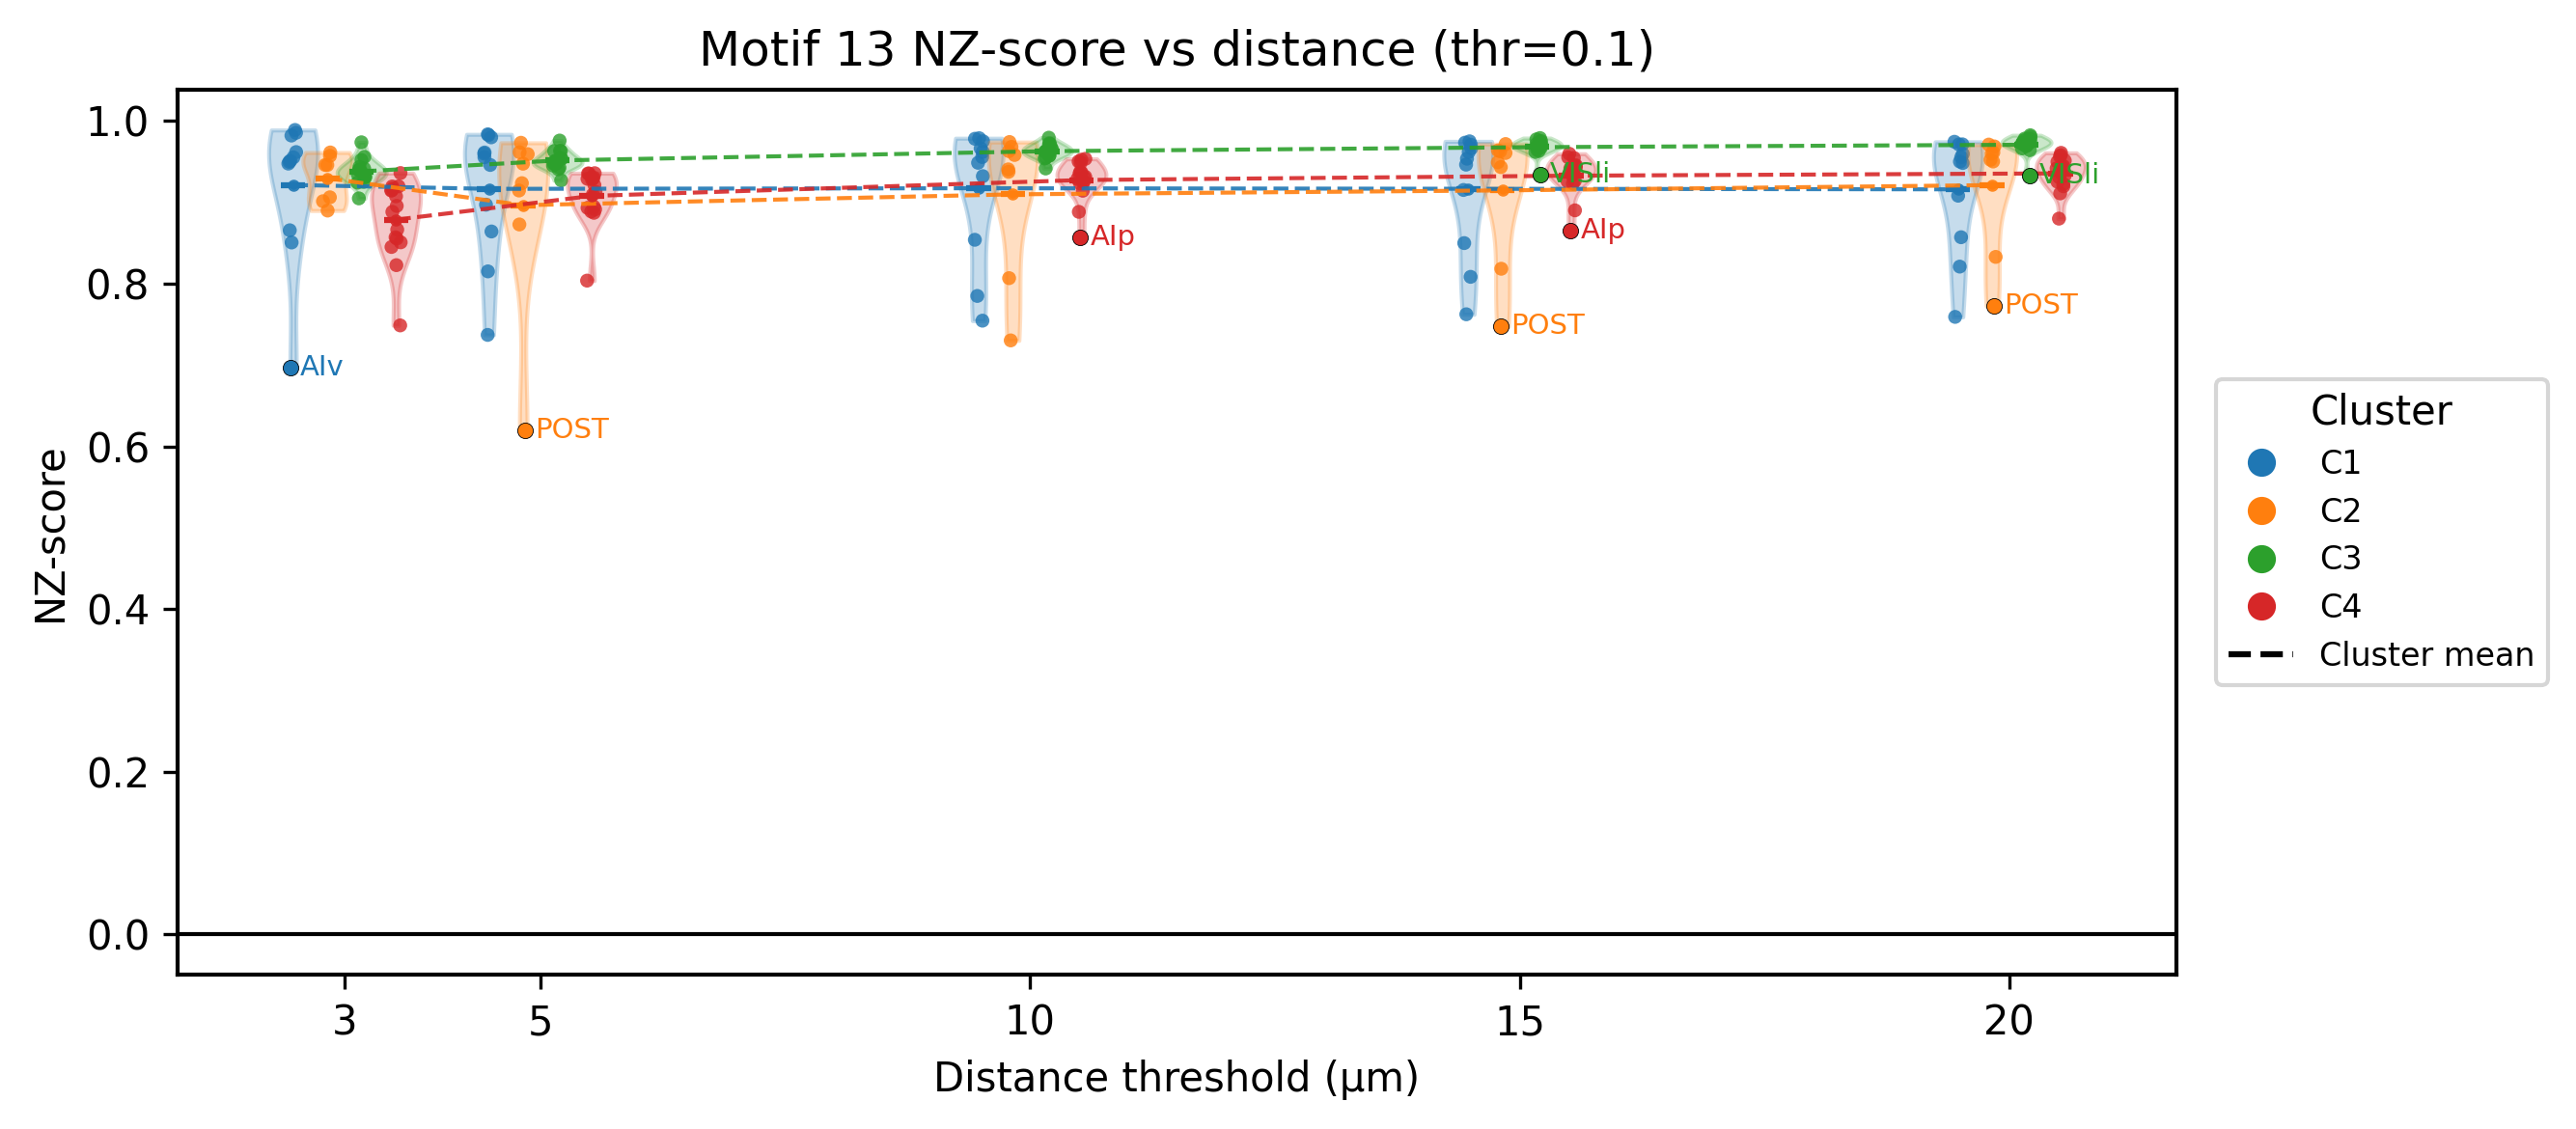

In [27]:
# ==================== 5. motif 2/7/8/13：按聚类类别随距离阈值变化的 NZ-score violin 图 + outlier 高亮 ====================

import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    results_all = pickle.load(f)["results"]

param_list  = [3, 5, 10, 15, 20]      # 距离阈值
thr_use     = "0.1"                   # 强度阈值
motif_ids   = [2, 7, 8, 13]           # 要看的 motif（1-based）
unique_cls  = np.unique(labels)
n_clust     = len(unique_cls)
cluster_col = {c: plt.cm.tab10((c - 1) % 10) for c in unique_cls}

# 预先缓存：在每个距离阈值下通过过滤的 NZ 向量
NZ_by_param = {p: {} for p in param_list}
for i, r in enumerate(names):
    for p in param_list:
        mr    = results_all[p][r]["motif_results"][thr_use]
        real  = np.asarray(mr["real_motif"], float)
        mu_mc = np.asarray(mr["er_mu_mc"], float)
        if np.any(real < 0.9) or np.any(mu_mc[:12] <= 0.0):
            continue
        NZ_by_param[p][i] = np.asarray(mr["NZ"], float)

for m_id in motif_ids:
    j   = m_id - 1
    fig, ax = plt.subplots(figsize=(9, 4))
    width   = 0.35

    mean_x = {c: [] for c in unique_cls}
    mean_y = {c: [] for c in unique_cls}

    for ci, c in enumerate(unique_cls):
        offset         = (ci - (n_clust - 1) / 2) * width
        data_list      = []
        pos_list       = []
        names_by_group = []

        for p in param_list:
            idx_i = [i for i in range(len(names)) if labels[i] == c and i in NZ_by_param[p]]
            if not idx_i:
                continue
            vals         = np.array([NZ_by_param[p][i][j] for i in idx_i])
            region_group = [names[i] for i in idx_i]
            x_center     = p + offset

            data_list.append(vals)
            pos_list.append(x_center)
            names_by_group.append(region_group)
            mean_x[c].append(x_center)
            mean_y[c].append(vals.mean())

        if not data_list:
            continue

        parts = ax.violinplot(data_list, positions=pos_list,
                              showmeans=True, showextrema=False, showmedians=False)
        for body in parts["bodies"]:
            body.set_facecolor(cluster_col[c]); body.set_edgecolor(cluster_col[c]); body.set_alpha(0.25)

        for x0, vals, regs in zip(pos_list, data_list, names_by_group):
            q1, q3  = np.percentile(vals, [25, 75])
            iqr     = q3 - q1
            lower   = q1 - 3 * iqr
            upper   = q3 + 3 * iqr
            is_out  = (vals < lower) | (vals > upper)
            jitter  = (np.random.rand(len(vals)) - 0.5) * 0.1
            x_base  = np.full(len(vals), x0) + jitter

            ax.scatter(x_base[~is_out], vals[~is_out], s=12, alpha=0.8,
                       color=cluster_col[c], edgecolors="none")

            ax.scatter(x_base[is_out], vals[is_out], s=15, alpha=1.0,
                       facecolors=cluster_col[c], edgecolors="black",
                       linewidths=0.2, zorder=5)

            for xo, yo, name_out in zip(x_base[is_out], vals[is_out], np.array(regs)[is_out]):
                ax.text(xo + 0.1, yo, name_out, fontsize=7,
                        va="center", ha="left", color=cluster_col[c])

    for c in unique_cls:
        xs = np.array(mean_x[c]); ys = np.array(mean_y[c])
        if len(xs) == 0:
            continue
        idx = np.argsort(xs)
        ax.plot(xs[idx], ys[idx], color=cluster_col[c], linewidth=1,
                alpha=0.9, linestyle="--", marker="o", markersize=2,
                label=f"C{int(c)} mean" if m_id == motif_ids[0] else None)

    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("Distance threshold (µm)")
    ax.set_ylabel("NZ-score")
    ax.set_title(f"Motif {m_id} NZ-score vs distance (thr={thr_use})")
    ax.set_xticks(param_list); ax.set_xticklabels([str(p) for p in param_list])

    handles = [plt.Line2D([0], [0], marker="o", linestyle="",
                           color=cluster_col[c], label=f"C{int(c)}")
               for c in unique_cls]
    handles += [plt.Line2D([0], [0], color="k", linestyle="--", label="Cluster mean")]

    ax.legend(handles=handles, title="Cluster", fontsize=8,
              loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    plt.tight_layout()
    plt.savefig(f"7.motif{m_id}_NZ_vs_param.svg",
                 bbox_inches="tight", transparent=True)
    plt.show()

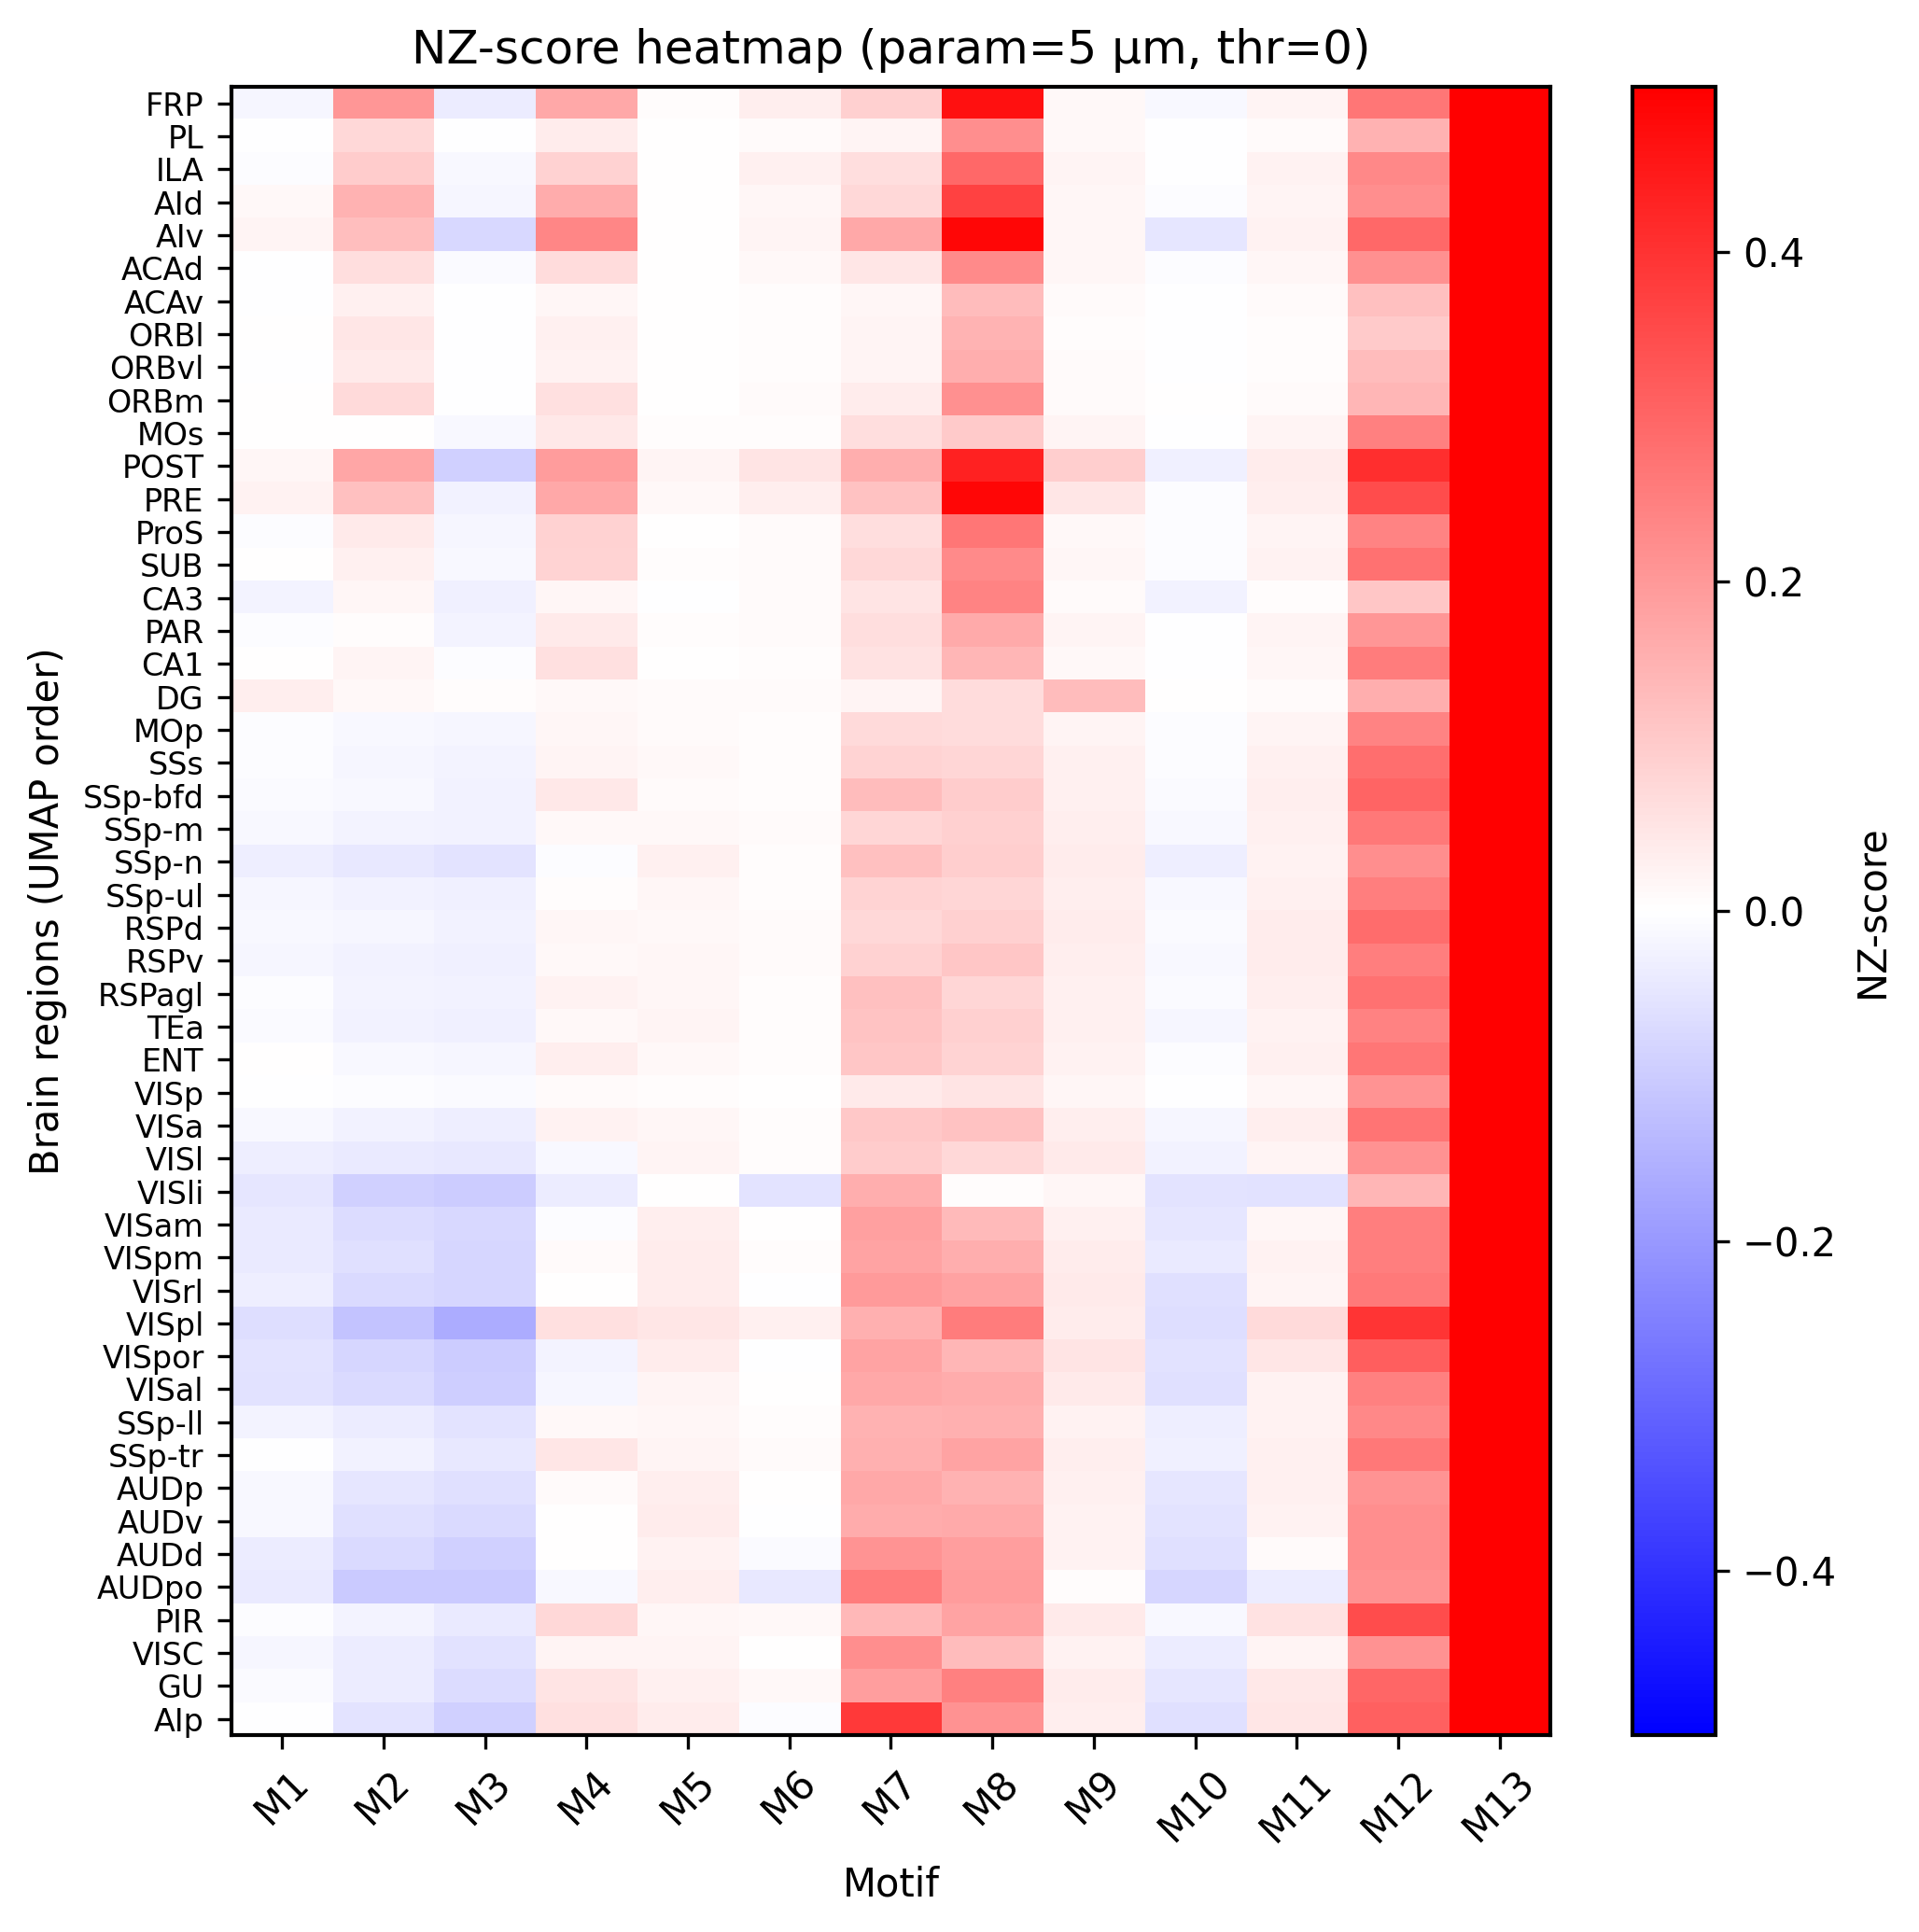

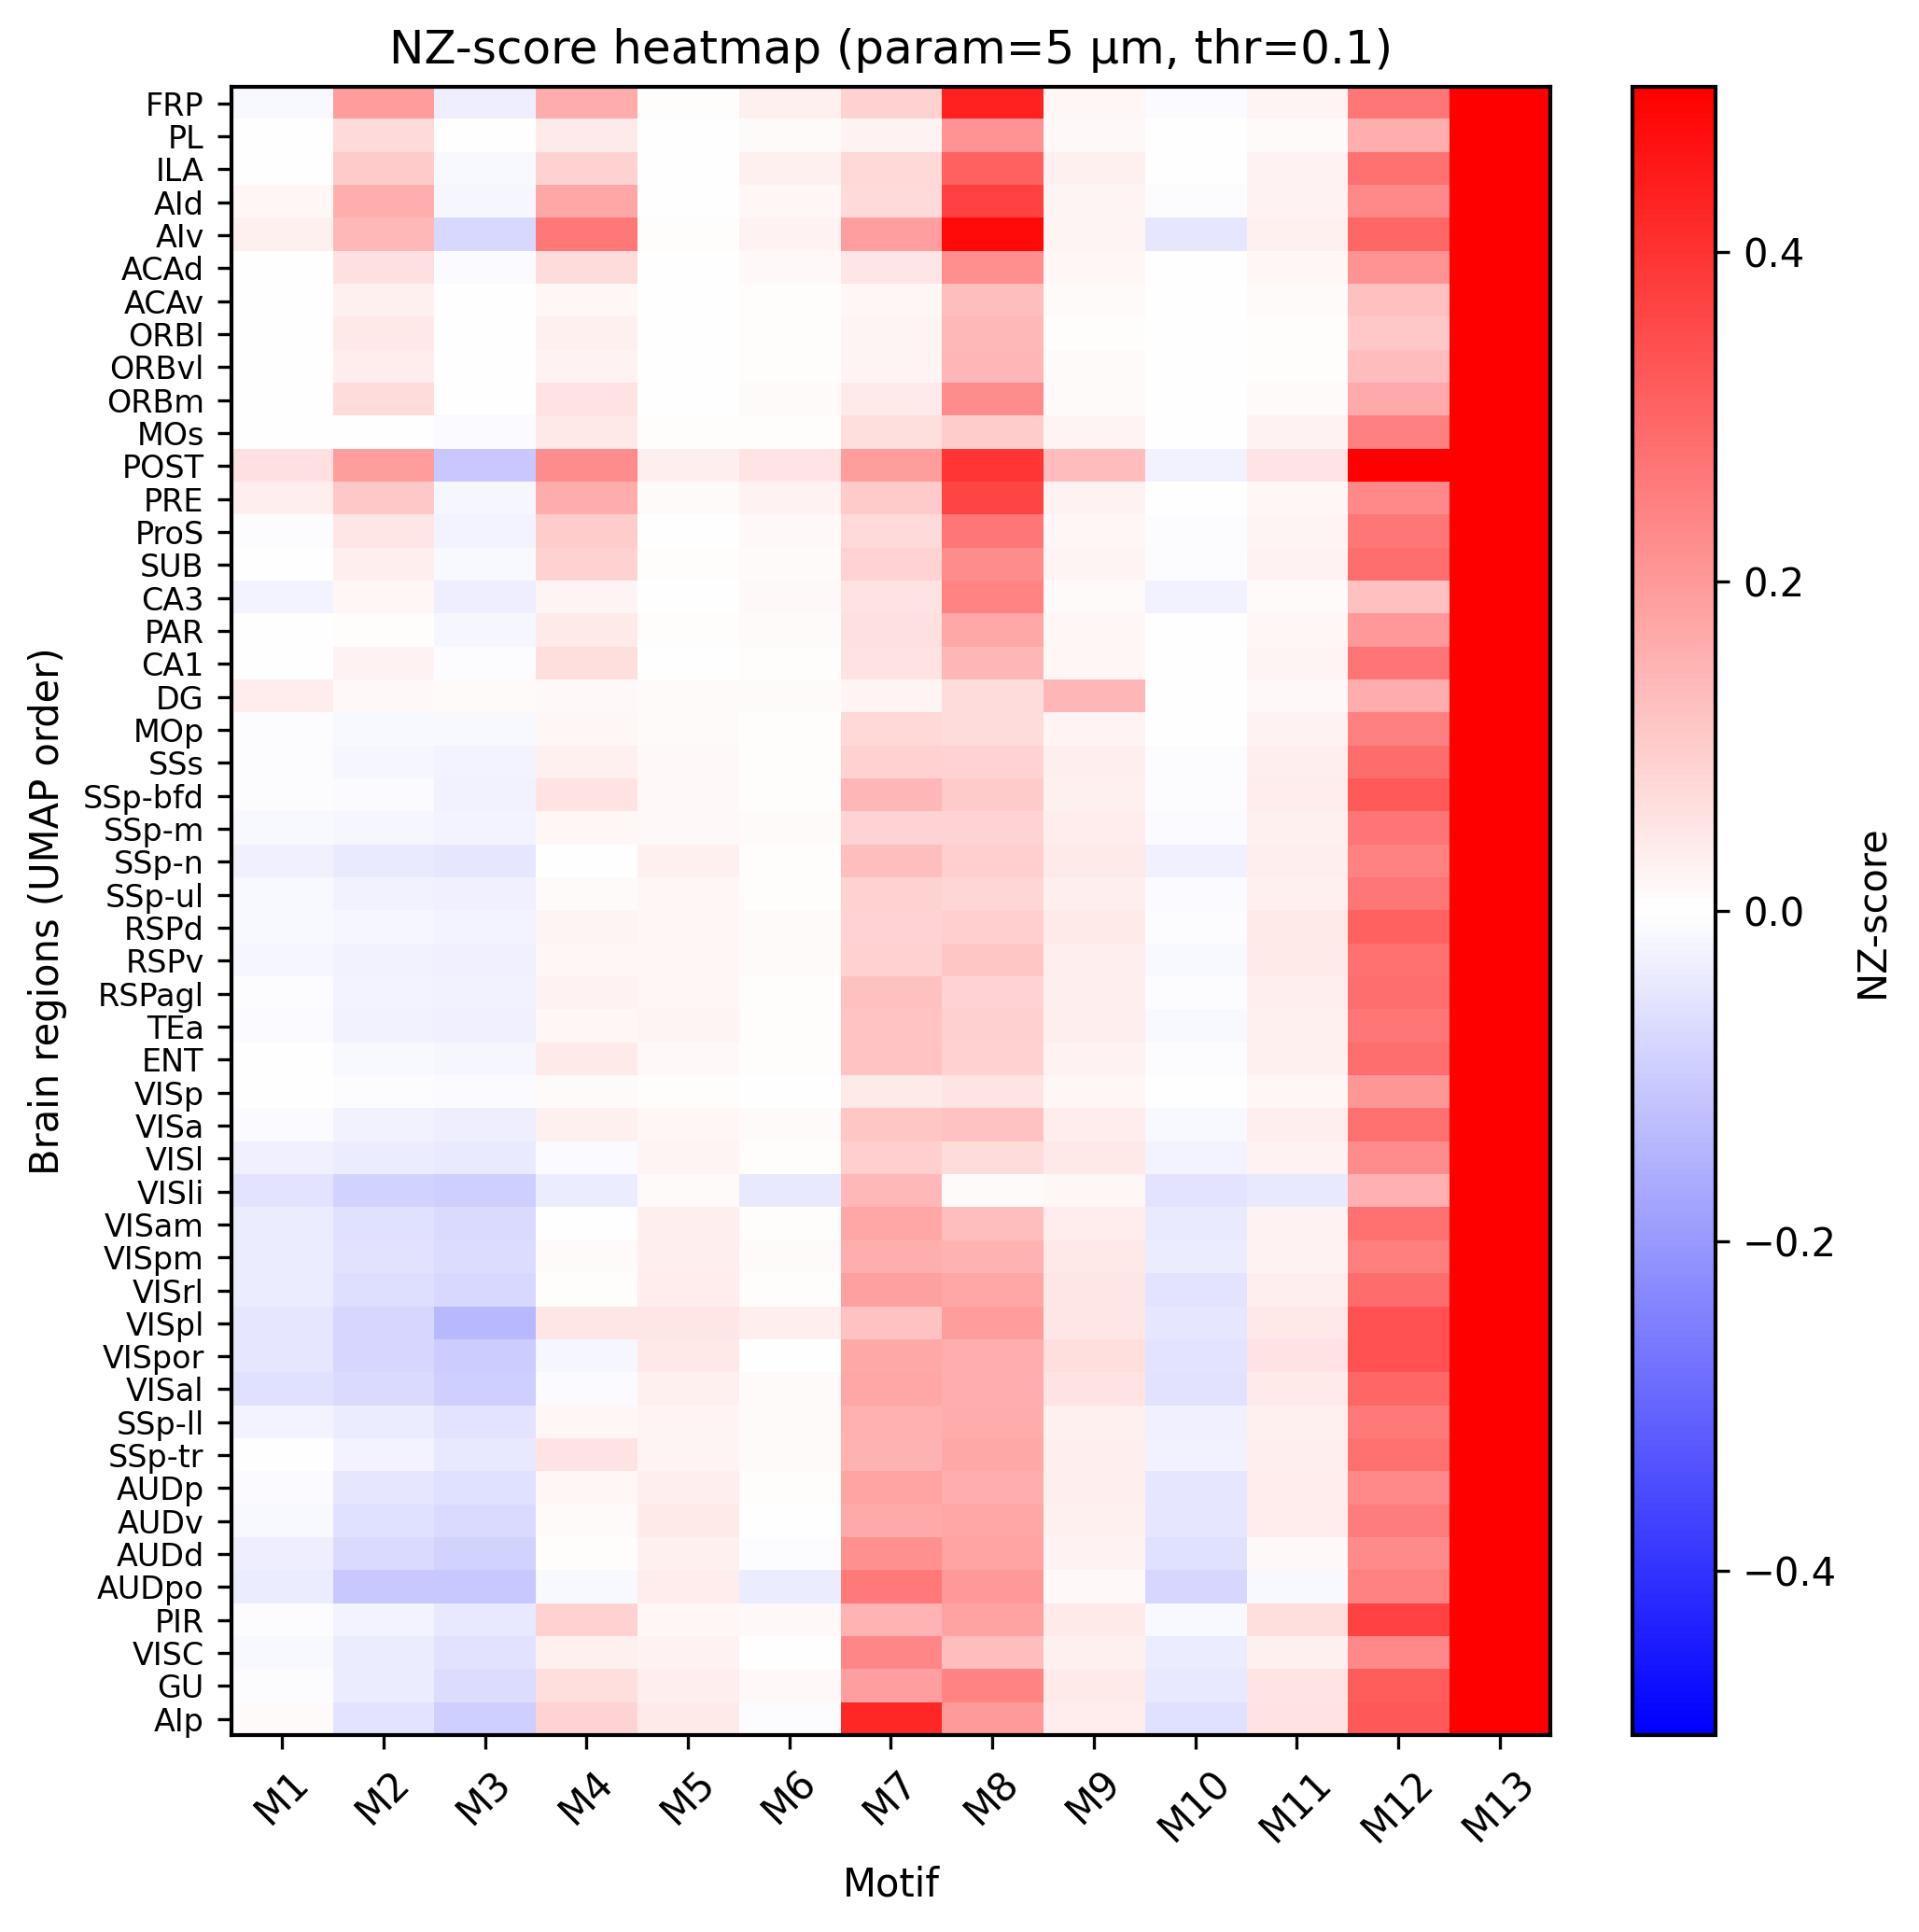

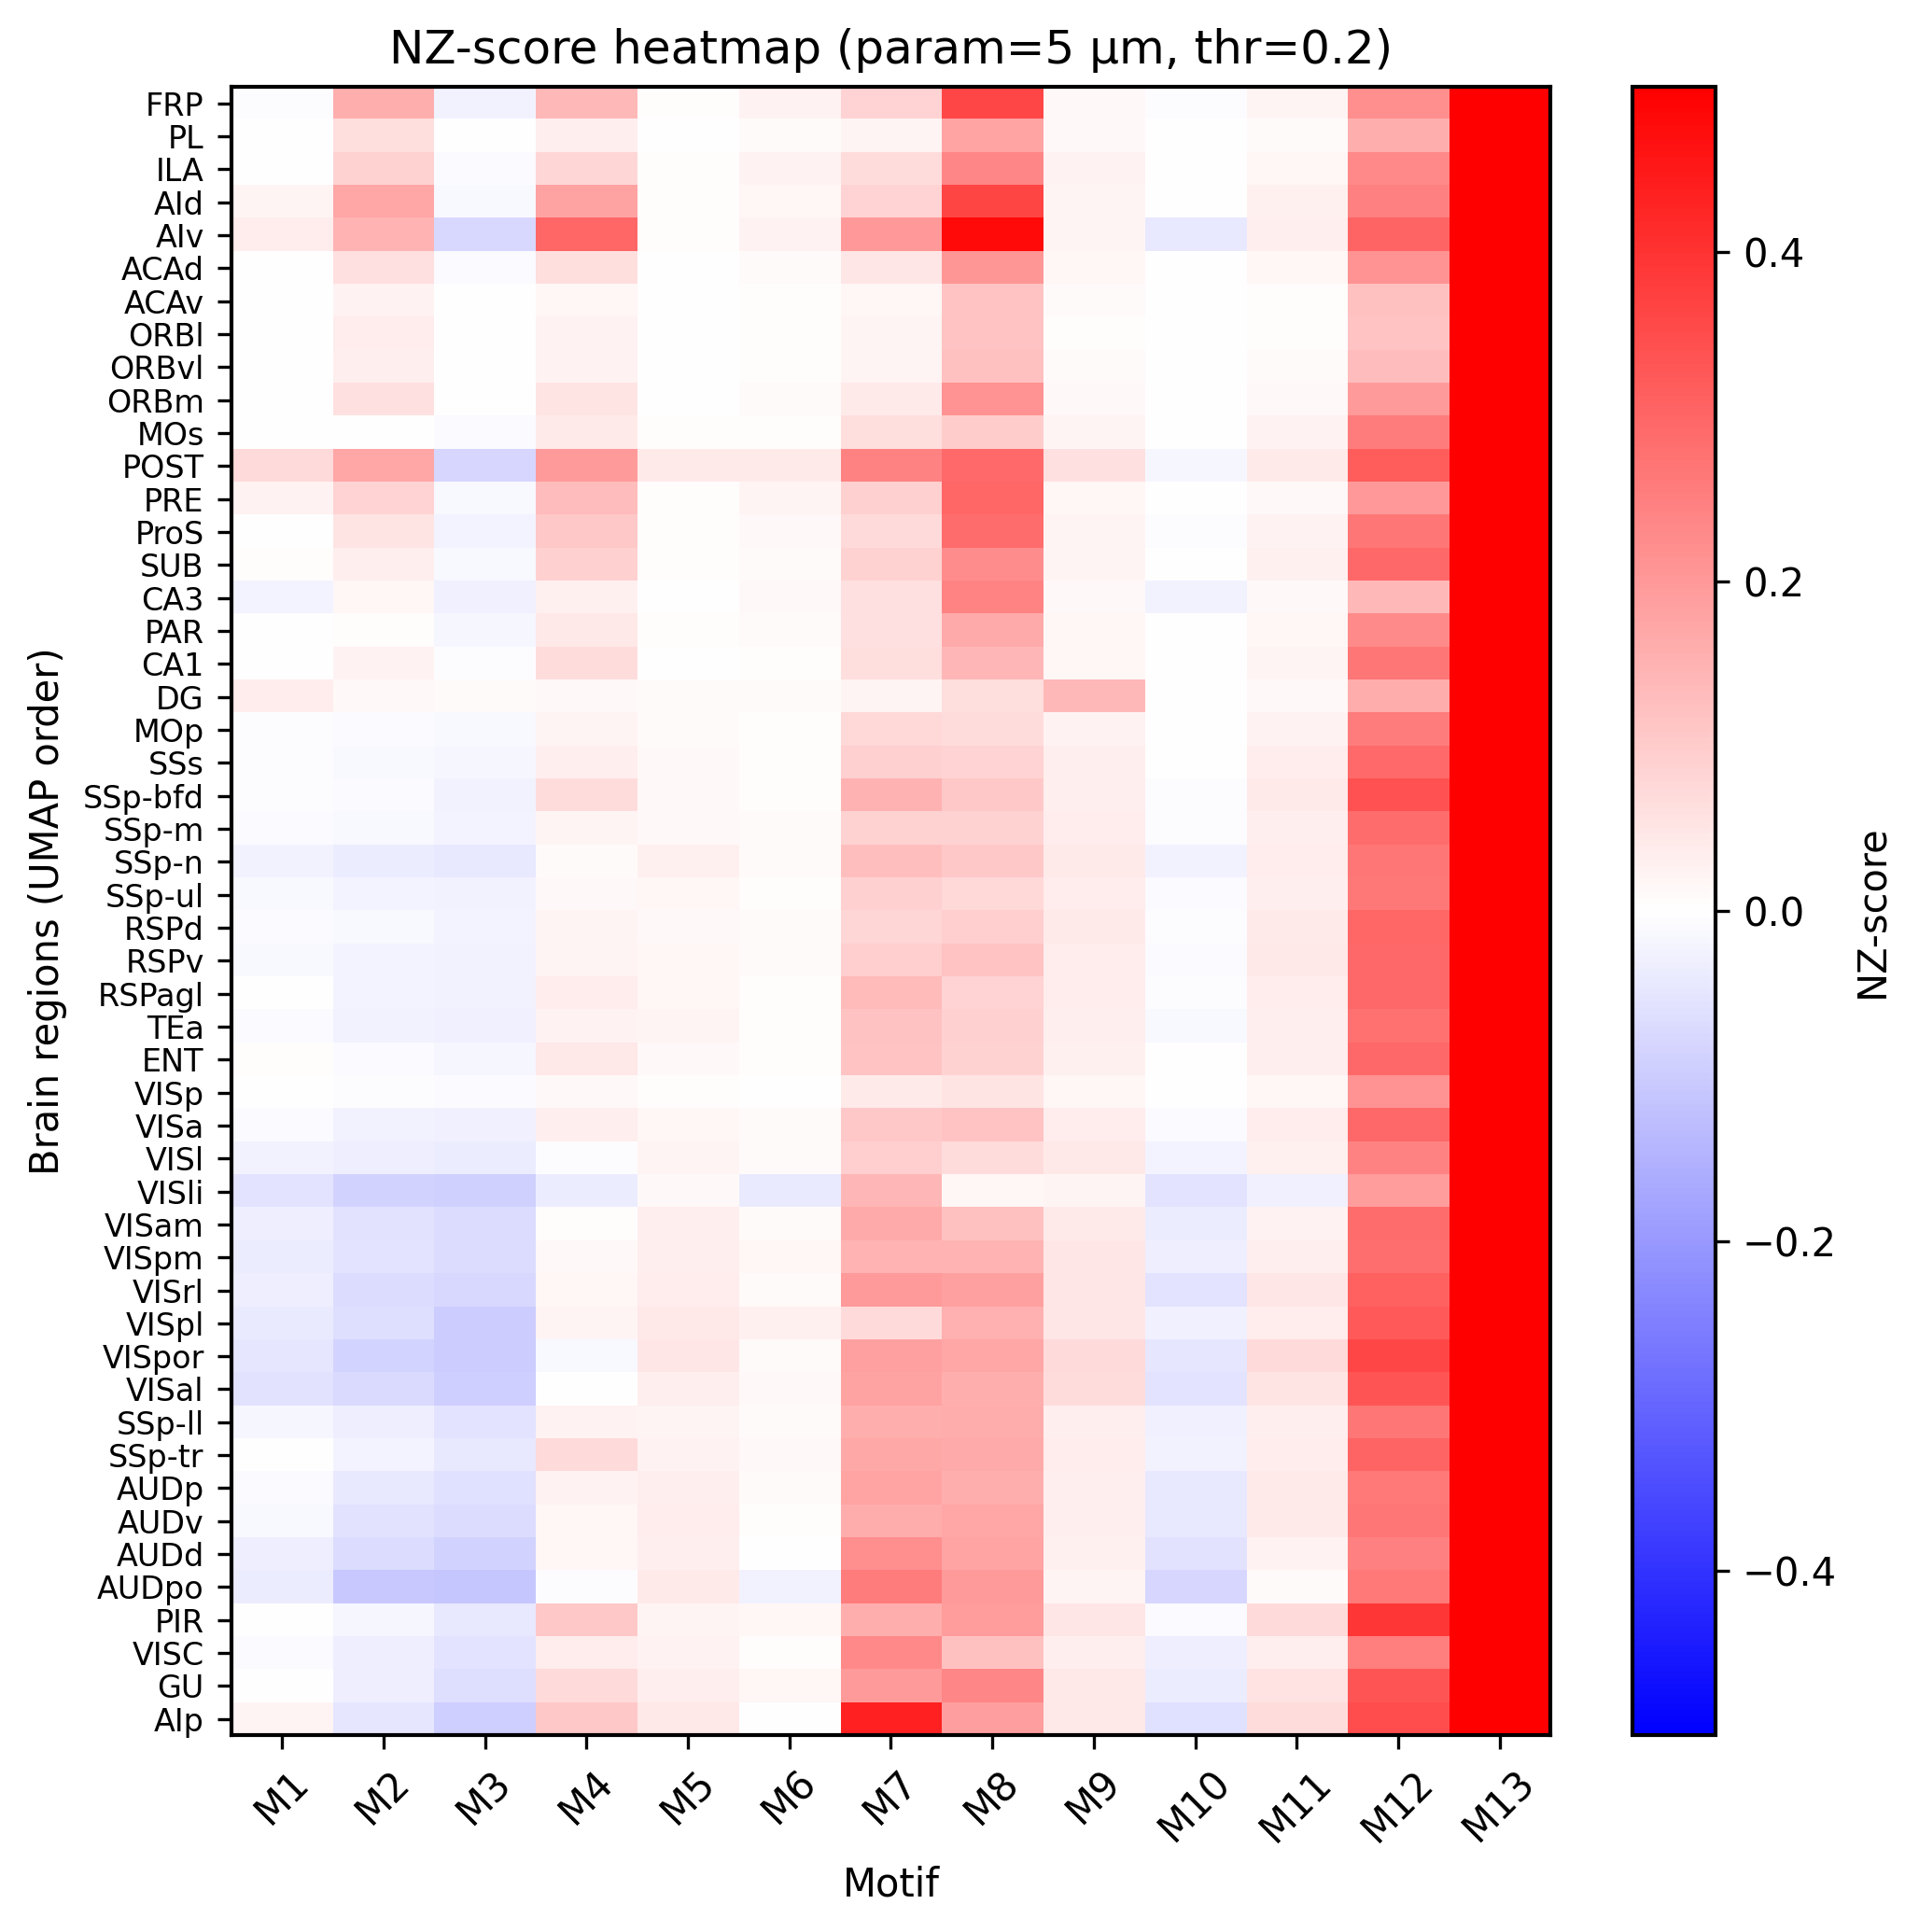

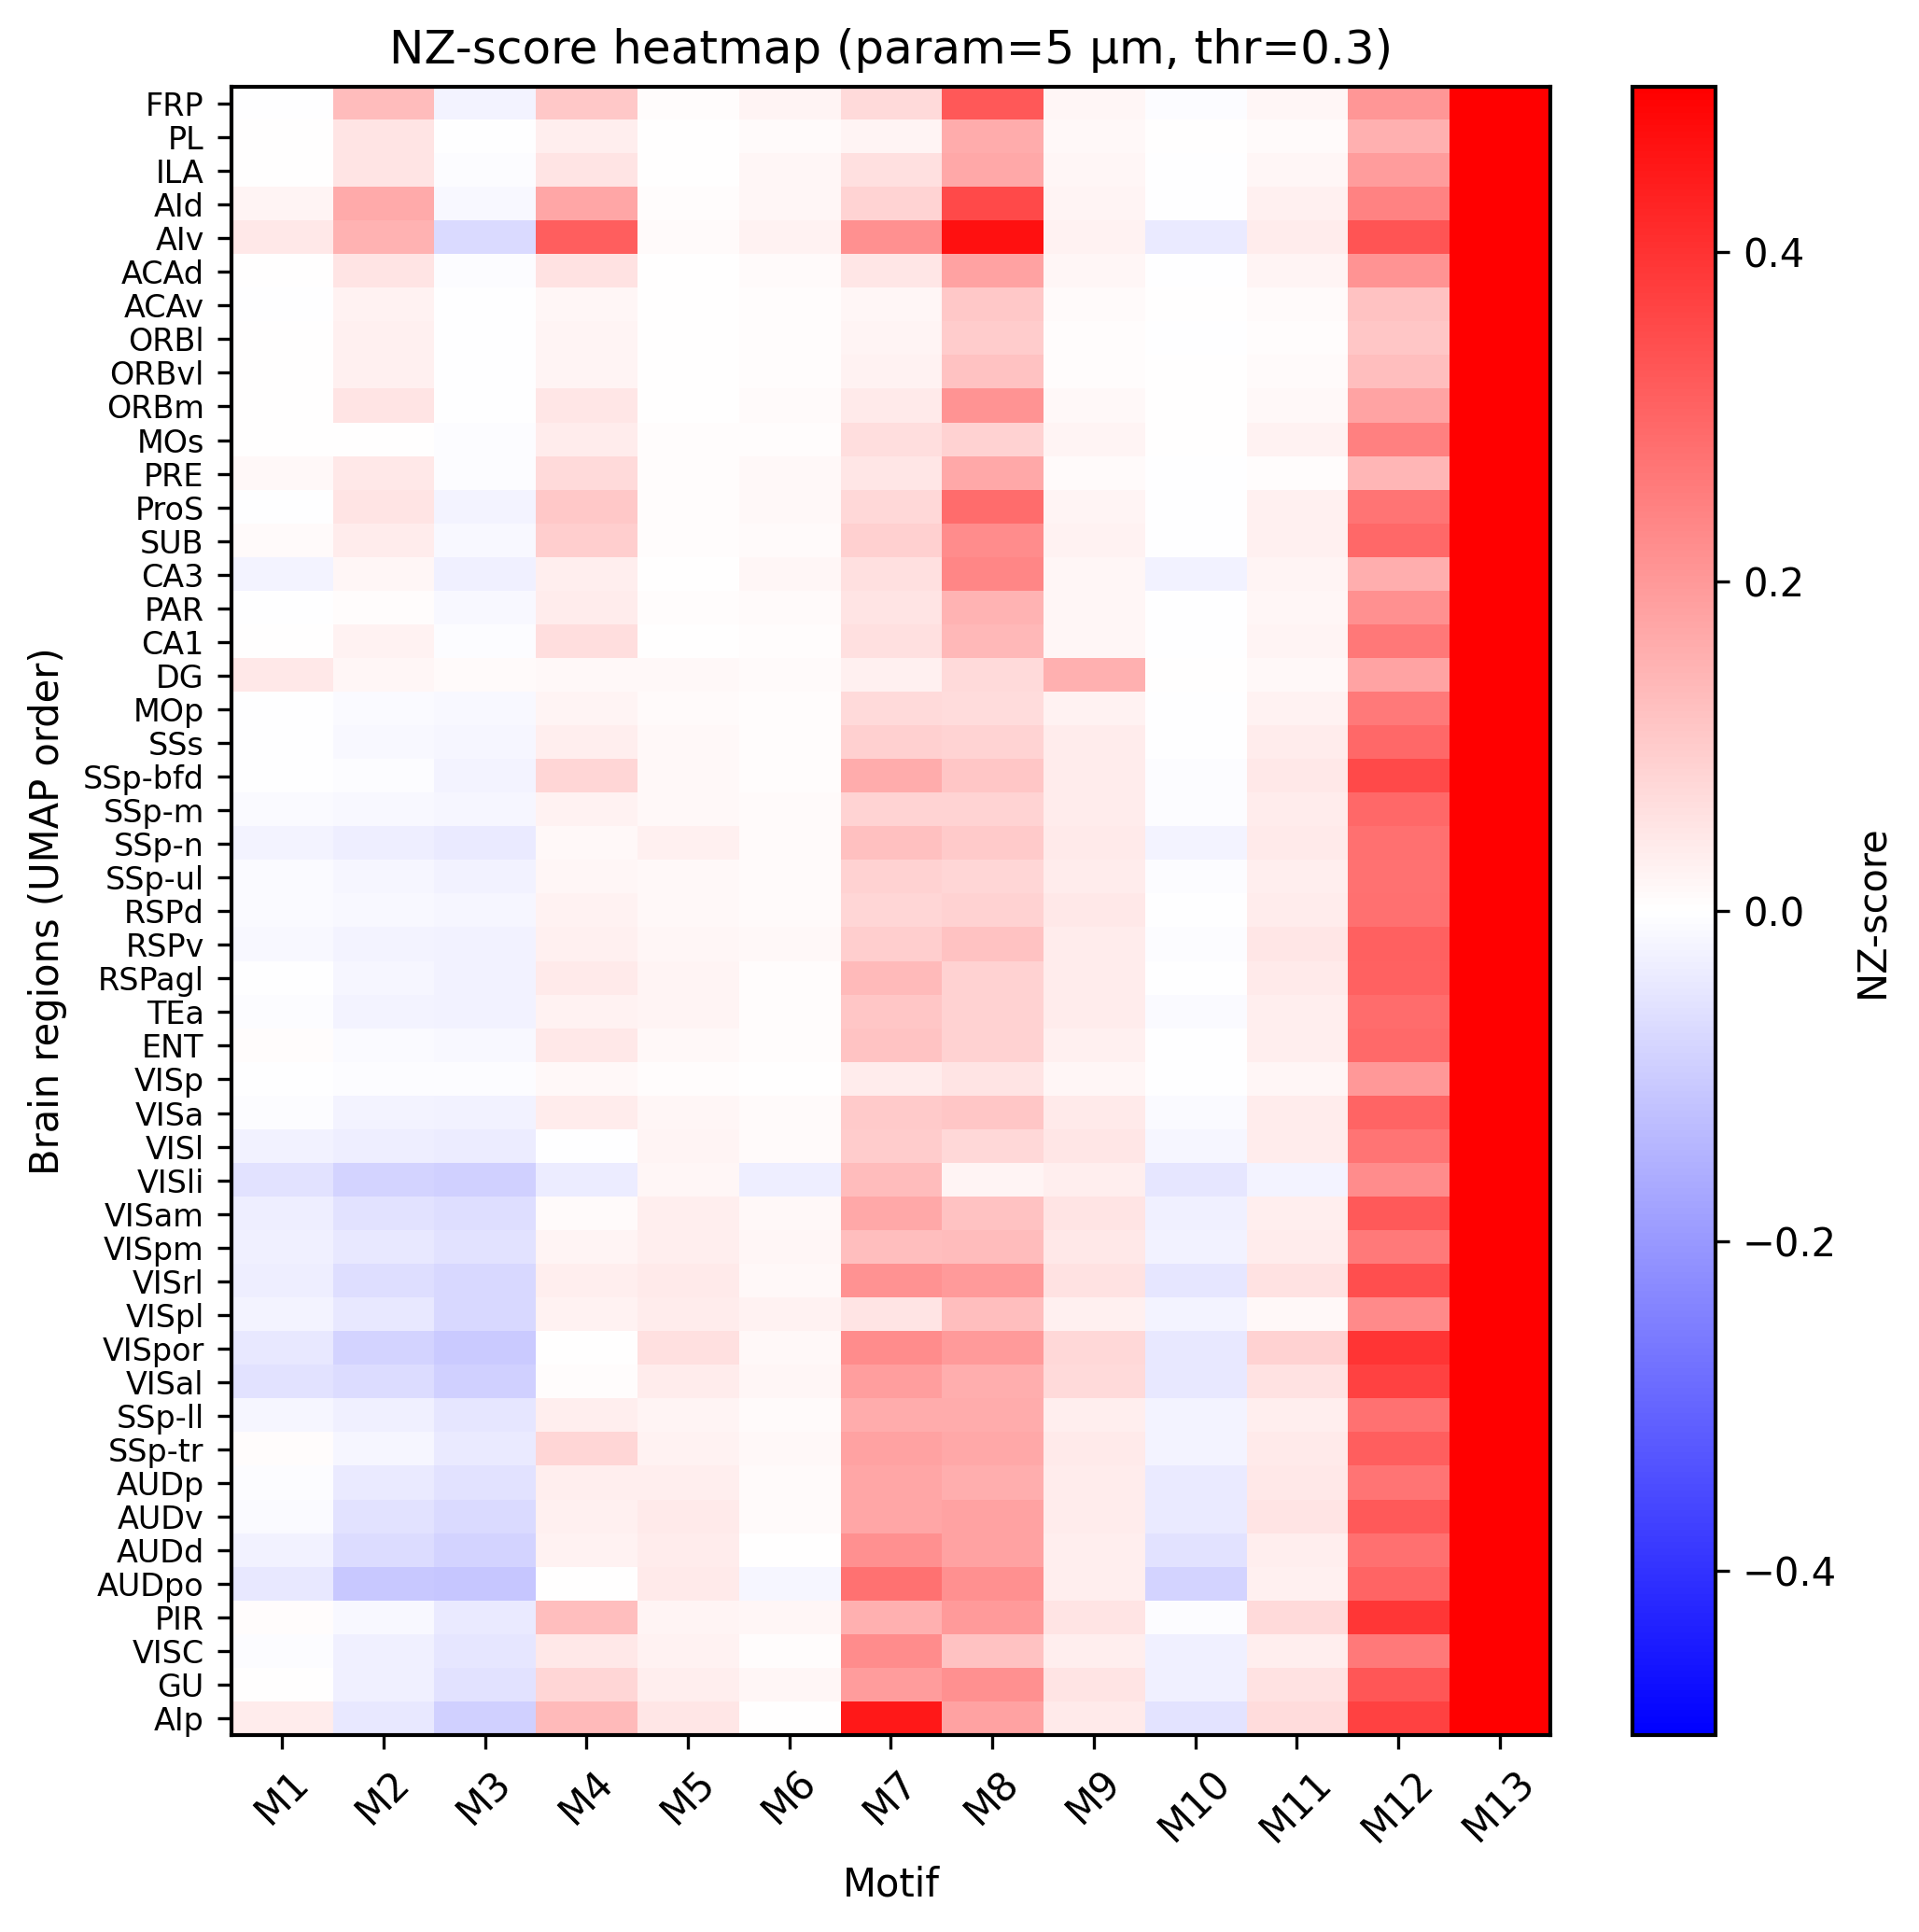

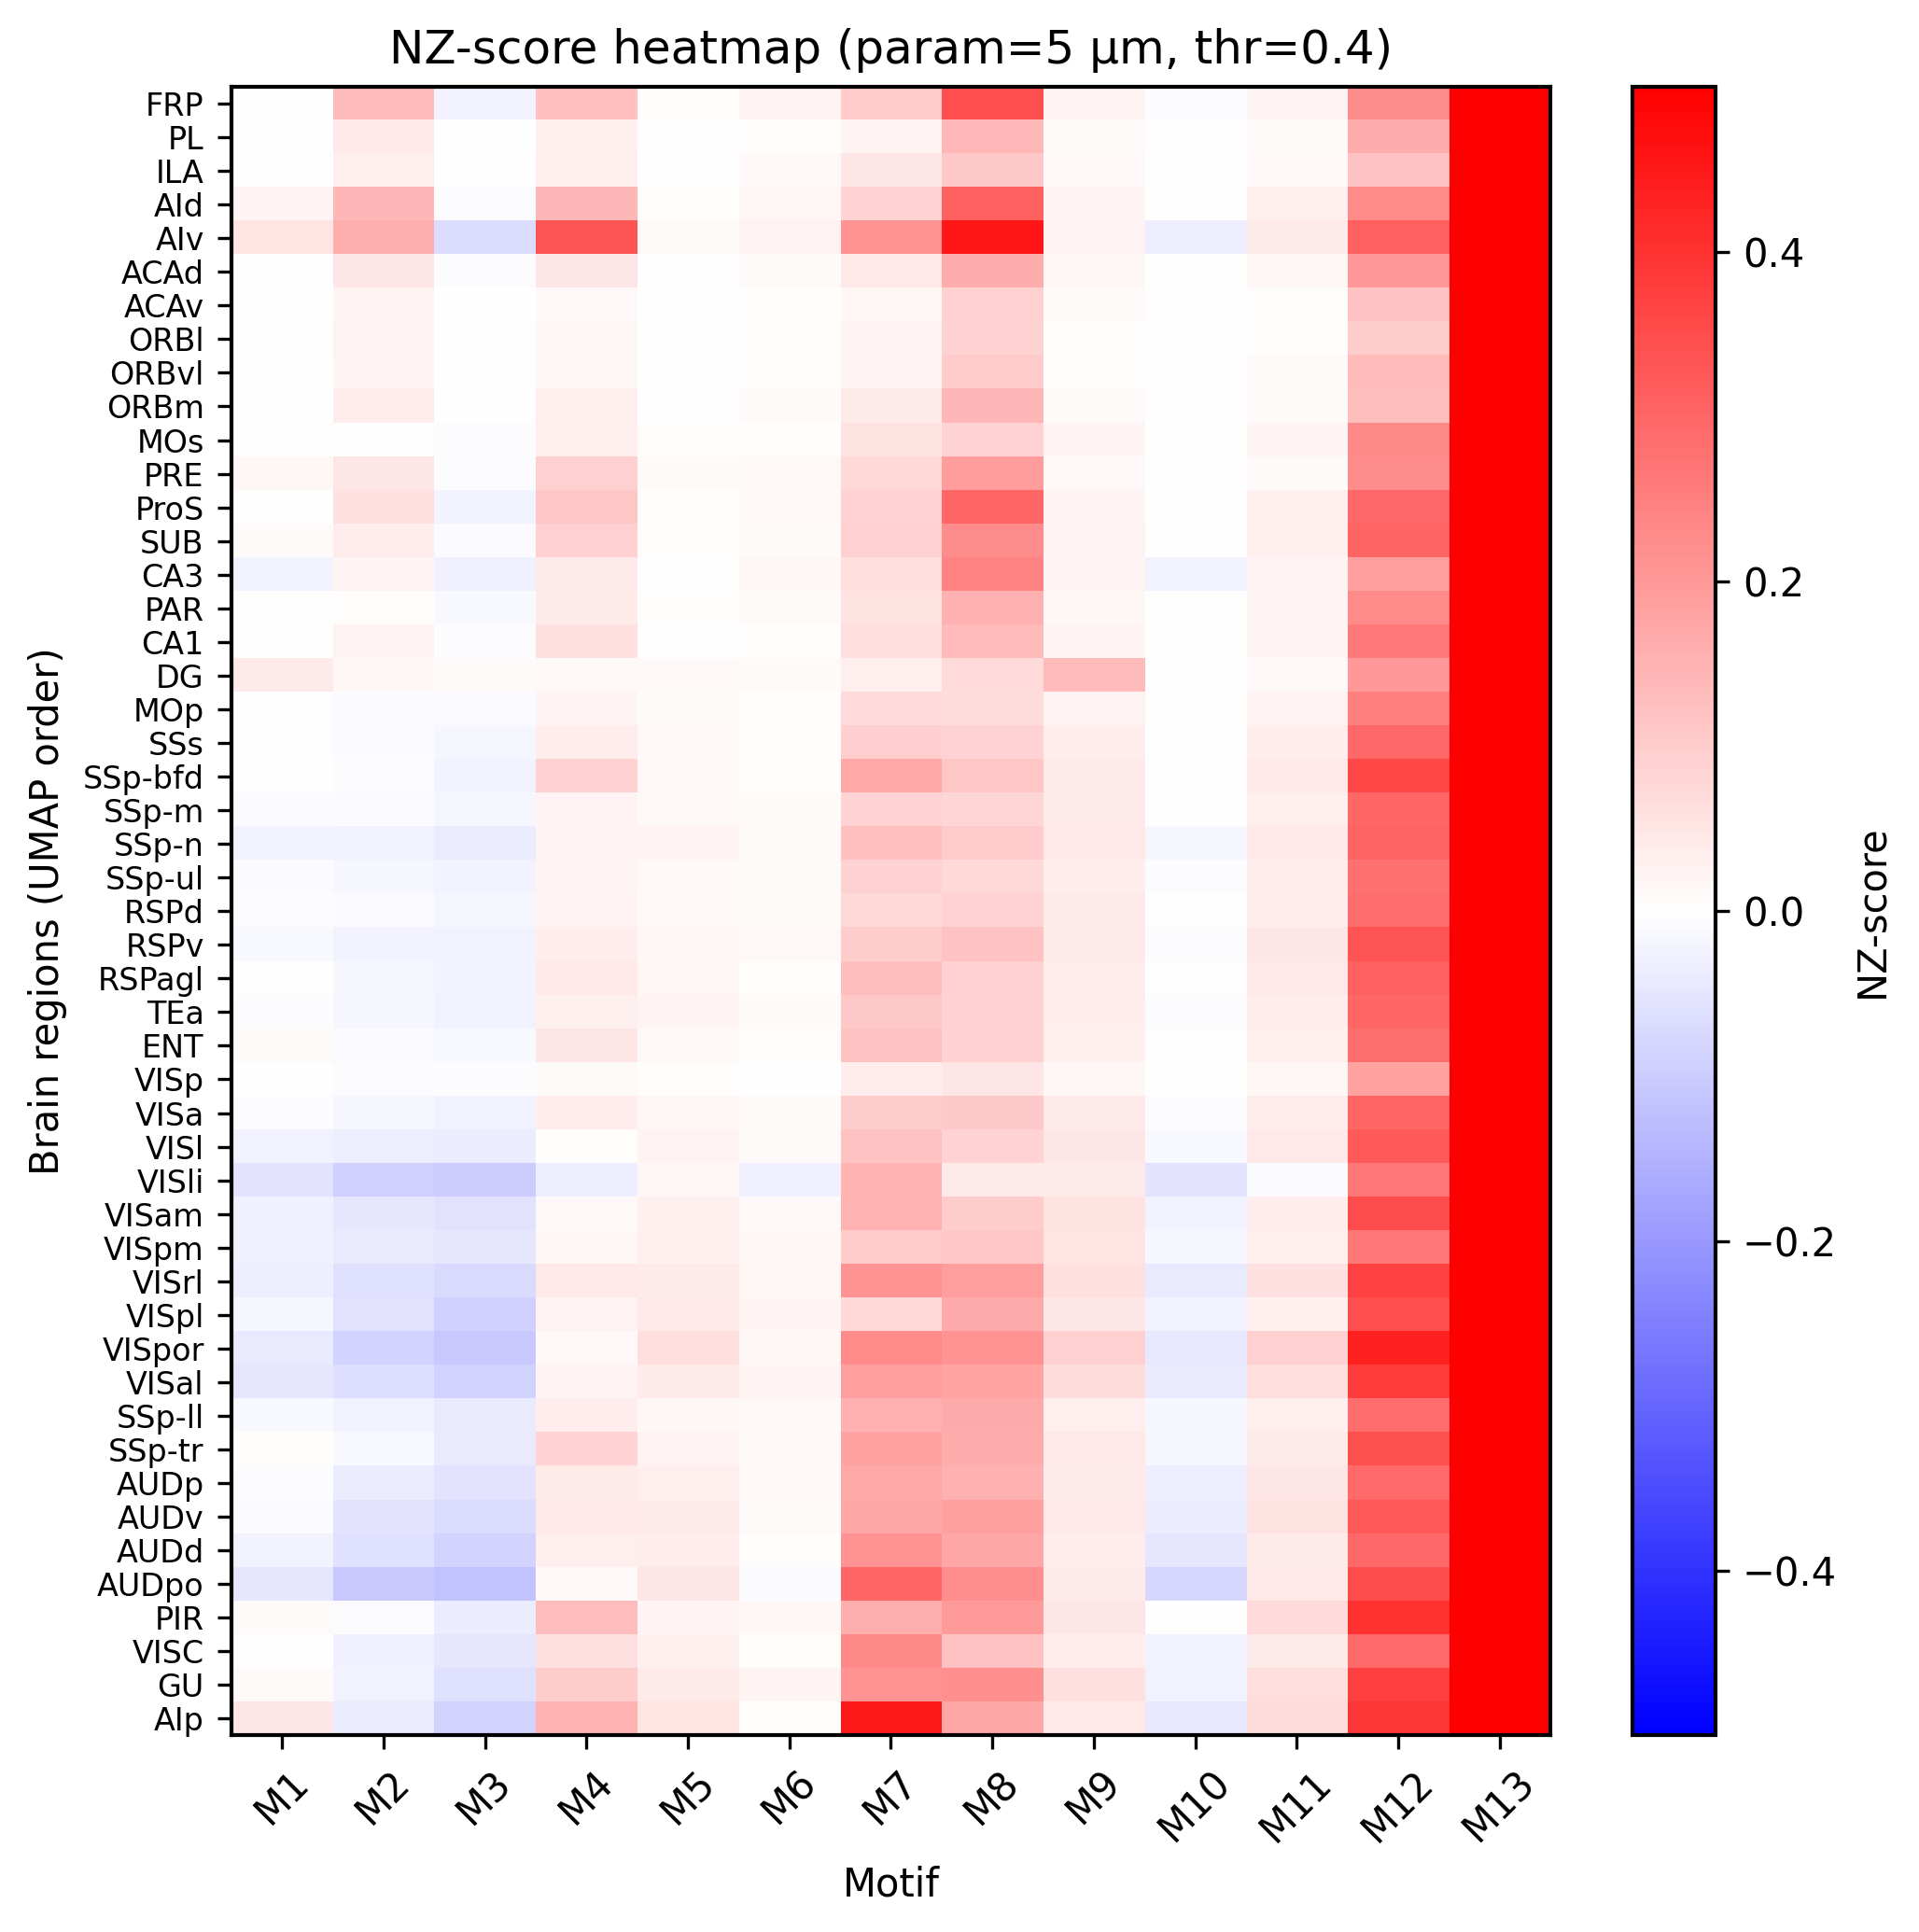

In [36]:
# ==================== 5. 固定 5 µm，遍历不同强度阈值画 NZ-score 热图 ====================

import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    results_all = pickle.load(f)["results"]   # dict[param] -> {region -> info}

param_fix = 5
thr_list  = ["0", "0.1", "0.2", "0.3", "0.4"]   # 你数据里那 5 个强度阈值

for thr_use in thr_list:
    NZ_rows = []
    region_rows = []

    for r in names:   # names 是前面按 UMAP+层次聚类排好序的脑区列表
        info = results_all[param_fix][r]
        mr   = info["motif_results"].get(thr_use)
        if mr is None:
            continue

        real  = np.asarray(mr["real_motif"], float)
        mu_mc = np.asarray(mr["er_mu_mc"], float)

        # 过滤条件：real_motif 所有元素 >=0.9，且 mu_mc 前 12 个都 >0
        if np.any(real < 0.9) or np.any(mu_mc[:12] <= 0.0):
            continue

        nz = np.asarray(mr["NZ"], float)   # 13 维 NZ-score
        NZ_rows.append(nz)
        region_rows.append(r)

    if not NZ_rows:
        print(f"[INFO] param={param_fix} µm, thr={thr_use} 下没有满足条件的脑区，跳过绘图")
        continue

    NZ_mat = np.vstack(NZ_rows)

    plt.figure(figsize=(7, 7))
    im = plt.imshow(NZ_mat, aspect="auto", cmap="bwr", vmin=-0.5, vmax=0.5)

    plt.colorbar(im, label="NZ-score")
    plt.yticks(range(len(region_rows)), region_rows, fontsize=8)
    plt.xticks(range(13), [f"M{i+1}" for i in range(13)], rotation=45)

    plt.title(f"NZ-score heatmap (param={param_fix} µm, thr={thr_use})"
)
    plt.xlabel("Motif")
    plt.ylabel("Brain regions (UMAP order)")

    plt.tight_layout()
    plt.savefig(f"9.wb_motif_NZ_strength_{thr_use}.svg",
                 bbox_inches="tight", transparent=True)
    plt.show()

有效脑区数（所有强度阈值都通过过滤）: 49


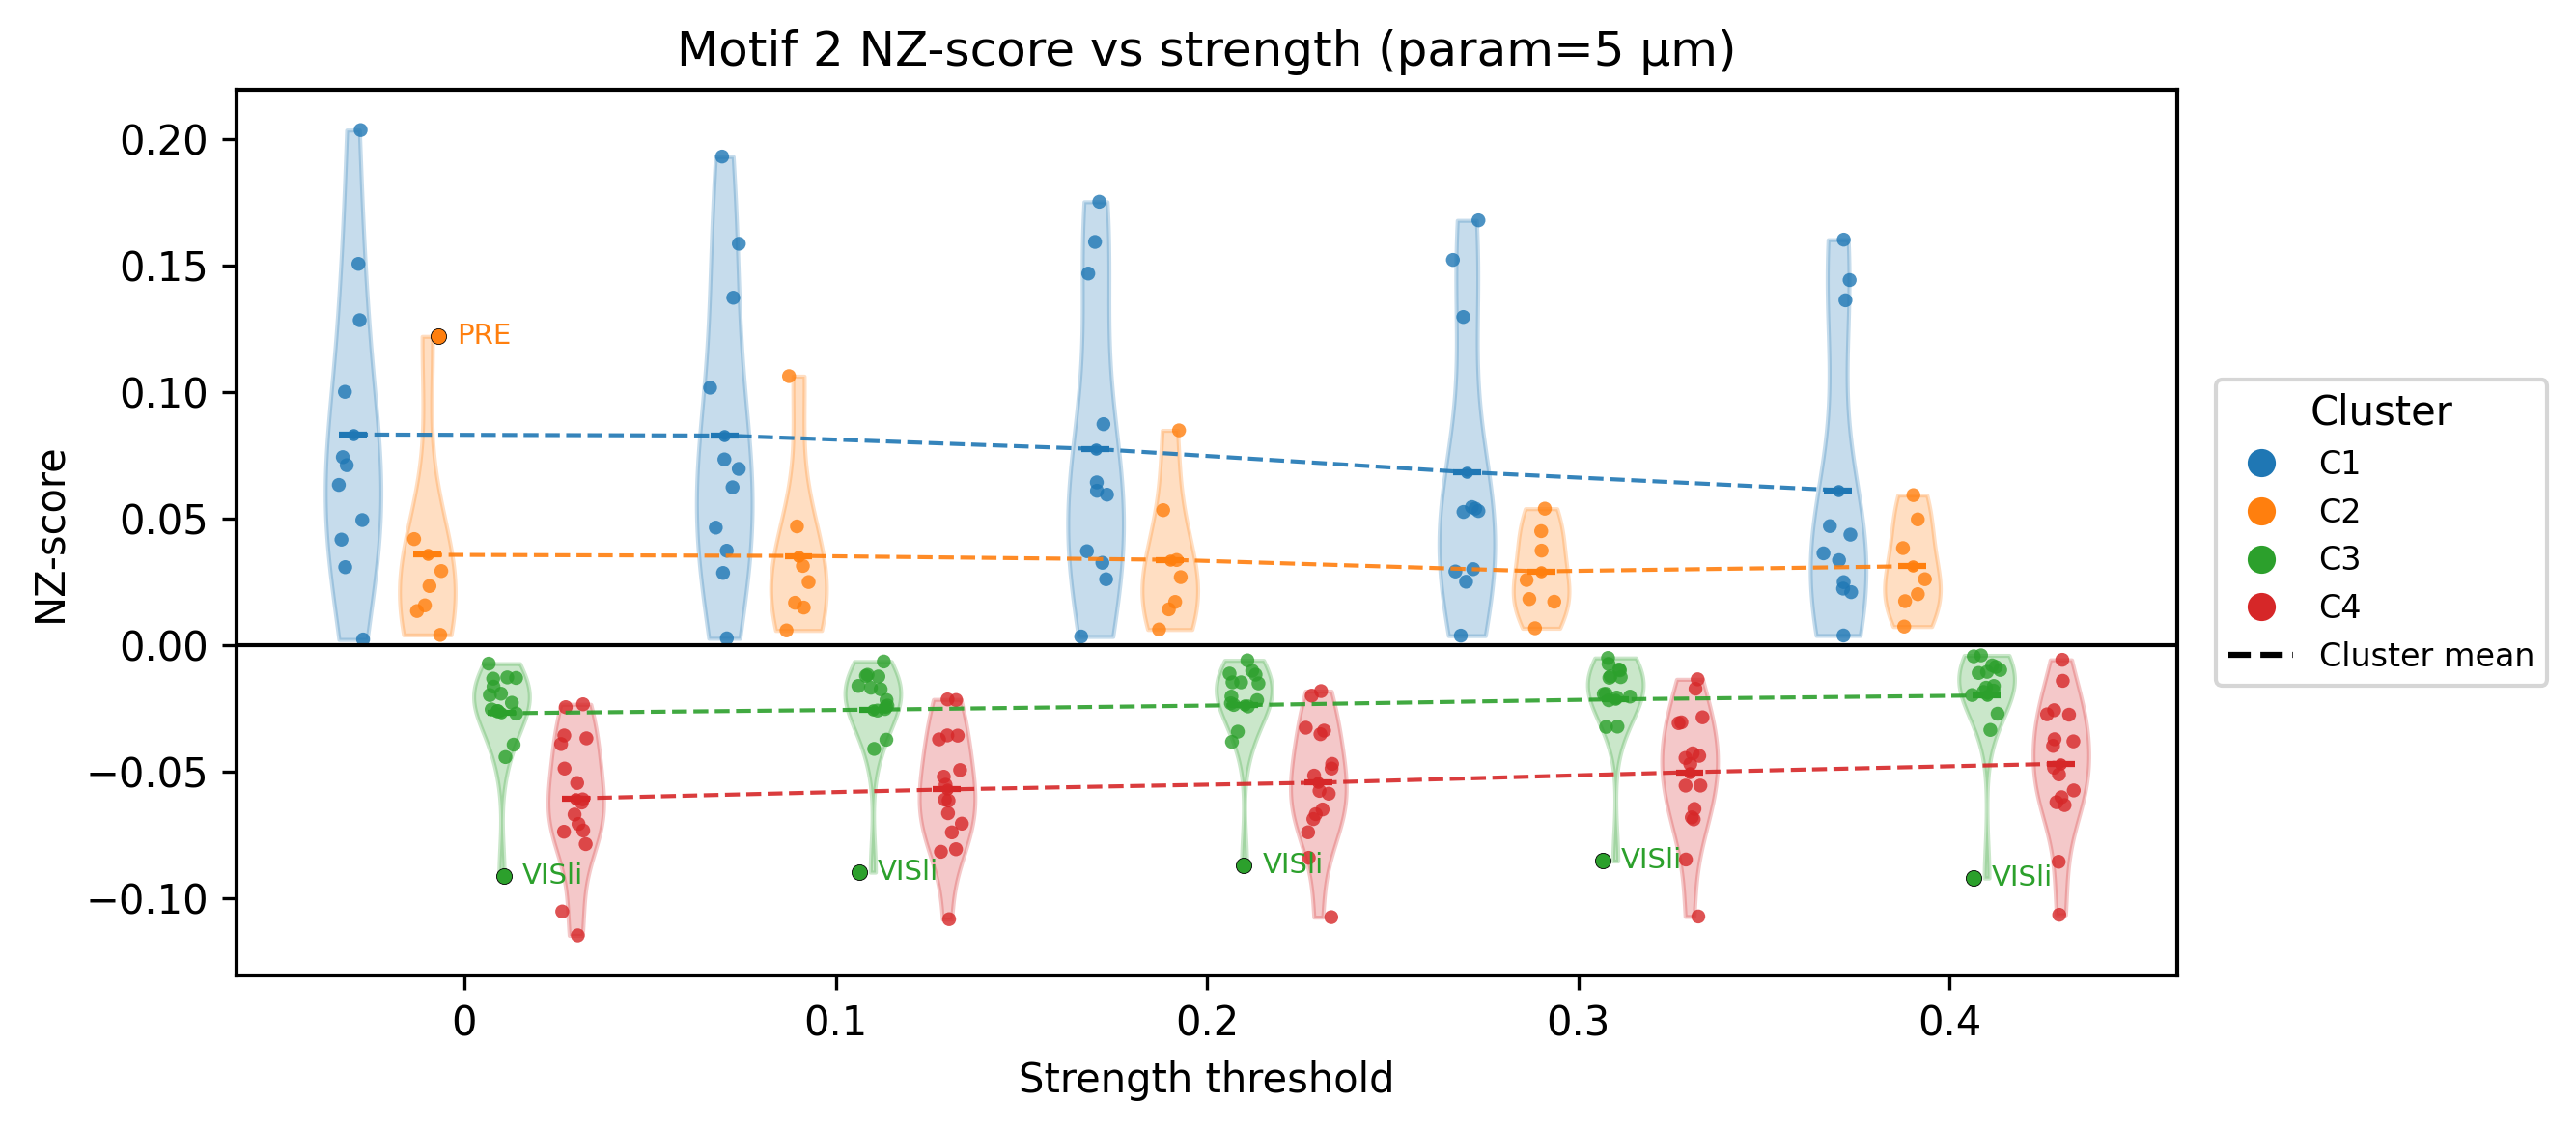

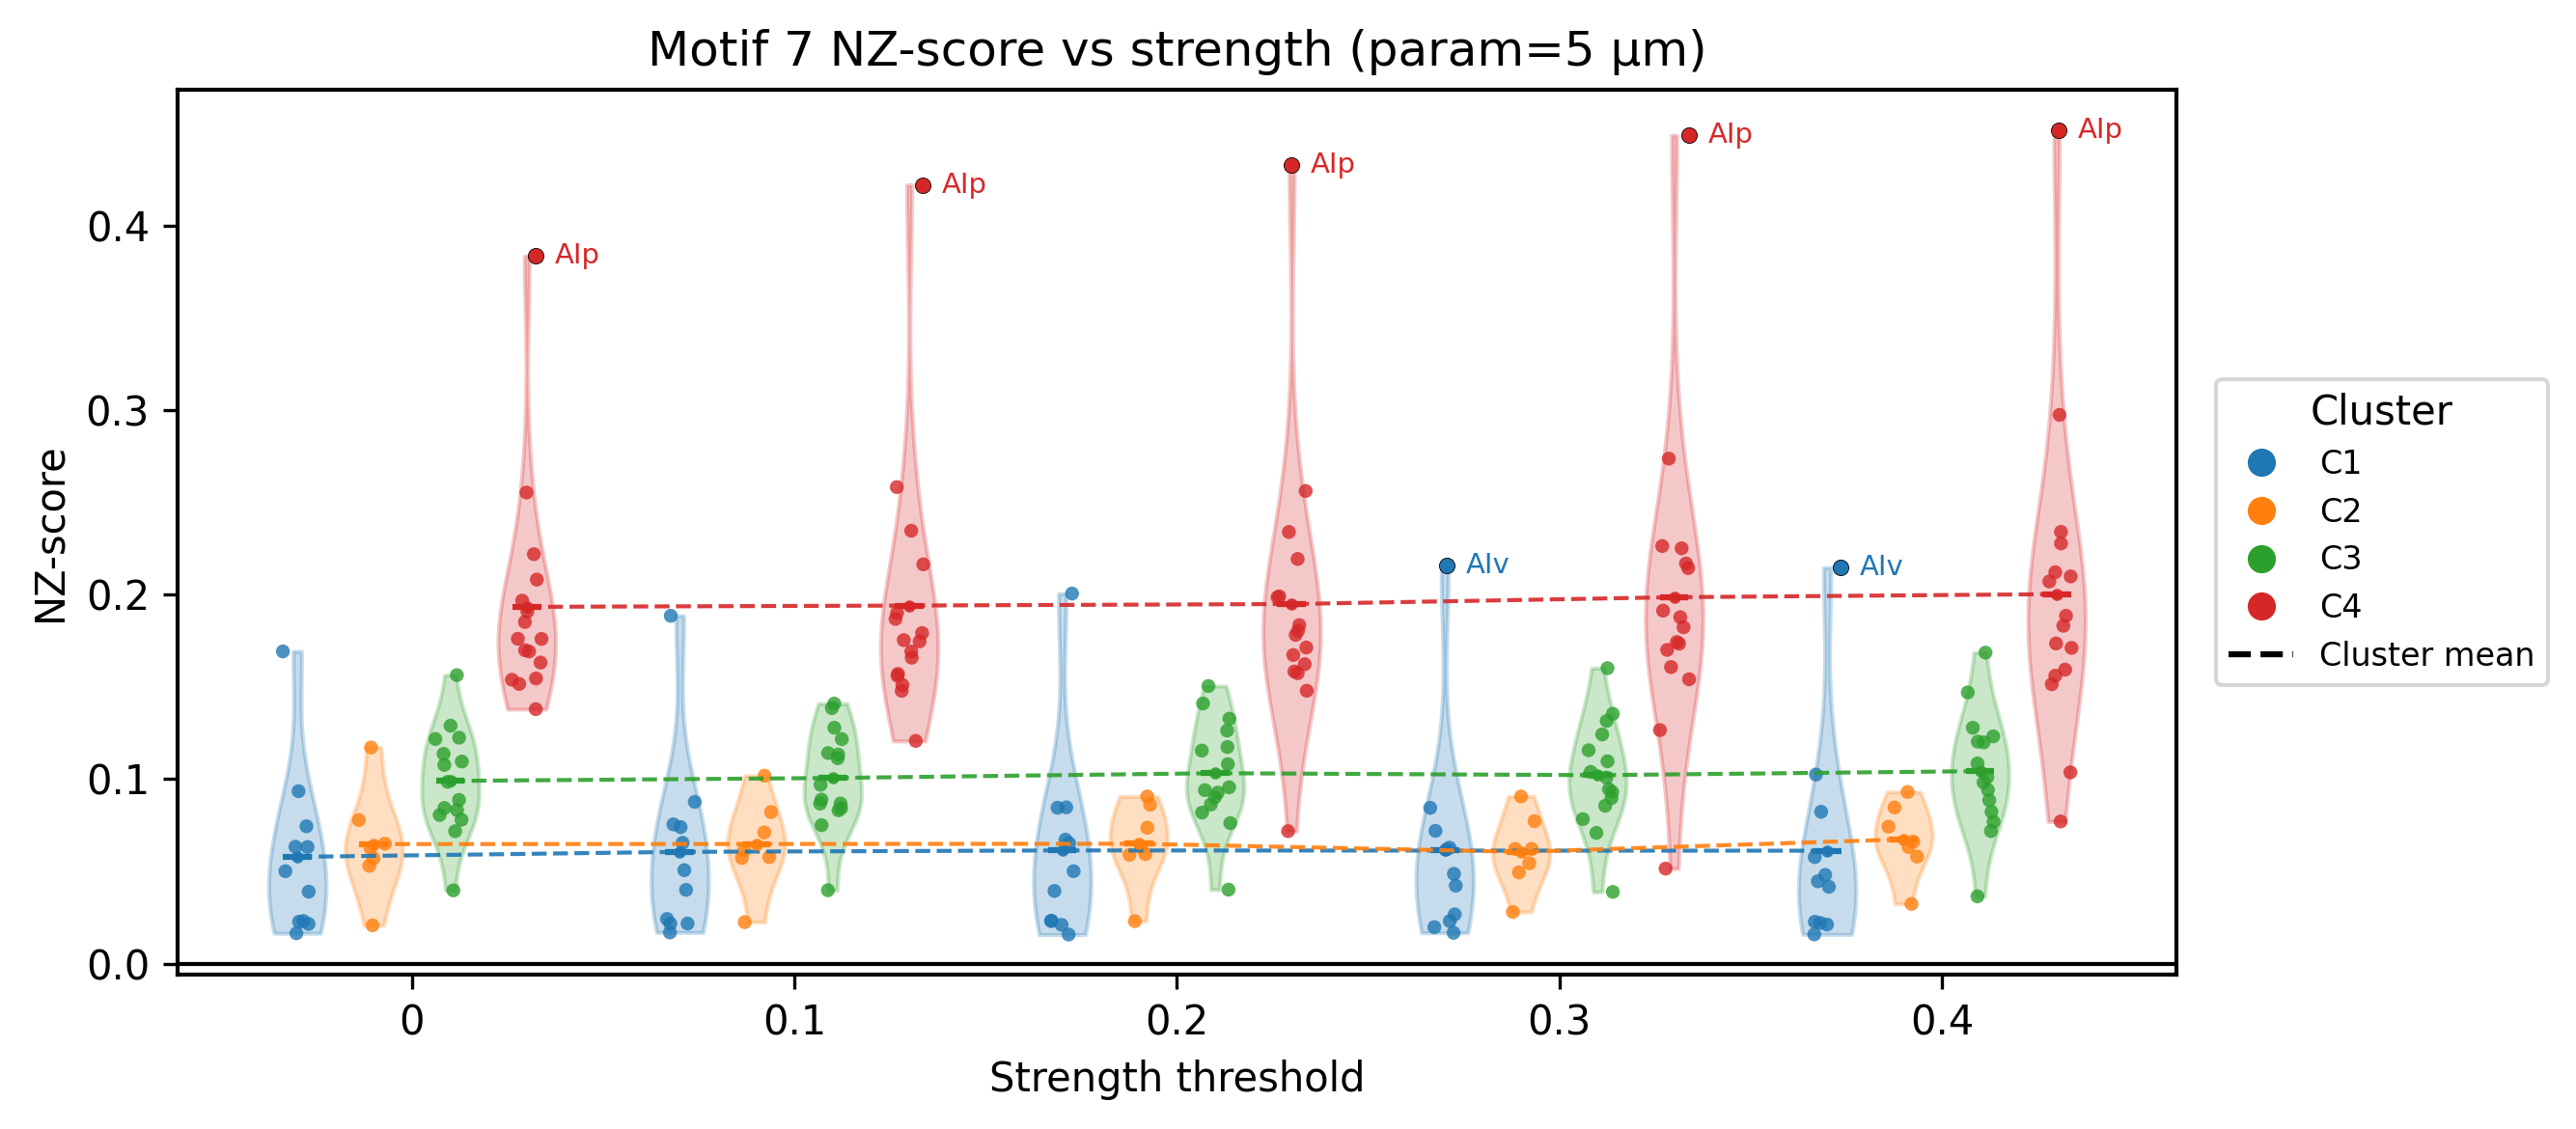

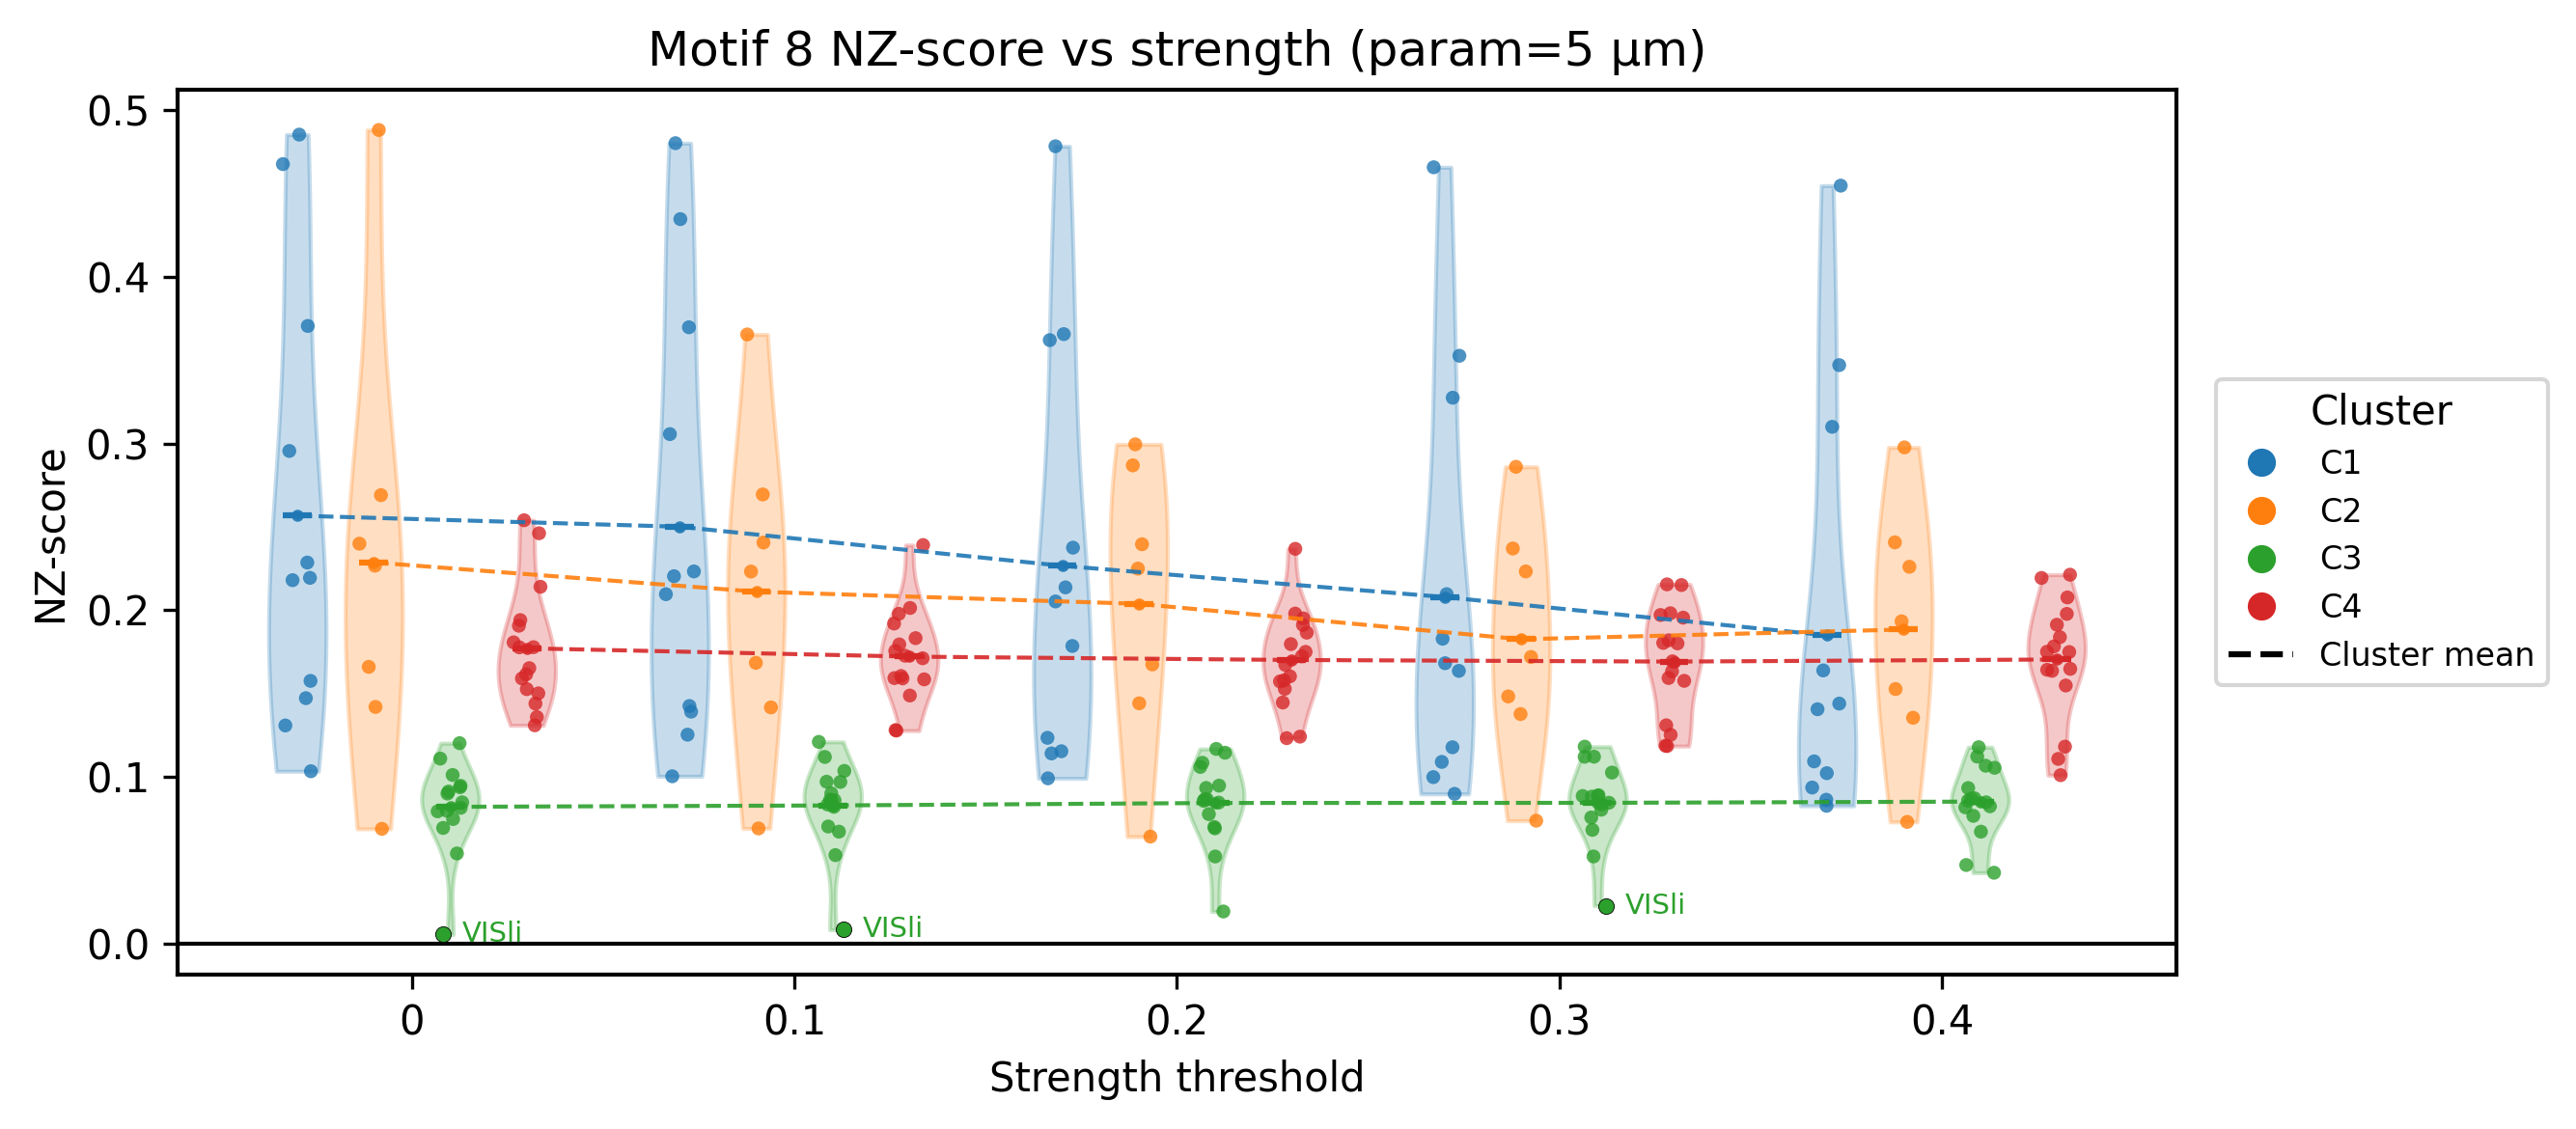

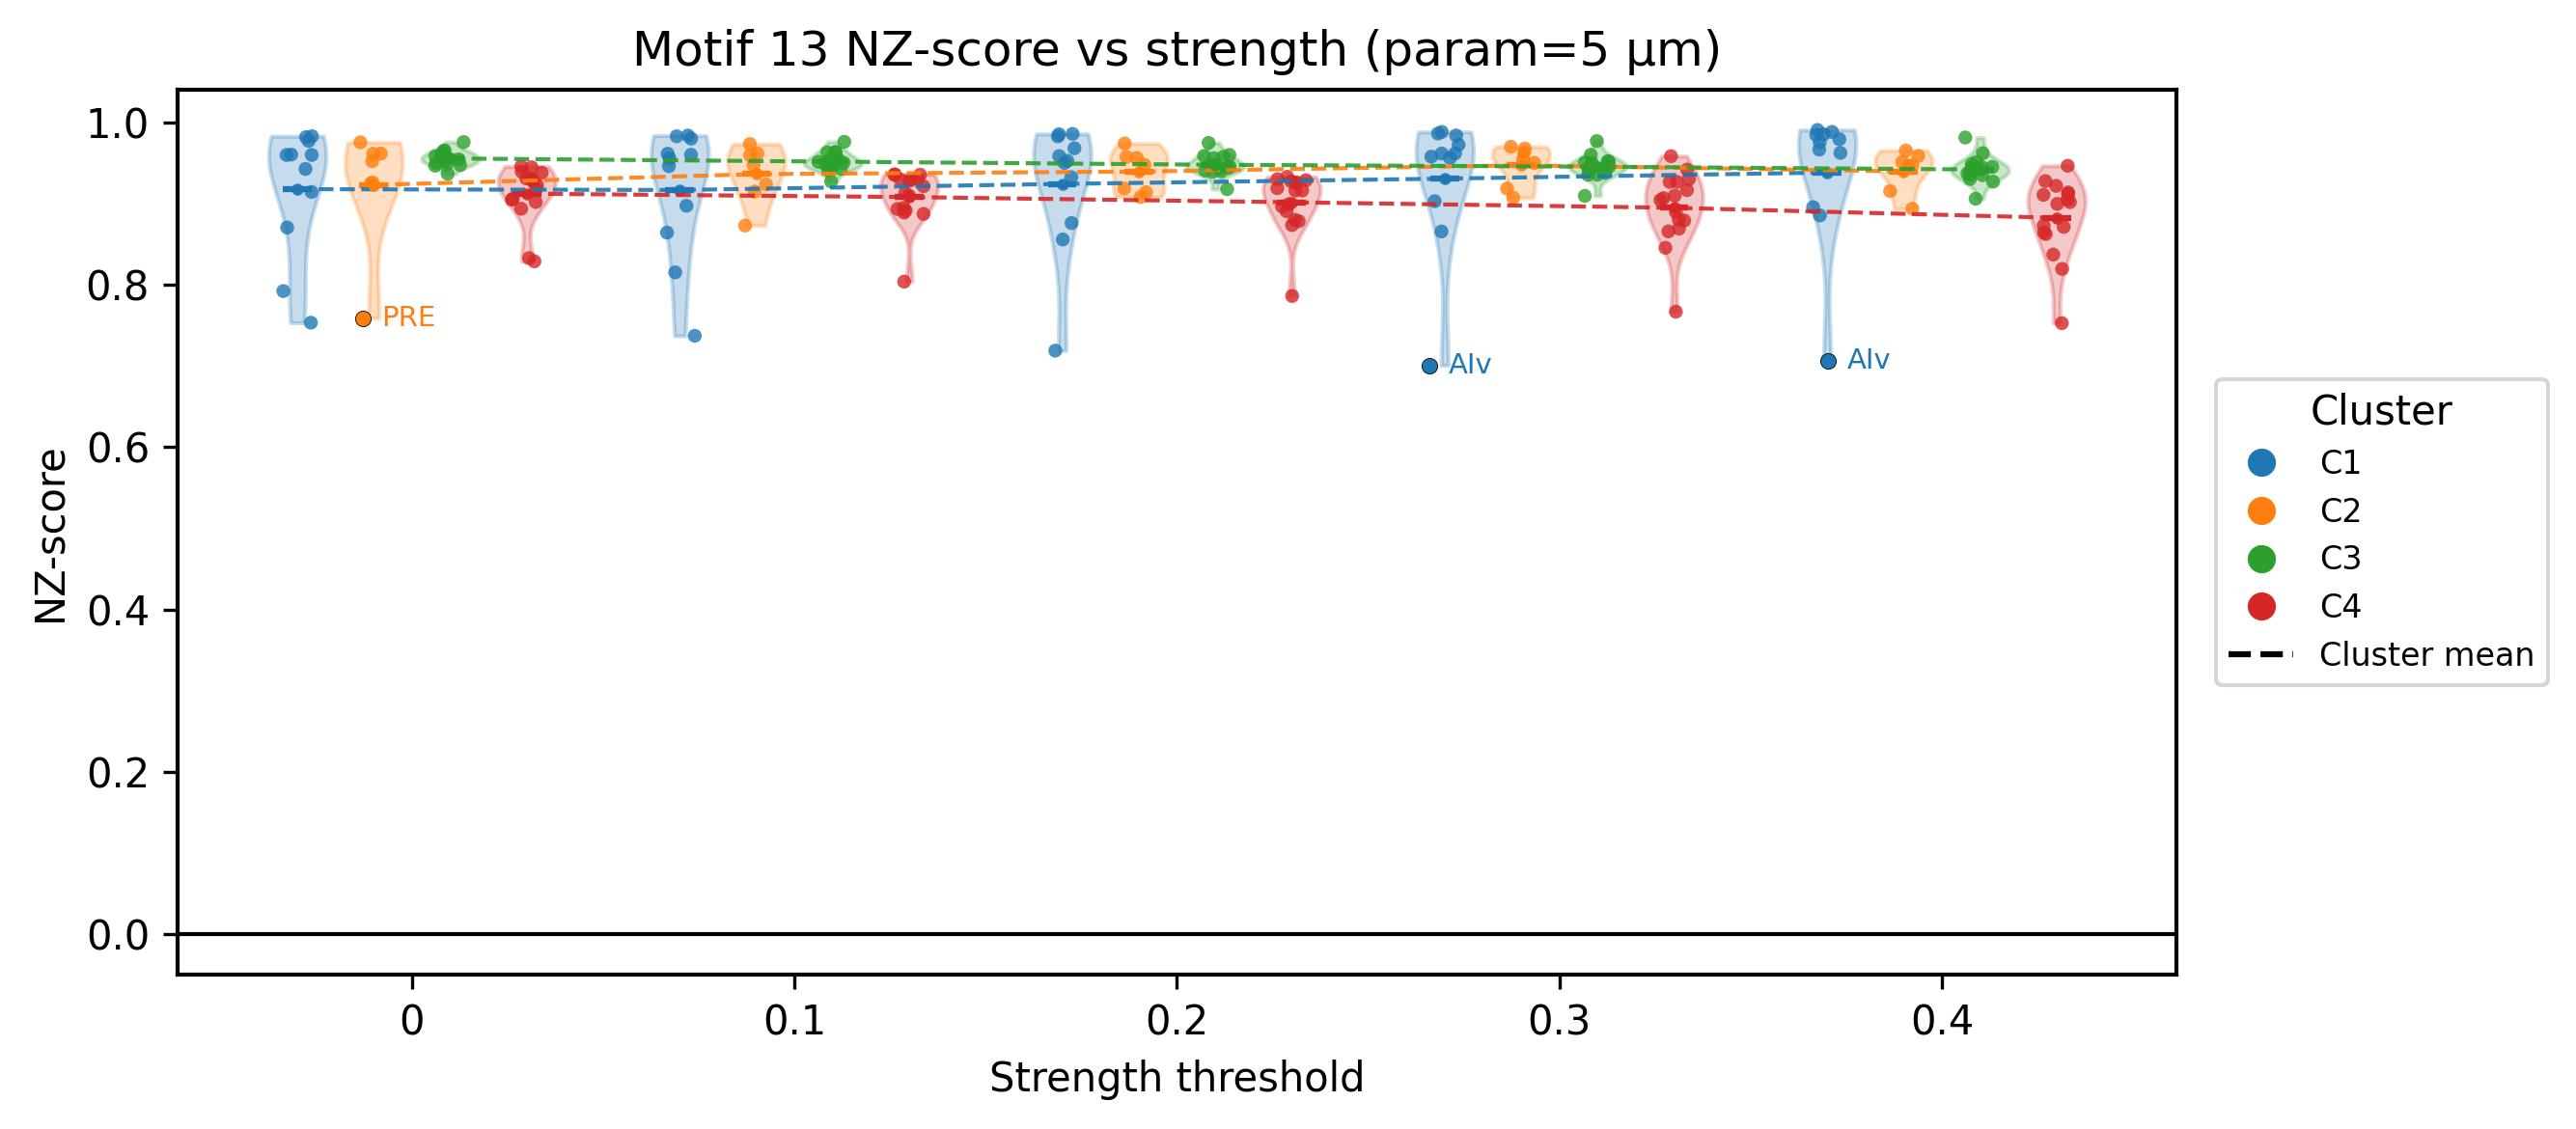

In [29]:
# ==================== motif 2/7/8/13：按聚类类别、随强度阈值变化的 NZ-score violin 图（全阈值一致过滤） ====================

import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    results_all = pickle.load(f)["results"]

param_use   = 5                                    # 固定距离阈值 5 µm
thr_list    = ["0", "0.1", "0.2", "0.3", "0.4"]    # 不同强度阈值（motif_results 的 key）
x_thr       = np.arange(len(thr_list))             # x 轴：0,1,2,3,4

motif_ids   = [2, 7, 8, 13]                        # 要看的 motif（1-based）
unique_cls  = np.unique(labels)                    # 来自之前 UMAP+聚类
n_clust     = len(unique_cls)
cluster_col = {c: plt.cm.tab10((c - 1) % 10) for c in unique_cls}

# ---------- 1) 先根据“所有强度阈值”一起过滤，选出 valid_idx ----------
valid_idx = []
for i, r in enumerate(names):
    ok = True
    for thr in thr_list:
        mr    = results_all[param_use][r]["motif_results"][thr]
        real  = np.asarray(mr["real_motif"], float)
        mu_mc = np.asarray(mr["er_mu_mc"], float)
        if np.any(real < 0.9) or np.any(mu_mc[:12] <= 0.0):
            ok = False
            break
    if ok:
        valid_idx.append(i)

print(f"有效脑区数（所有强度阈值都通过过滤）: {len(valid_idx)}")

# ---------- 2) 缓存各强度阈值下的 NZ（只对 valid_idx） ----------
NZ_by_thr = {thr: {} for thr in thr_list}
for i in valid_idx:
    r = names[i]
    for thr in thr_list:
        mr = results_all[param_use][r]["motif_results"][thr]
        NZ_by_thr[thr][i] = np.asarray(mr["NZ"], float)   # 13 维

# ---------- 3) 对每个 motif 画一张 violin + outlier + 均值虚线 ----------
for m_id in motif_ids:
    j = m_id - 1   # 0-based index

    fig, ax = plt.subplots(figsize=(9, 4))
    width   = 0.20   # 不同 cluster 在同一强度上的横向偏移

    # 记录 cluster 在不同强度阈值下的均值
    mean_x = {c: [] for c in unique_cls}
    mean_y = {c: [] for c in unique_cls}

    for ci, c in enumerate(unique_cls):
        offset         = (ci - (n_clust - 1) / 2.) * width
        data_list      = []   # 当前 cluster 在不同强度阈值下的一组组值
        pos_list       = []   # 每组的 x 位置
        names_by_group = []   # 每组对应的脑区名

        for ti, thr in enumerate(thr_list):
            # 限制在 valid_idx 之内 & 当前 cluster
            idx_i = [
                i for i in valid_idx
                if labels[i] == c and i in NZ_by_thr[thr]
            ]
            if not idx_i:
                continue

            vals = np.array([NZ_by_thr[thr][i][j] for i in idx_i])
            regs = [names[i] for i in idx_i]
            x_center = x_thr[ti] + offset

            data_list.append(vals)
            pos_list.append(x_center)
            names_by_group.append(regs)

            mean_x[c].append(x_center)
            mean_y[c].append(vals.mean())

        if not data_list:
            continue

        # violin：同一 cluster、不同强度阈值的分布
        parts = ax.violinplot(
            data_list,
            positions=pos_list,
            widths=0.15,
            showmeans=True,
            showextrema=False,
            showmedians=False,
        )
        for body in parts["bodies"]:
            body.set_facecolor(cluster_col[c])
            body.set_edgecolor(cluster_col[c])
            body.set_alpha(0.25)

        # 点 + outlier 高亮
        for x0, vals, regs in zip(pos_list, data_list, names_by_group):
            q1, q3 = np.percentile(vals, [25, 75])
            iqr    = q3 - q1
            lower  = q1 - 3 * iqr
            upper  = q3 + 3 * iqr
            is_out = (vals < lower) | (vals > upper)

            jitter = (np.random.rand(len(vals)) - 0.5) * 0.08
            x_base = np.full(len(vals), x0) + jitter

            # 普通点
            ax.scatter(
                x_base[~is_out], vals[~is_out],
                s=12, alpha=0.8,
                color=cluster_col[c], edgecolors="none",
            )

            # outlier 点 + 标名字
            ax.scatter(
                x_base[is_out], vals[is_out],
                s=15, alpha=1.0,
                facecolors=cluster_col[c],
                edgecolors="black",
                linewidths=0.2,
                zorder=5,
            )
            for xo, yo, name_out in zip(x_base[is_out], vals[is_out], np.array(regs)[is_out]):
                ax.text(
                    xo + 0.05, yo, name_out,
                    fontsize=7,
                    va="center", ha="left",
                    color=cluster_col[c],
                )

    # 画 cluster 均值虚线（x 用 x_center，自动对齐 violin）
    for c in unique_cls:
        xs = np.array(mean_x[c]); ys = np.array(mean_y[c])
        if len(xs) == 0:
            continue
        order = np.argsort(xs)
        ax.plot(
            xs[order], ys[order],
            color=cluster_col[c],
            linewidth=1,
            alpha=0.9,
            linestyle="--",
            marker="o",
            markersize=2,
        )

    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("Strength threshold")
    ax.set_ylabel("NZ-score")
    ax.set_title(f"Motif {m_id} NZ-score vs strength (param={param_use} µm)")

    ax.set_xticks(x_thr)
    ax.set_xticklabels(thr_list)

    # 颜色 = cluster；虚线 = cluster mean
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="",
                   color=cluster_col[c], label=f"C{int(c)}")
        for c in unique_cls
    ] + [
        plt.Line2D([0], [0], color="k", linestyle="--", label="Cluster mean")
    ]
    ax.legend(
        handles=handles,
        title="Cluster",
        fontsize=8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    plt.tight_layout()
    plt.savefig(f"9.motif{m_id}_NZ_vs_strength.svg",
                 bbox_inches="tight", transparent=True)
    plt.show()

In [15]:
import pickle
import numpy as np

pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"

with open(pkl_path, "rb") as f:
    results_all = pickle.load(f)["results"]

res_5 = results_all[5]   # 5 µm

all_w = []

for region, info in res_5.items():
    # 假设 info["sc"] 就是加权连接矩阵；如果是 dict，就改成相应的 key
    W = np.asarray(info["sc"], float)

    # 去掉对角线 & 只保留 >0 的连接
    mask = ~np.eye(W.shape[0], dtype=bool)
    vals = W[mask]
    vals = vals[vals > 0]

    if vals.size:
        all_w.append(vals)

all_w = np.concatenate(all_w)

# 选择截断分位数：比如 99 分位数
q = 95
cut = np.percentile(all_w, q)

w_plot = all_w[all_w <= cut]

print(f"总连接数: {all_w.size}")
print(f"{q}th 分位数截断值: {cut:.4g}")
print(f"截断后剩余: {w_plot.size}")

总连接数: 1443616
95th 分位数截断值: 28.01
截断后剩余: 1371435


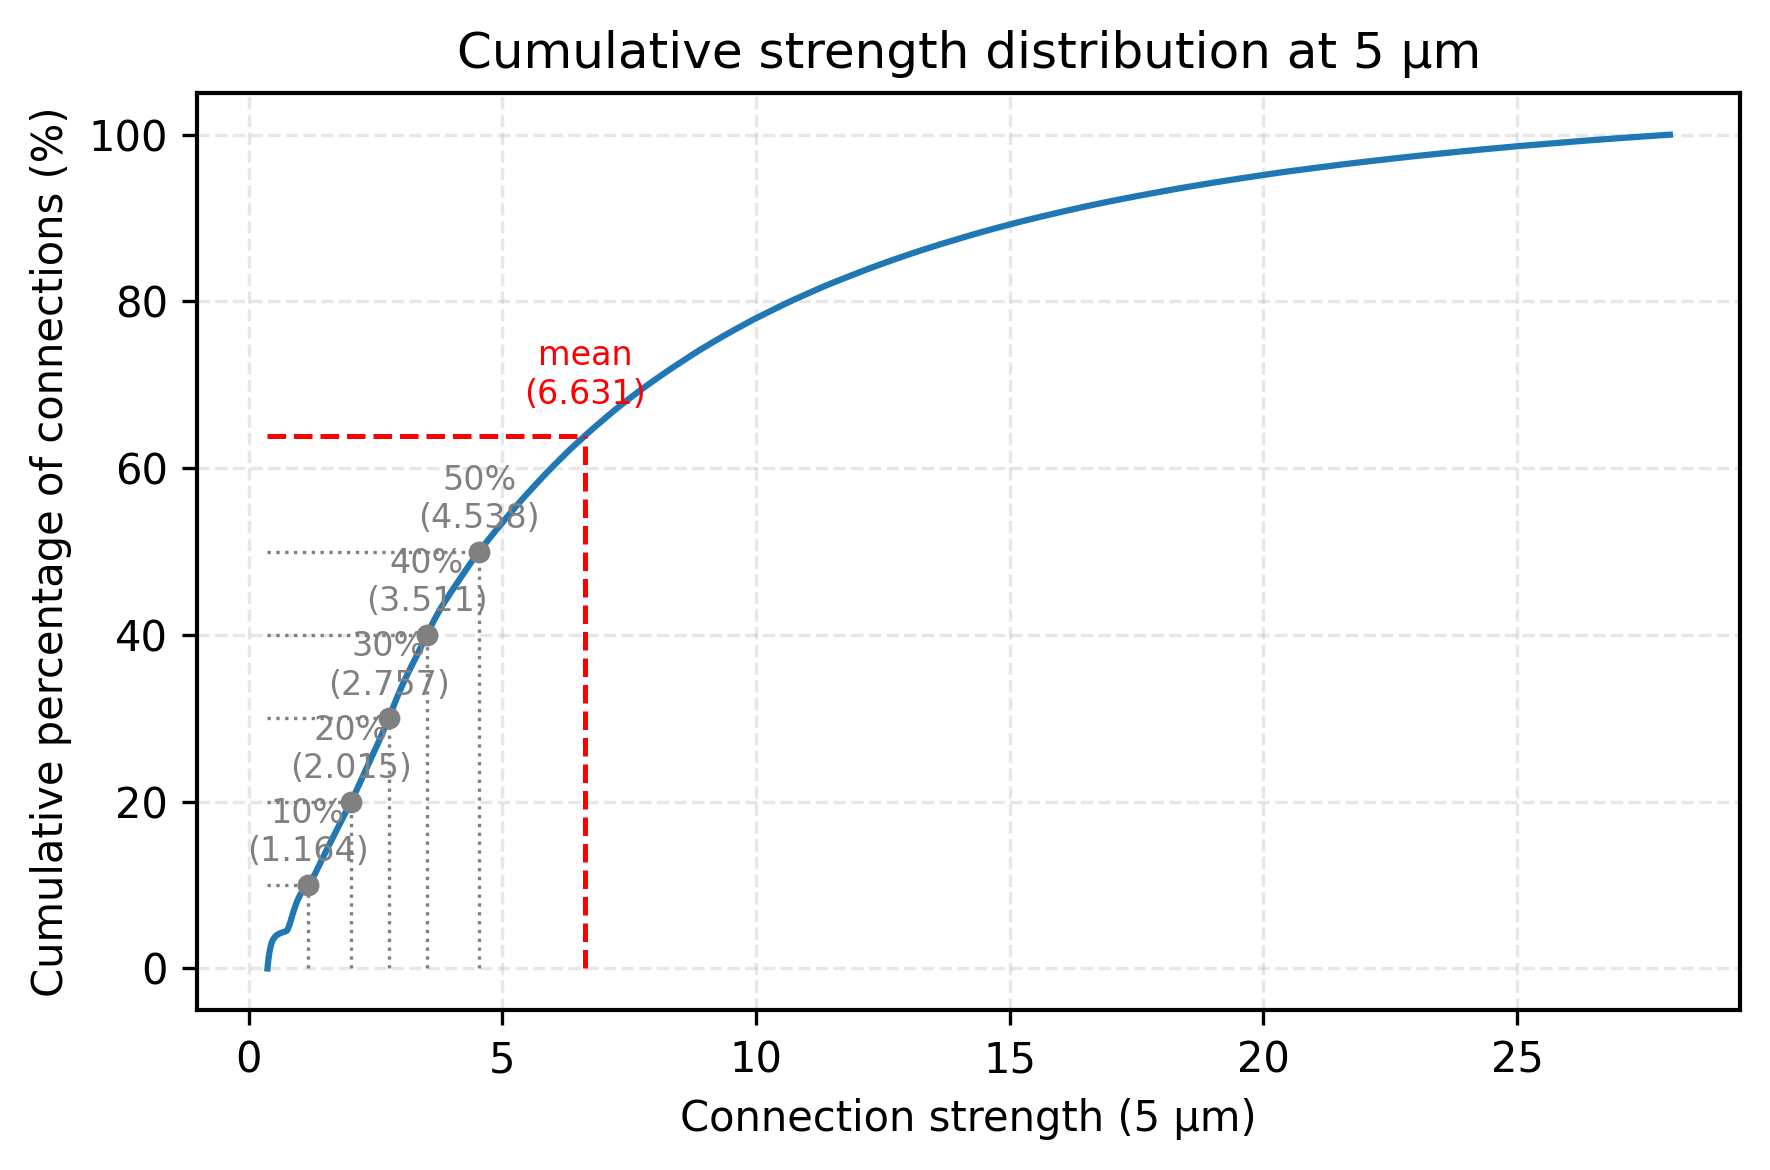

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# w_plot：已经长尾截断好的边强度

# === 用排序后的数据画经验 CDF（更平滑）===
w_sorted = np.sort(w_plot)
n = len(w_sorted)
cum_pct = np.arange(1, n + 1) / n * 100  # 1 ~ 100%

plt.figure(figsize=(6, 4))
plt.plot(w_sorted, cum_pct, linewidth=1.5)
plt.xlabel("Connection strength (5 µm)")
plt.ylabel("Cumulative percentage of connections (%)")
plt.title("Cumulative strength distribution at 5 µm")
plt.grid(True, linestyle="--", alpha=0.3)

x_min = w_sorted[0]

# ---- 用精确分位数来标点：x=分位数强度, y=对应百分位 ----
q_levels = np.array([10, 20, 30, 40, 50])          # 百分位
q_vals   = np.quantile(w_plot, q_levels / 100.0)   # 对应的强度

for q_perc, qx in zip(q_levels, q_vals):
    cy = q_perc

    # 竖线
    plt.plot([qx, qx], [0, cy],
             color="gray", linestyle=":", linewidth=0.8)
    # 横线
    plt.plot([x_min, qx], [cy, cy],
             color="gray", linestyle=":", linewidth=0.8)

    plt.scatter([qx], [cy], color="gray", s=18, zorder=5)
    # ✅ 标注百分位 + 对应的强度数值
    plt.text(
        qx, cy + 2,
        f"{q_perc}%\n({qx:.3f})",   # 比如：10%\n(0.023)
        ha="center", va="bottom",
        fontsize=8, color="gray",
    )

# ---- 均值的位置：x=mean, y=均值在经验分布中的百分位 ----
mu = w_plot.mean()
rank = np.searchsorted(w_sorted, mu, side="right")
cy_mean = rank / n * 100.0

plt.plot([mu, mu], [0, cy_mean],
         color="red", linestyle="--", linewidth=1.2)
plt.plot([x_min, mu], [cy_mean, cy_mean],
         color="red", linestyle="--", linewidth=1.2)

# ✅ 均值也标注具体数值
plt.text(
    mu, cy_mean + 3,
    f"mean\n({mu:.3f})",
    ha="center", va="bottom",
    fontsize=8, color="red",
)

plt.tight_layout()
plt.savefig(f"8.wb_strength_cum_5um.svg",
                 bbox_inches="tight", transparent=True)
plt.show()

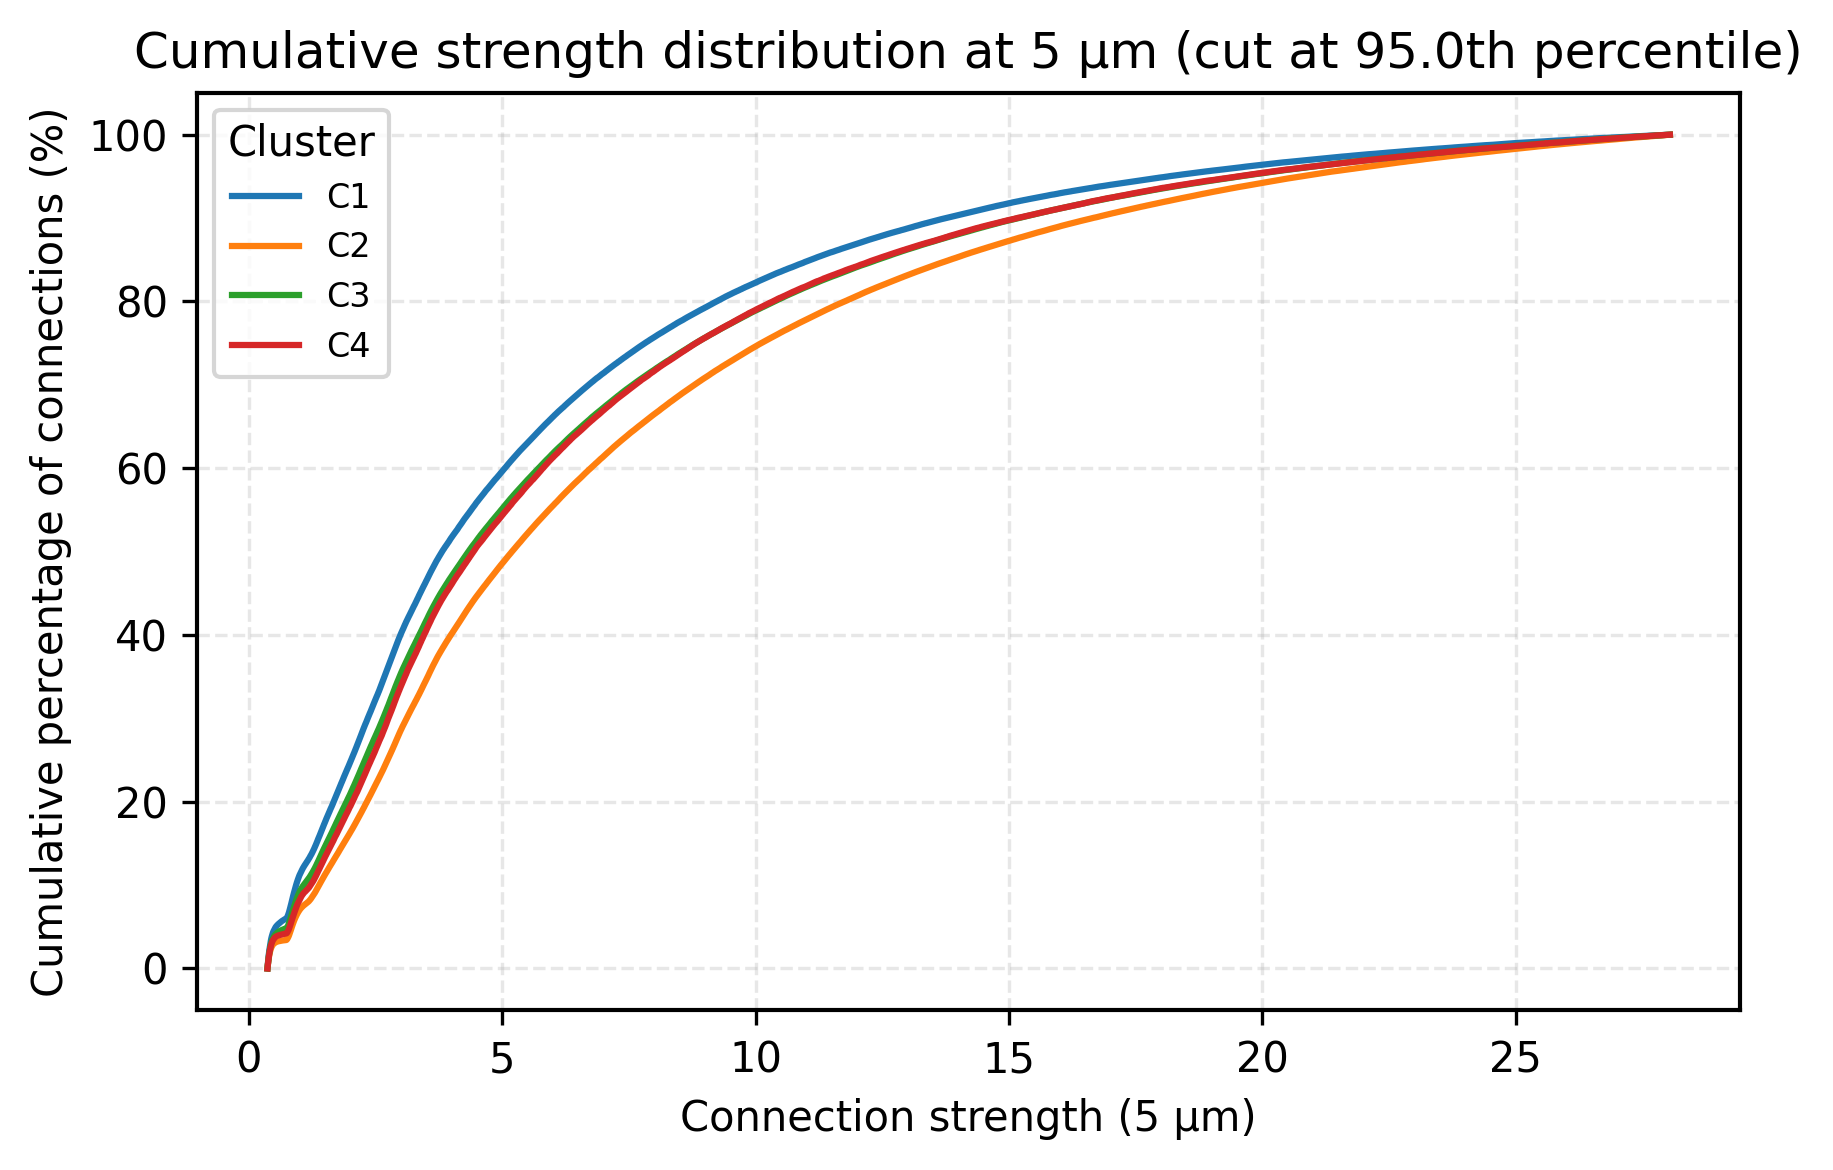

In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. 读数据 & 基本信息 =====
with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    results_all = pickle.load(f)["results"]

param_use  = 5          # 5 µm
unique_cls = np.unique(labels)      # 之前 UMAP + 聚类得到的 labels / names
cluster_col = {c: plt.cm.tab10((c - 1) % 10) for c in unique_cls}

# ===== 2. 按 cluster 收集 5µm 的所有非零权重 =====
weights_by_cluster = {c: [] for c in unique_cls}

for r, c in zip(names, labels):
    sc = np.asarray(results_all[param_use][r]["sc"], float)  # 5 µm 下的连接矩阵
    w  = sc.ravel()
    w  = w[w > 0]   # 只保留非零边
    if w.size:
        weights_by_cluster[c].append(w)

for c in unique_cls:
    if weights_by_cluster[c]:
        weights_by_cluster[c] = np.concatenate(weights_by_cluster[c])
    else:
        weights_by_cluster[c] = np.array([])

# ===== 3. 全局长尾截断（统一一个上限，方便比较）=====
q_tail = 0.95
all_w  = np.concatenate([w for w in weights_by_cluster.values() if w.size])
cut    = np.quantile(all_w, q_tail)

for c in unique_cls:
    w = weights_by_cluster[c]
    weights_by_cluster[c] = w[(w > 0) & (w <= cut)]

# ===== 4. 在同一张图里画 4 条 ECDF 曲线 =====
plt.figure(figsize=(6, 4))

for c in unique_cls:
    w = weights_by_cluster[c]
    if w.size == 0:
        continue

    w_sorted = np.sort(w)
    n        = len(w_sorted)
    cum_pct  = np.arange(1, n + 1) / n * 100  # 0–100%

    plt.plot(
        w_sorted, cum_pct,
        color=cluster_col[c],
        linewidth=1.5,
        label=f"C{int(c)}"
    )

plt.xlabel("Connection strength (5 µm)")
plt.ylabel("Cumulative percentage of connections (%)")
plt.title(f"Cumulative strength distribution at 5 µm (cut at {q_tail*100:.1f}th percentile)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Cluster", fontsize=8)
plt.tight_layout()
plt.savefig(f"8.cluster_strength_cum_5um.svg",
                 bbox_inches="tight", transparent=True)
plt.show()